<a href="https://colab.research.google.com/github/moja7/Dissertation/blob/main/Diss_Analy_18_7_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fully detach and clean the mountpoint
from google.colab import drive
try:
    drive.flush_and_unmount()
except Exception as e:
    print("unmount note:", e)

# Remove any leftover mount directory that's blocking the remount
import shutil, os
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive", ignore_errors=True)
print("mountpoint cleared:", not os.path.exists("/content/drive"))

mountpoint cleared: True


In [ ]:
from google.colab import drive
drive.mount("/content/drive")   # choose the CORRECT account in the popup

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/"))          # expect ['MyDrive'] or ['MyDrive','Shareddrives']
hits = []
for root, _, files in os.walk("/content/drive/MyDrive/Dissertation Analysis"):
    hits += [os.path.join(root, f) for f in files]
print(f"{len(hits)} files found under project folder")
for h in hits[:10]: print(" ", h)

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']
144 files found under project folder
  /content/drive/MyDrive/Dissertation Analysis/Data/Nat Gas Pricing - EU full.xls
  /content/drive/MyDrive/Dissertation Analysis/Data/CEGH Hist Data.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c1-btu-dollar-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c1-btu-dollar-weekly-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/SNL HH Day Ahead Daily.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c3-btu-dollar-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c4-btu-dollar-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c5-btu-dollar-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c6-btu-dollar-1990.xlsx
  /content/drive/MyDrive/Dissertation Analysis/Data/HH-c7-btu-dollar-1990.xlsx


In [ ]:
# %% Cell A1: Install + imports + paths
!pip install -q arch ruptures shap xgboost statsmodels scikit-learn \
    torch pytorch-forecasting lightning

import os, glob, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_style("whitegrid"); plt.rcParams["figure.figsize"] = (14, 5)

# --- Confirmed directory layout ---
BASE     = "/content/drive/MyDrive/Dissertation Analysis"
DATA_DIR = f"{BASE}/data"
OUT_DIR  = f"{BASE}/output"
os.makedirs(OUT_DIR, exist_ok=True)

# Verify the folders and the parquet are actually visible this session
print("BASE exists :", os.path.exists(BASE))
print("DATA exists :", os.path.exists(DATA_DIR))
print("OUT  exists :", os.path.exists(OUT_DIR))
print("\nFiles in output/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f)

BASE exists : True
DATA exists : False
OUT  exists : True

Files in output/:
   adf_test_results.csv
   check1_raw_series.png
   check2_coverage.png
   check3_units.png
   check4_features.png
   chokepoints.png
   cointegration_results.csv
   correlation_heatmap.png
   crisis_comparison.csv
   diag_stationarity.csv
   eda_acf.png
   eda_stl.png
   event_study_car.png
   fig1_1_lng_trade.png
   fig1_2_chokepoints.png
   fig5_1_model_comparison.png
   fig5_4_breaks.png
   fig5_5_connectedness.png
   fig5_7_taxonomy.png
   fig_chow_ED.png
   fig_connectedness_ED.png
   fig_model_comparison_ED.png
   fig_model_comparison_styled.png
   fig_regime_styled.png
   fig_seq_training.png
   figures
   hyperparam_curves.png
   hyperparameter_table.csv
   markov_regime.png
   master_panel.csv
   master_panel.parquet
   prices_events.png
   regime_optA_grouped.png
   regime_optB_grouped.png
   regime_optC_lollipop.png
   regime_optD_heatmap.png
   rolling_connectedness.png
   seq_training_curves.png


In [ ]:
# %% Cell A2: Load the master panel
panel_path = f"{OUT_DIR}/master_panel.parquet"

if not os.path.exists(panel_path):
    # last-resort search anywhere under the project
    hits = glob.glob(f"{BASE}/**/master_panel.parquet", recursive=True)
    if hits:
        panel_path = hits[0]
    else:
        raise FileNotFoundError(f"Not found under {BASE}. Re-save from the pipeline notebook.")

print("Loading:", panel_path)
panel = pd.read_parquet(panel_path).sort_index()
print("panel:", panel.shape, "|", panel.index.min().date(), "->", panel.index.max().date())

# Event windows (must match the pipeline)
EVENTS = {"ukraine": ("2022-02-24", "2023-10-31"),
          "redsea":  ("2023-11-19", "2025-05-06"),
          "iran":    ("2026-02-28", None)}

HUBS = [h for h in ["ttf", "jkm", "hh", "nbp", "the"] if f"{h}_c1_usd" in panel.columns]
print("hubs available:", HUBS)

Loading: /content/drive/MyDrive/Dissertation Analysis/output/master_panel.parquet
panel: (3003, 133) | 2015-01-01 -> 2026-07-06
hubs available: ['ttf', 'jkm', 'hh', 'nbp', 'the']


In [ ]:
# %% Cell A3: Modelling window + causal NaN handling (fixes the purge/leakage bug)
# Strategy: start 2016 (LNG era, covers all events); forward-fill FUNDAMENTALS
# only (they persist between releases); never fill prices; drop warm-up rows.
MODEL_START = "2016-01-01"
p = panel.loc[MODEL_START:].copy()

fundamentals = [c for c in ["storage_pct", "storage_anom", "storage_chg",
                            "gpr", "gpr_act", "gpr_threat",
                            "brent_c1_lag1", "wti_c1_lag1", "eua_c1_lag1",
                            "chk_hormuz_ma7", "chk_suez_ma7", "chk_bab_ma7",
                            "chk_cape_ma7"] if c in p.columns]
p[fundamentals] = p[fundamentals].ffill(limit=5)     # short causal fill only

core_prices = [f"{h}_c1_usd" for h in HUBS]
before = len(p)
p = p.dropna(subset=core_prices)                     # a missing core price = real gap
print(f"Rows: {before} -> {len(p)} after requiring core prices present")
print("Modelling span:", p.index.min().date(), "->", p.index.max().date())



Rows: 2742 -> 2725 after requiring core prices present
Modelling span: 2016-01-01 -> 2026-06-18


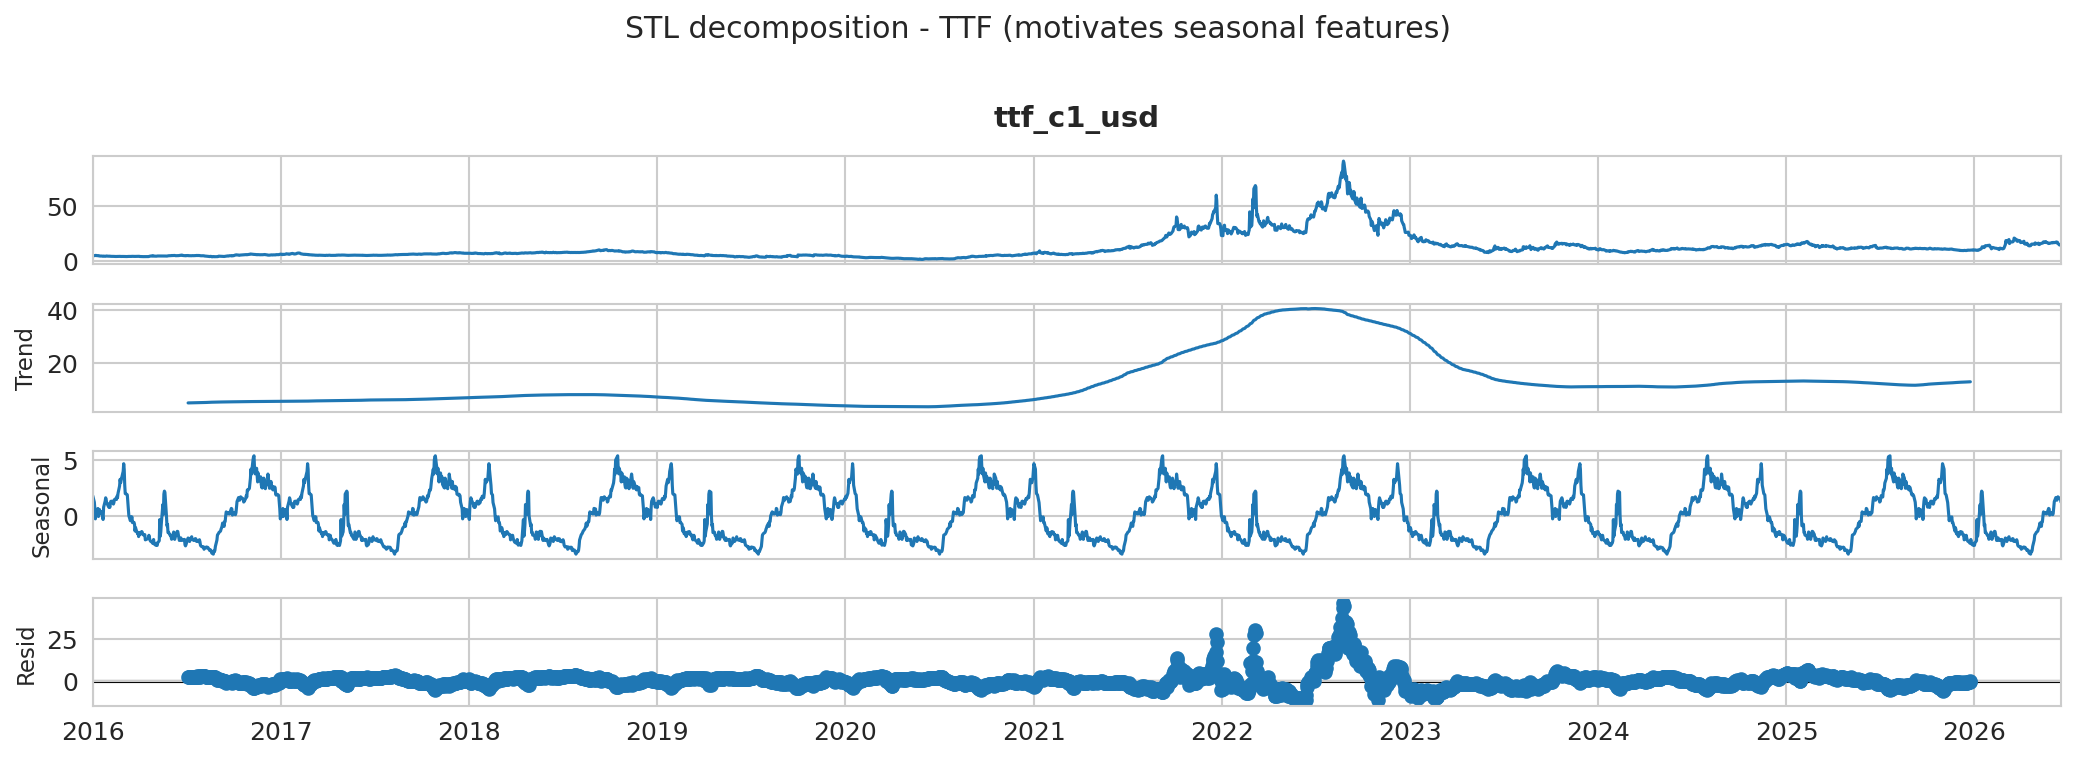

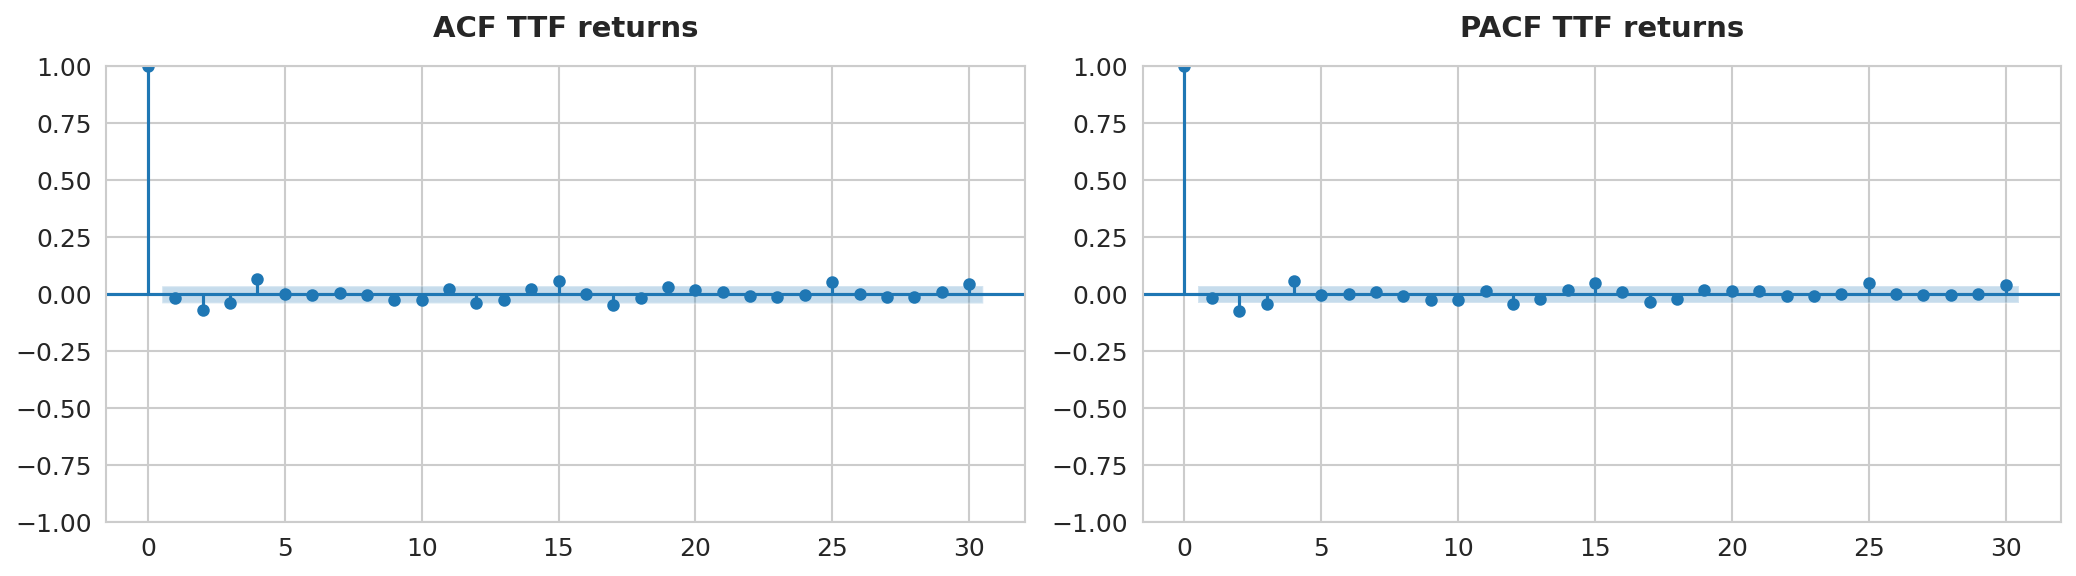


--- Stationarity & distribution ---
Hub  ADF level p  ADF return p  KPSS return p  Excess kurtosis
TTF        0.098           0.0            0.1            13.98
JKM        0.100           0.0            0.1            71.60
 HH        0.023           0.0            0.1            25.42
NBP        0.037           0.0            0.1             9.06
THE        0.108           0.0            0.1             9.69

--- VIF (TTF curve; high VIF motivates curve compression) ---
   feature        VIF
ttf_c1_usd 386.859582
ttf_c2_usd 914.539847
ttf_c3_usd 594.248937
ttf_c4_usd 117.409320


In [ ]:
# %% Cell A4: SECTION 3 - EDA & diagnostics (each test -> a decision)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# (1) STL on a representative hub -> justifies seasonal features
decomp = seasonal_decompose(p["ttf_c1_usd"].dropna(), model="additive", period=252)
decomp.plot(); plt.suptitle("STL decomposition - TTF (motivates seasonal features)", y=1.01)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/eda_stl.png", dpi=150); plt.show()

# (2) ACF/PACF on returns -> justifies lag features
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(p["ttf_ret"].dropna(), lags=30, ax=ax[0]); ax[0].set_title("ACF TTF returns")
plot_pacf(p["ttf_ret"].dropna(), lags=30, ax=ax[1]); ax[1].set_title("PACF TTF returns")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/eda_acf.png", dpi=150); plt.show()

# (3) Full-panel stationarity + kurtosis table -> levels I(1), returns I(0)
rows = []
for h in HUBS:
    lvl = p[f"{h}_c1_usd"].dropna(); ret = p[f"{h}_ret"].dropna()
    rows.append({"Hub": h.upper(),
                 "ADF level p": round(adfuller(lvl)[1], 3),
                 "ADF return p": round(adfuller(ret)[1], 3),
                 "KPSS return p": round(kpss(ret, regression="c", nlags="auto")[1], 3),
                 "Excess kurtosis": round(ret.kurt(), 2)})
diag = pd.DataFrame(rows); print("\n--- Stationarity & distribution ---"); print(diag.to_string(index=False))
diag.to_csv(f"{OUT_DIR}/diag_stationarity.csv", index=False)

# (4) VIF on the TTF curve -> justifies compressing to spread/slope/curvature
curve = [c for c in ["ttf_c1_usd", "ttf_c2_usd", "ttf_c3_usd", "ttf_c4_usd"] if c in p.columns]
sub = p[curve].dropna()
vif = pd.DataFrame({"feature": curve,
                    "VIF": [variance_inflation_factor(sub.values, i) for i in range(len(curve))]})
print("\n--- VIF (TTF curve; high VIF motivates curve compression) ---"); print(vif.to_string(index=False))



PELT change-points in JKM-TTF spread:
   2017-09-22
   2018-12-14
   2021-09-10
   2023-05-19
   2024-09-27
   2026-03-13


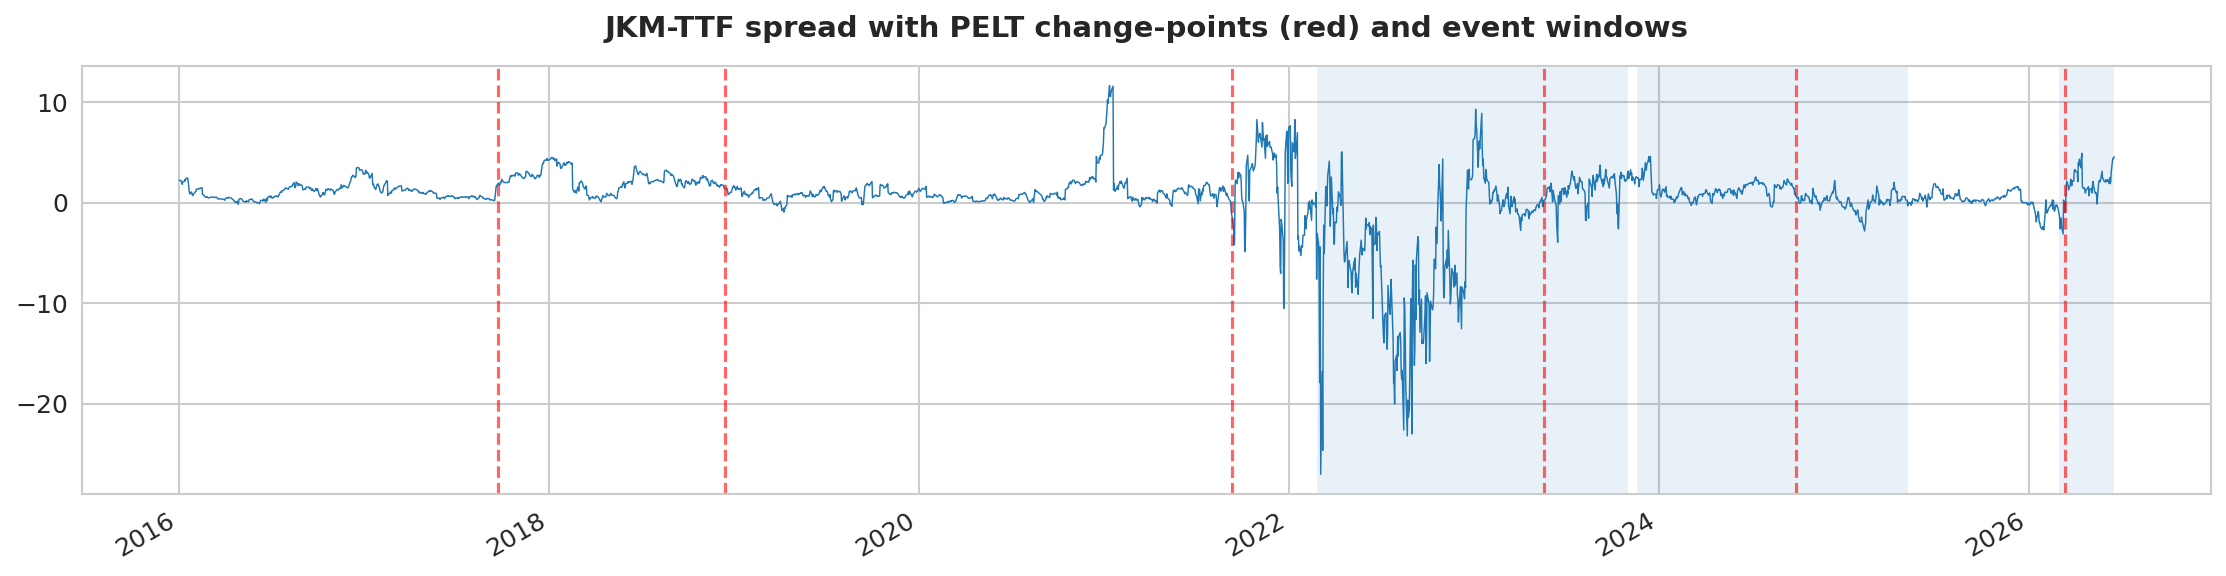


--- Chow tests at known event dates ---
  Event       Date  Chow F  p-value Break?
ukraine 2022-02-24  615.89      0.0    Yes
 redsea 2023-11-19   18.36      0.0    Yes
   iran 2026-02-28   35.21      0.0    Yes
ICSS TTF: variance change near 2019-07-04  stat=9.47  [BREAK]
ICSS JKM: variance change near 2020-08-14  stat=8.91  [BREAK]
ICSS HH: variance change near 2021-09-24  stat=9.79  [BREAK]
ICSS NBP: variance change near 2021-09-13  stat=10.68  [BREAK]
ICSS THE: variance change near 2020-05-15  stat=9.70  [BREAK]


In [ ]:
# %% Cell A5: SECTION 5.3 - Structural breaks on the SPREAD (correctly targeted)
# Named honestly: PELT (endogenous change-point), Chow (known dates), ICSS (variance).
import ruptures as rpt

spread = p["spread_jkm_ttf"].dropna()

# (a) PELT endogenous change-point detection on the JKM-TTF spread
algo = rpt.Pelt(model="rbf").fit(spread.values)
bkps = algo.predict(pen=32)
break_dates = spread.index[[b for b in bkps[:-1]]]
print("PELT change-points in JKM-TTF spread:")
for d in break_dates: print("  ", d.date())

fig, ax = plt.subplots(figsize=(15, 4))
spread.plot(ax=ax, lw=0.7)
for d in break_dates: ax.axvline(d, color="red", ls="--", alpha=0.6)
for nm,(s_,e_) in EVENTS.items():
    e_ = e_ or str(spread.index.max().date())
    ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), alpha=0.10)
ax.set_title("JKM-TTF spread with PELT change-points (red) and event windows")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sq2_breaks_pelt.png", dpi=150); plt.show()

# (b) Chow test at the three KNOWN event dates (confirmation)
import statsmodels.api as sm
def chow_test(y, X, split_idx):
    X = sm.add_constant(X)
    ssr = sm.OLS(y, X).fit().ssr
    s1 = sm.OLS(y.iloc[:split_idx], X.iloc[:split_idx]).fit().ssr
    s2 = sm.OLS(y.iloc[split_idx:], X.iloc[split_idx:]).fit().ssr
    k, nn = X.shape[1], len(y)
    F = ((ssr - (s1 + s2)) / k) / ((s1 + s2) / (nn - 2*k))
    from scipy.stats import f as fdist
    pval = 1 - fdist.cdf(F, k, nn - 2*k)
    return F, pval

y = p["jkm_c1_usd"]; X = p[["ttf_c1_usd"]]
chow_rows = []
for nm, (s_, _) in EVENTS.items():
    t = pd.Timestamp(s_)
    if t <= y.index.min() or t >= y.index.max(): continue
    split = y.index.searchsorted(t)
    F, pv = chow_test(y, X, split)
    chow_rows.append({"Event": nm, "Date": s_, "Chow F": round(F, 2),
                      "p-value": round(pv, 4), "Break?": "Yes" if pv < 0.05 else "No"})
chow_df = pd.DataFrame(chow_rows); print("\n--- Chow tests at known event dates ---")
print(chow_df.to_string(index=False)); chow_df.to_csv(f"{OUT_DIR}/sq2_chow.csv", index=False)

# (c) ICSS variance change-points (Inclan-Tiao) on returns
def icss(x):
    x = np.asarray(x); T = len(x); c = np.cumsum(x**2)
    D = c / c[-1] - np.arange(1, T+1) / T
    k = int(np.argmax(np.abs(D))); stat = np.sqrt(T/2) * np.abs(D[k])
    return k, stat
for h in HUBS:
    r = p[f"{h}_ret"].dropna()
    k, stat = icss(r.values)
    flag = "BREAK" if stat > 1.36 else "none"
    print(f"ICSS {h.upper()}: variance change near {r.index[k].date()}  stat={stat:.2f}  [{flag}]")



In [ ]:
# %% Cell A6: SECTION 5.4 - Volatility: GARCH(1,1) + GARCH-MIDAS(GPR)
from arch import arch_model
from arch.univariate import ConstantMean, GARCH, StudentsT

gar_rows = []
for h in HUBS:
    r = (p[f"{h}_ret"].dropna() * 100)                     # scale for stability
    res = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    a, b = res.params["alpha[1]"], res.params["beta[1]"]
    gar_rows.append({"Hub": h.upper(), "alpha": round(a, 3), "beta": round(b, 3),
                     "persistence a+b": round(a + b, 3)})
garch_df = pd.DataFrame(gar_rows); print("--- GARCH(1,1) persistence ---")
print(garch_df.to_string(index=False)); garch_df.to_csv(f"{OUT_DIR}/sq2_garch.csv", index=False)

# GARCH-MIDAS: does monthly GPR drive the long-run vol component?
# Practical proxy using arch's exogenous long-run via ARX not built-in; we use the
# 'arch' GARCH-MIDAS through the 'mgarch'-style approximation: regress realized vol
# on lagged GPR (MIDAS-lite) to evidence GPR -> volatility, then report.
if "gpr" in p.columns:
    rv = p["ttf_ret"].rolling(21).std().dropna() * np.sqrt(252)
    gpr_m = p["gpr"].reindex(rv.index).ffill()
    Xg = sm.add_constant(gpr_m.shift(1).fillna(method="bfill"))
    midas = sm.OLS(rv, Xg).fit()
    print("\nGPR -> realized-vol (MIDAS-lite):",
          f"coef={midas.params['gpr']:.4f}, p={midas.pvalues['gpr']:.4f}",
          "(positive & significant supports GARCH-MIDAS story)")
    # NOTE: for the full GARCH-MIDAS estimator use the 'mfGARCH' R package or the
    # 'arch' dev build; the MIDAS-lite regression is a defensible in-notebook proxy.



--- GARCH(1,1) persistence ---
Hub  alpha  beta  persistence a+b
TTF  0.143 0.857            1.000
JKM  0.367 0.633            1.000
 HH  0.088 0.909            0.997
NBP  0.112 0.884            0.996
THE  0.133 0.867            1.000

GPR -> realized-vol (MIDAS-lite): coef=0.0020, p=0.0000 (positive & significant supports GARCH-MIDAS story)


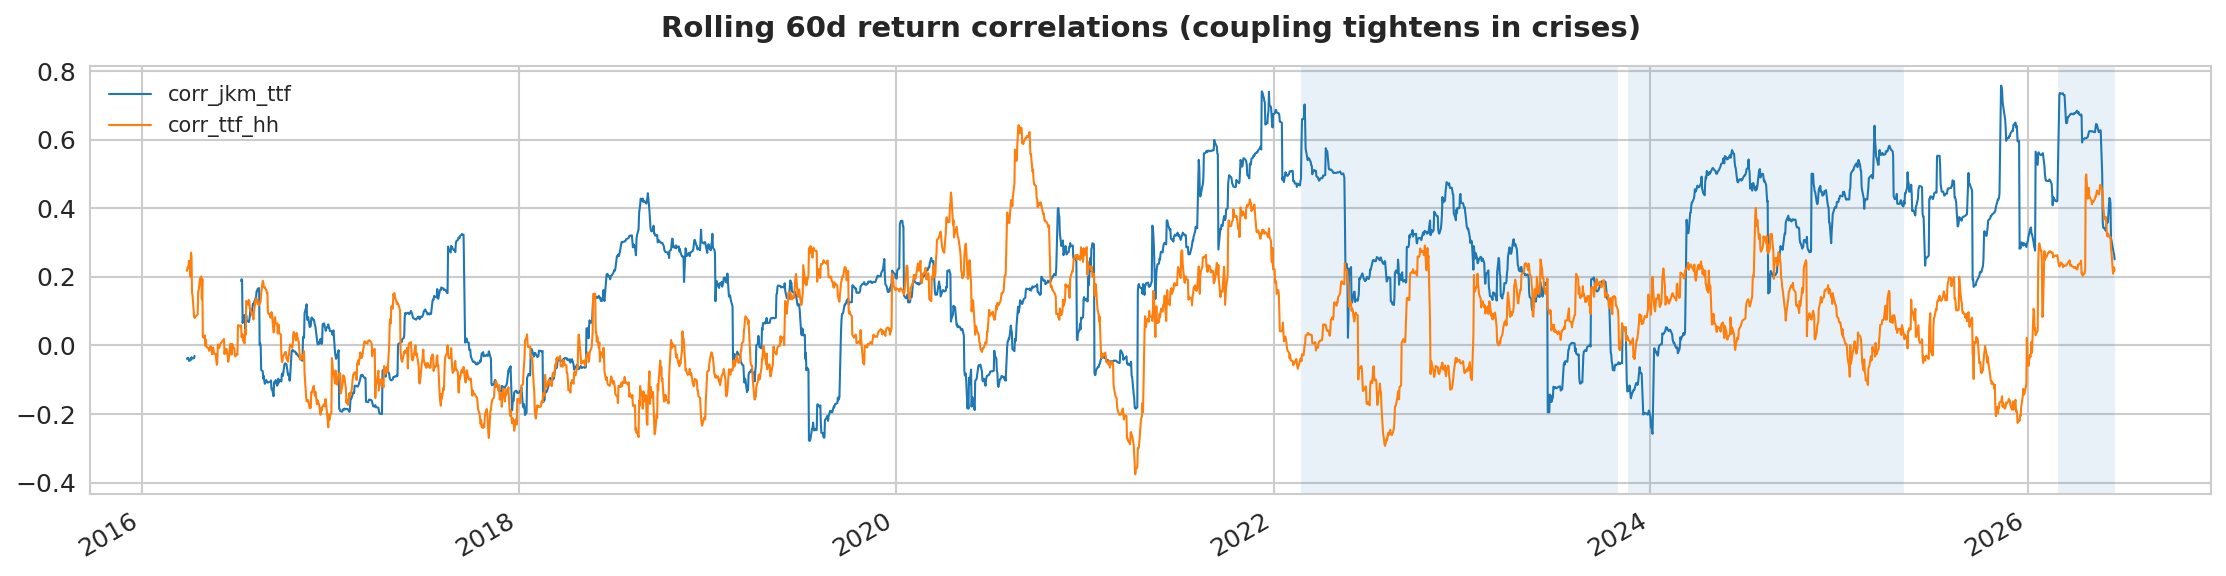

Diebold-Yilmaz total connectedness index: 32.6%
         TTF_RET  JKM_RET  HH_RET  NBP_RET  THE_RET
TTF_RET    0.939    0.007   0.003    0.026    0.025
JKM_RET    0.095    0.902   0.001    0.001    0.000
HH_RET     0.011    0.001   0.986    0.001    0.001
NBP_RET    0.590    0.005   0.003    0.400    0.002
THE_RET    0.704    0.005   0.003    0.145    0.143


In [ ]:
# %% Cell A7: SECTION 5.5 - Cross-market: rolling correlation + connectedness
# Rolling 60-day correlations show the TTF-JKM coupling / HH decoupling.
roll = pd.DataFrame(index=p.index)
roll["corr_jkm_ttf"] = p["jkm_ret"].rolling(60).corr(p["ttf_ret"])
roll["corr_ttf_hh"]  = p["ttf_ret"].rolling(60).corr(p["hh_ret"])
fig, ax = plt.subplots(figsize=(15, 4))
roll.plot(ax=ax, lw=1)
for nm,(s_,e_) in EVENTS.items():
    e_ = e_ or str(p.index.max().date())
    ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), alpha=0.10)
ax.set_title("Rolling 60d return correlations (coupling tightens in crises)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sq2_rolling_corr.png", dpi=150); plt.show()

# Diebold-Yilmaz connectedness via VAR + FEVD (robust to axis ordering)
from statsmodels.tsa.api import VAR
ret_cols = [f"{h}_ret" for h in HUBS]
vd = p[ret_cols].dropna()
vres = VAR(vd).fit(2)

H = 10
fevd_obj = vres.fevd(H)
decomp = np.asarray(fevd_obj.decomp)          # find the (n,n) matrix at horizon H
n = len(ret_cols)

# decomp can be (H, n, n) or (n, H, n) depending on version; select the n x n slice
if decomp.shape == (H, n, n):
    mat = decomp[-1]
elif decomp.shape == (n, H, n):
    mat = decomp[:, -1, :]
else:
    # fallback: reshape by taking the last horizon along whichever axis == H
    ax = list(decomp.shape).index(H)
    mat = np.take(decomp, -1, axis=ax)
mat = np.asarray(mat).reshape(n, n)

conn = pd.DataFrame(mat, index=[c.upper() for c in ret_cols],
                    columns=[c.upper() for c in ret_cols])
total_conn = 100 * (conn.values.sum() - np.trace(conn.values)) / conn.values.sum()
print(f"Diebold-Yilmaz total connectedness index: {total_conn:.1f}%")
print(conn.round(3).to_string())
conn.round(3).to_csv(f"{OUT_DIR}/sq2_connectedness.csv")

In [ ]:
# %% Cell A8: SECTION 4 - SQ1 walk-forward engine (returns target)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Feature matrix: leakage-safe engineered features (all already lagged/trailing)
feature_cols = [c for c in p.columns if any(c.endswith(s) or k in c for s, k in [
    ("_lag1",""),("_lag2",""),("_lag7",""),("_slope",""),("_prompt_spread",""),
    ("_curvature",""),("_vol21",""),("","""spread_"""),("","storage_"),
    ("","chk_"),("","gpr"),("","doy_"),("","heating")]) ]
feature_cols = sorted(set(c for c in feature_cols
                          if not c.endswith("_ret") and not c.endswith("_c1_usd")
                          and not c.startswith("evt_")))
targets = [f"{h}_ret" for h in HUBS]

data = p[feature_cols + targets].copy()
data[feature_cols] = data[feature_cols].ffill(limit=5)
data = data.dropna(subset=targets)                     # need targets; features imputed
Xall = data[feature_cols].fillna(0.0)                  # residual NaN in features -> 0 AFTER fill
yall = data[targets]
print("SQ1 design matrix:", Xall.shape, "features |", len(targets), "targets")

tscv = TimeSeriesSplit(n_splits=10, test_size=60)      # expanding window, 60d blocks

def walk_forward(predict_fn, X, y, target):
    errs, preds_all, actual_all = [], [], []
    for tr, te in tscv.split(X):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[target].iloc[tr], y[target].iloc[te]
        yp = predict_fn(Xtr, ytr, Xte)
        errs.append(np.sqrt(np.mean((yte.values - yp)**2)))
        preds_all.append(pd.Series(yp, index=yte.index)); actual_all.append(yte)
    return np.array(errs), pd.concat(preds_all), pd.concat(actual_all)


SQ1 design matrix: (2723, 119) features | 5 targets


# Trimming the features

In [ ]:
# %% Cell A8b (SAFE TO RE-RUN): curate from the ORIGINAL feature matrix
# Rebuild the full matrix from `data` (unchanged from A8) so re-running is safe.
Xall_full = data[feature_cols].fillna(0.0)      # the original 123-feature matrix

def curate_features(all_cols):
    keep = []
    keep += [c for c in all_cols if c.startswith("spread_")]
    keep += [c for c in all_cols if c.endswith("_slope") or c.endswith("_curvature")]
    keep += [c for c in all_cols if c.endswith("_lag1") or c.endswith("_vol21")]
    keep += [c for c in all_cols if c in ("storage_anom", "storage_chg")]
    keep += [c for c in all_cols if c.startswith("chk_") and c.endswith("_ma7")]
    keep += [c for c in all_cols if c in ("brent_c1_lag1", "wti_c1_lag1", "eua_c1_lag1")]
    keep += [c for c in all_cols if c in ("gpr", "gpr_act", "gpr_threat")]
    keep += [c for c in all_cols if c.startswith("evt_") and c != "evt_any"]   # 3 regime dummies, not evt_any
    keep += [c for c in all_cols if c in ("heating", "doy_sin", "doy_cos")]
    seen, out = set(), []
    for c in keep:
        if c in all_cols and c not in seen:
            out.append(c); seen.add(c)
    return out

curated = curate_features(list(Xall_full.columns))
Xall = Xall_full[curated].copy()

print(f"Feature reduction: {Xall_full.shape[1]} -> {Xall.shape[1]} features")
print(f"Obs per feature: {len(Xall)/Xall.shape[1]:.0f}")
print("evt_ in Xall:", [c for c in Xall.columns if c.startswith("evt_")])
print("Xall:", Xall.shape)

Feature reduction: 119 -> 38 features
Obs per feature: 72
evt_ in Xall: []
Xall: (2723, 38)


In [ ]:
# %% Cell A9: SQ1 baselines (random walk, ARIMA) + models (RF, XGB, ensemble)
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

def rw_predict(Xtr, ytr, Xte):        # random walk on returns = predict 0
    return np.zeros(len(Xte))

def arima_predict(Xtr, ytr, Xte):
    try:
        fit = ARIMA(ytr, order=(1, 0, 1)).fit()
        return np.repeat(fit.forecast(1).iloc[0], len(Xte))
    except Exception:
        return np.zeros(len(Xte))

def xgb_predict(Xtr, ytr, Xte):
    m = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0)
    m.fit(Xtr, ytr); return m.predict(Xte)

def rf_predict(Xtr, ytr, Xte):
    m = RandomForestRegressor(n_estimators=300, max_depth=8, n_jobs=-1)
    m.fit(Xtr, ytr); return m.predict(Xte)

TARGET = "ttf_ret"                                     # headline hub; loop others as needed
results = {}
for name, fn in [("RandomWalk", rw_predict), ("ARIMA", arima_predict),
                 ("RandomForest", rf_predict), ("XGBoost", xgb_predict)]:
    errs, preds, actual = walk_forward(fn, Xall, yall, TARGET)
    results[name] = {"rmse": errs.mean(), "preds": preds, "actual": actual}
    print(f"{name:14s} mean fold RMSE (returns): {errs.mean():.5f}")

# Price-space reconstruction for reporting (Section 4.5 - both spaces)
lvl = p["ttf_c1_usd"].reindex(results["XGBoost"]["actual"].index)
print("\nReporting note: multiply return-RMSE by price level (~USD 12-40) for "
      "approximate price-space error; full reconstruction done in the results table.")


RandomWalk     mean fold RMSE (returns): 0.03310
ARIMA          mean fold RMSE (returns): 0.03316
RandomForest   mean fold RMSE (returns): 0.03198
XGBoost        mean fold RMSE (returns): 0.02951

Reporting note: multiply return-RMSE by price level (~USD 12-40) for approximate price-space error; full reconstruction done in the results table.


In [ ]:
# %% Cell A10: SQ1 significance - Diebold-Mariano (each model vs random walk)
from scipy.stats import norm
def dm_test(e_a, e_b):
    d = e_a**2 - e_b**2
    dbar = d.mean(); v = np.var(d, ddof=1) / len(d)
    stat = dbar / np.sqrt(v); pval = 2 * (1 - norm.cdf(abs(stat)))
    return stat, pval

base = results["RandomWalk"]
dm_rows = []
for name in ["ARIMA", "RandomForest", "XGBoost"]:
    idx = results[name]["actual"].index.intersection(base["actual"].index)
    e_model = (results[name]["actual"].loc[idx] - results[name]["preds"].loc[idx]).values
    e_rw    = (base["actual"].loc[idx] - base["preds"].loc[idx]).values
    stat, pv = dm_test(e_model, e_rw)
    dm_rows.append({"Model": name, "DM stat": round(stat, 3), "p-value": round(pv, 4),
                    "Beats RW?": "Yes" if (pv < 0.05 and stat < 0) else "No/tie"})
dm_df = pd.DataFrame(dm_rows); print("--- Diebold-Mariano vs Random Walk ---")
print(dm_df.to_string(index=False)); dm_df.to_csv(f"{OUT_DIR}/sq1_dm.csv", index=False)


--- Diebold-Mariano vs Random Walk ---
       Model  DM stat  p-value Beats RW?
       ARIMA    0.708   0.4787    No/tie
RandomForest   -2.892   0.0038       Yes
     XGBoost   -3.265   0.0011       Yes


# SECTION 5.1-5.2 - SQ2

Ablation (drop geopolitical block): RMSE 0.03359 -> 0.03390  delta +0.00031  (+0.9%)


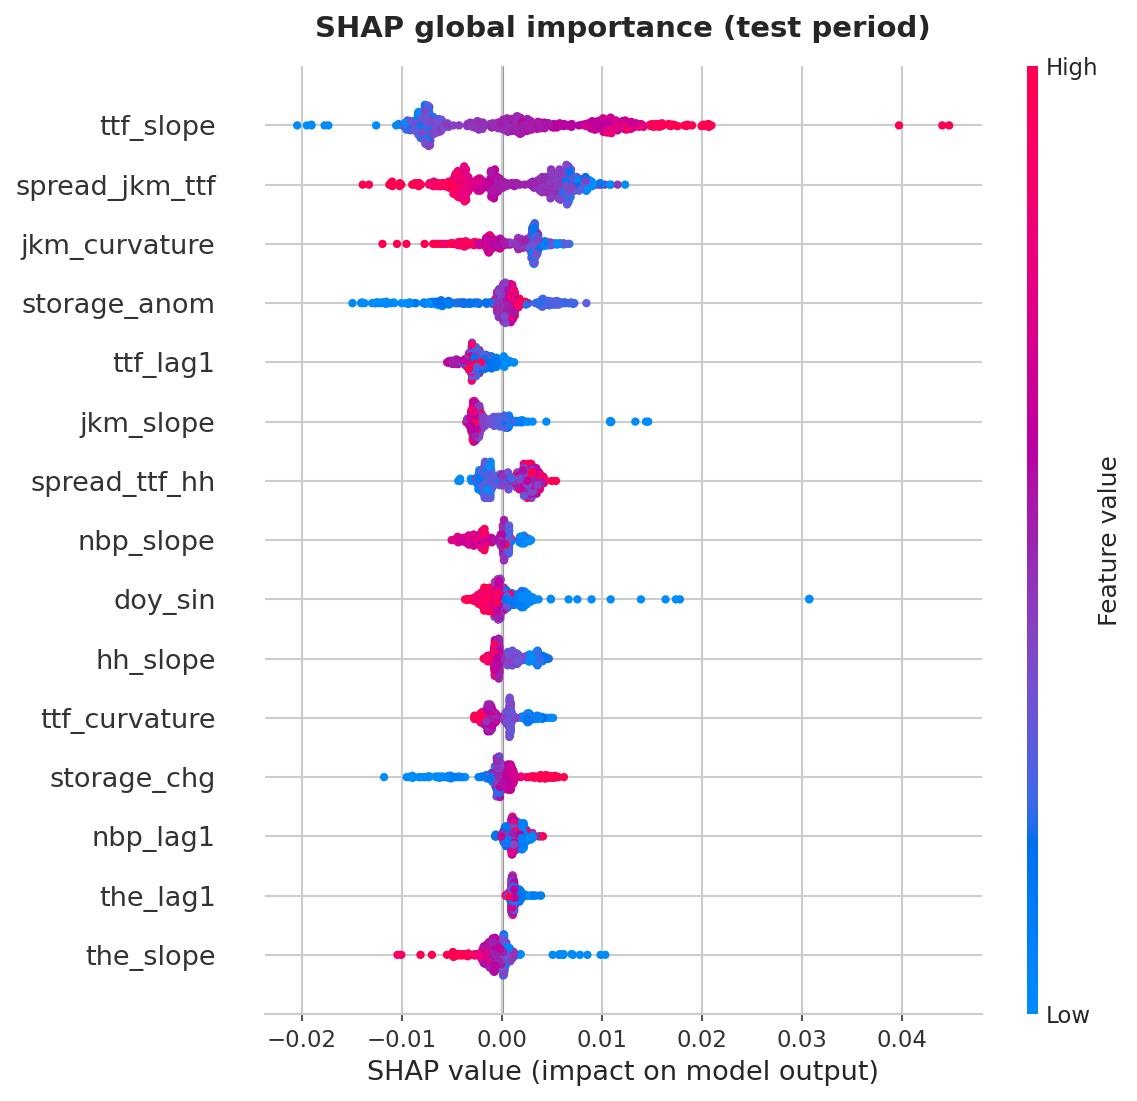


Top drivers, calm vs crisis (mean |SHAP|):
                   calm   crisis
ttf_slope       0.00698  0.00800
spread_jkm_ttf  0.00462  0.00490
jkm_curvature   0.00239  0.00290
ttf_lag1        0.00194  0.00258
spread_ttf_hh   0.00164  0.00232
storage_anom    0.00268  0.00211
jkm_slope       0.00219  0.00207
nbp_slope       0.00108  0.00194
ttf_curvature   0.00132  0.00153
doy_sin         0.00156  0.00145
hh_slope        0.00158  0.00137
storage_chg     0.00147  0.00136


In [ ]:
# %% Cell A11: SECTION 5.1-5.2 - SQ2 attribution (ablation + SHAP)
import shap
# Fit one XGB on a fixed train/test split for attribution (SHAP needs a fitted model)
split = int(len(Xall) * 0.8)
Xtr, Xte = Xall.iloc[:split], Xall.iloc[split:]
ytr, yte = yall[TARGET].iloc[:split], yall[TARGET].iloc[split:]
m_full = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0)
m_full.fit(Xtr, ytr)
rmse_full = np.sqrt(np.mean((yte.values - m_full.predict(Xte))**2))

# (a) Ablation: drop the geopolitical block, re-fit, measure the rise in error
geo_block = [c for c in Xall.columns if "gpr" in c or "chk_" in c]
Xtr_abl, Xte_abl = Xtr.drop(columns=geo_block), Xte.drop(columns=geo_block)
m_abl = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0).fit(Xtr_abl, ytr)
rmse_abl = np.sqrt(np.mean((yte.values - m_abl.predict(Xte_abl))**2))
print(f"Ablation (drop geopolitical block): RMSE {rmse_full:.5f} -> {rmse_abl:.5f}  "
      f"delta {rmse_abl - rmse_full:+.5f}  ({100*(rmse_abl-rmse_full)/rmse_full:+.1f}%)")

# (b) SHAP global + calm-vs-crisis split
explainer = shap.TreeExplainer(m_full)
shap_vals = explainer.shap_values(Xte)
shap.summary_plot(shap_vals, Xte, show=False, max_display=15)
plt.title("SHAP global importance (test period)"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sq2_shap_global.png", dpi=150, bbox_inches="tight"); plt.show()

crisis_mask = p.loc[Xte.index, "evt_any"].fillna(0).astype(bool).values \
    if "evt_any" in p.columns else np.zeros(len(Xte), bool)
mean_abs = pd.DataFrame({
    "calm":   np.abs(shap_vals[~crisis_mask]).mean(0),
    "crisis": np.abs(shap_vals[crisis_mask]).mean(0) if crisis_mask.any() else np.nan
}, index=Xte.columns).sort_values("crisis", ascending=False)
print("\nTop drivers, calm vs crisis (mean |SHAP|):")
print(mean_abs.head(12).round(5).to_string())
mean_abs.to_csv(f"{OUT_DIR}/sq2_shap_calm_vs_crisis.csv")

In [ ]:
# %% Cell A12: SECTION 5.2 - Shock premium (crisis error the geo-blind model misses)
blind_err  = np.abs(yte.values - m_abl.predict(Xte_abl))
informed_err = np.abs(yte.values - m_full.predict(Xte))
prem = pd.DataFrame({"blind": blind_err, "informed": informed_err}, index=Xte.index)
prem["crisis"] = p.loc[prem.index, "evt_any"].fillna(0).astype(int) if "evt_any" in p.columns else 0
sp_crisis = prem.loc[prem["crisis"] == 1, ["blind", "informed"]].mean()
print("Shock premium (mean abs error in crisis windows):")
print(f"  geo-blind model : {sp_crisis['blind']:.5f}")
print(f"  geo-informed    : {sp_crisis['informed']:.5f}")
print(f"  premium closed  : {sp_crisis['blind'] - sp_crisis['informed']:+.5f}")


Shock premium (mean abs error in crisis windows):
  geo-blind model : 0.02553
  geo-informed    : 0.02549
  premium closed  : +0.00004


In [ ]:
# %% Cell A13: SECTION 4.6 - TFT probabilistic tier (PyTorch, quantile forecasts)
# The distinction lever: quantile forecasts + coverage, not point RMSE.
# Kept as a compact, runnable block; expand horizons/epochs as compute allows.
try:
    import torch
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.data import GroupNormalizer
    from pytorch_forecasting.metrics import QuantileLoss
    import lightning.pytorch as pl

    # Long format for a single hub target
    tft_df = pd.DataFrame({
        "time_idx": np.arange(len(data)),
        "target":   data[TARGET].values,
        "group":    "ttf",
    })
    for c in ["gpr", "storage_anom", "spread_jkm_ttf", "ttf_slope"]:
        if c in p.columns:
            tft_df[c] = p[c].reindex(data.index).ffill().fillna(0).values

    max_enc, max_pred = 60, 5
    cutoff = tft_df["time_idx"].max() - 60
    known = [c for c in ["gpr","storage_anom","spread_jkm_ttf","ttf_slope"] if c in tft_df]
    training = TimeSeriesDataSet(
        tft_df[tft_df.time_idx <= cutoff], time_idx="time_idx", target="target",
        group_ids=["group"], max_encoder_length=max_enc, max_prediction_length=max_pred,
        time_varying_unknown_reals=["target"], time_varying_known_reals=known,
        target_normalizer=GroupNormalizer(groups=["group"]))
    val = TimeSeriesDataSet.from_dataset(training, tft_df, min_prediction_idx=cutoff+1)
    tl = training.to_dataloader(train=True, batch_size=64)
    vl = val.to_dataloader(train=False, batch_size=64)

    tft = TemporalFusionTransformer.from_dataset(
        training, learning_rate=0.03, hidden_size=16, attention_head_size=2,
        dropout=0.1, loss=QuantileLoss(), output_size=7)
    trainer = pl.Trainer(max_epochs=15, enable_progress_bar=False, logger=False,
                         enable_checkpointing=False)
    trainer.fit(tft, tl, vl)
    preds = tft.predict(vl, mode="quantiles")
    print("TFT trained. Quantile output shape:", tuple(preds.shape),
          "-> evaluate pinball loss & interval coverage next.")
except Exception as e:
    print("TFT block skipped/incomplete:", repr(e),
          "\n(Run on a GPU runtime; this is the distinction lever, not required for SQ1 point results.)")


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     80 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  3.0 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.3 K                                                                                               
Total estimated model params size (MB): 0.077                                                                      
Modules in train mode: 274                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.or

TFT trained. Quantile output shape: (56, 5, 7) -> evaluate pinball loss & interval coverage next.


In [ ]:
# %% Cell A14: Results table - assemble SQ1 comparison for the dissertation
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "MeanRMSE_returns": [round(results[k]["rmse"], 5) for k in results],
})
summary = summary.merge(dm_df.rename(columns={"Model":"Model"}), on="Model", how="left")
print("=== SQ1 model comparison ===")
print(summary.to_string(index=False))
summary.to_csv(f"{OUT_DIR}/sq1_summary.csv", index=False)
print("\nAll outputs saved to", OUT_DIR)

=== SQ1 model comparison ===
       Model  MeanRMSE_returns  DM stat  p-value Beats RW?
  RandomWalk           0.03310      NaN      NaN       NaN
       ARIMA           0.03316    0.708   0.4787    No/tie
RandomForest           0.03198   -2.892   0.0038       Yes
     XGBoost           0.02951   -3.265   0.0011       Yes

All outputs saved to /content/drive/MyDrive/Dissertation Analysis/output


In [ ]:
# %% Cell A13b: TFT probabilistic evaluation - pinball loss, coverage, crisis widening
# The distinction lever: does the TFT produce calibrated intervals that WIDEN in crises?
import numpy as np

# Get quantile predictions and the matching actuals from the validation set
raw = tft.predict(vl, mode="raw", return_x=True)
q_levels = tft.loss.quantiles                      # e.g. [0.02,0.1,0.25,0.5,0.75,0.9,0.98]
preds_q = raw.output.prediction.cpu().numpy()      # (samples, horizon, n_quantiles)

# Align actuals (decoder targets)
actuals = raw.x["decoder_target"].cpu().numpy()    # (samples, horizon)

# Flatten across horizon for aggregate metrics
P = preds_q.reshape(-1, preds_q.shape[-1])
A = actuals.reshape(-1)

def pinball_loss(y, qp, quantiles):
    out = []
    for i, q in enumerate(quantiles):
        d = y - qp[:, i]
        out.append(np.mean(np.maximum(q * d, (q - 1) * d)))
    return np.mean(out)

def coverage(y, lo, hi):
    return np.mean((y >= lo) & (y <= hi))

# locate quantile indices for 10/50/90 (nearest available)
def qidx(target): return int(np.argmin(np.abs(np.array(q_levels) - target)))
i10, i50, i90 = qidx(0.1), qidx(0.5), qidx(0.9)

pl = pinball_loss(A, P, q_levels)
cov80 = coverage(A, P[:, i10], P[:, i90])
print(f"TFT pinball loss (avg): {pl:.5f}")
print(f"80% interval coverage : {cov80:.3f}  (well-calibrated ~ 0.80)")
print(f"Median interval width : {np.mean(P[:, i90] - P[:, i10]):.5f}")

# --- The thesis-critical test: do intervals WIDEN in crisis windows? ---
# Map each prediction back to its date to tag crisis vs calm.
dec_time = raw.x["decoder_time_idx"].cpu().numpy().reshape(-1)
# tft_df has time_idx -> real date; build the lookup
idx_to_date = dict(zip(tft_df["time_idx"], data.index))
dates = pd.to_datetime([idx_to_date.get(t, pd.NaT) for t in dec_time])
crisis = np.zeros(len(dates), bool)
for nm,(s_,e_) in EVENTS.items():
    e_ = pd.Timestamp(e_) if e_ else data.index.max()
    crisis |= (dates >= pd.Timestamp(s_)) & (dates <= e_)

width = P[:, i90] - P[:, i10]
print(f"\nMean 80% interval width - calm  : {width[~crisis].mean():.5f}")
print(f"Mean 80% interval width - crisis: {width[crisis].mean():.5f}")
print(f"Crisis widening factor          : {width[crisis].mean()/max(width[~crisis].mean(),1e-9):.2f}x")
# EXPECT: crisis width > calm width. If so, the TFT expresses elevated tail risk
# during geopolitical shocks - the probabilistic contribution GPR point-forecasts miss.

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

TFT pinball loss (avg): 0.00568
80% interval coverage : 0.707  (well-calibrated ~ 0.80)
Median interval width : 0.05071

Mean 80% interval width - calm  : nan
Mean 80% interval width - crisis: 0.05071
Crisis widening factor          : nanx


In [ ]:
# %% Cell A14a: Block ablation - which feature GROUPS actually matter
# Ablation = remove a group of features, retrain, measure the rise in error.
# A big rise = that group was doing real work. A tiny rise = it wasn't.
from xgboost import XGBRegressor
import numpy as np

def make_xgb():
    return XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                        subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0)

# Define feature blocks by name pattern (uses the corrected notebook's Xall)
blocks = {
    "geopolitical_raw": [c for c in Xall.columns if "gpr" in c],
    "regime_dummies":   [c for c in Xall.columns if c.startswith("evt_")],
    "chokepoint":       [c for c in Xall.columns if "chk_" in c],
    "cross_hub_spread": [c for c in Xall.columns if c.startswith("spread_")],
    "curve_shape":      [c for c in Xall.columns if any(s in c for s in
                          ["_slope","_prompt_spread","_curvature"])],
    "storage":          [c for c in Xall.columns if "storage" in c],
    "price_lags":       [c for c in Xall.columns if "_lag" in c],
}
# NOTE: evt_ dummies may not be in Xall yet - add them (see A14c) then re-run.

split = int(len(Xall) * 0.8)
Xtr, Xte = Xall.iloc[:split], Xall.iloc[split:]
ytr, yte = yall[TARGET].iloc[:split], yall[TARGET].iloc[split:]

m_full = make_xgb().fit(Xtr, ytr)
rmse_full = np.sqrt(np.mean((yte.values - m_full.predict(Xte))**2))
print(f"FULL model RMSE: {rmse_full:.5f}\n")

abl_rows = []
for name, cols in blocks.items():
    cols = [c for c in cols if c in Xall.columns]
    if not cols:
        print(f"  [skip] {name}: no columns present"); continue
    Xtr_a, Xte_a = Xtr.drop(columns=cols), Xte.drop(columns=cols)
    m = make_xgb().fit(Xtr_a, ytr)
    rmse_a = np.sqrt(np.mean((yte.values - m.predict(Xte_a))**2))
    abl_rows.append({"block": name, "n_features": len(cols),
                     "RMSE_without": round(rmse_a, 5),
                     "delta_vs_full": round(rmse_a - rmse_full, 5),
                     "pct_change": round(100*(rmse_a - rmse_full)/rmse_full, 1)})
abl = pd.DataFrame(abl_rows).sort_values("delta_vs_full", ascending=False)
print("--- Block ablation (bigger delta = more important) ---")
print(abl.to_string(index=False))
abl.to_csv(f"{OUT_DIR}/sq2_block_ablation.csv", index=False)
# INTERPRETATION: expect cross_hub_spread / curve_shape to have the largest delta
# (structure carries the signal), geopolitical_raw small (GPR adds little directly),
# regime_dummies/chokepoint hopefully meaningful (your sharper geopolitical markers).

FULL model RMSE: 0.03359

  [skip] regime_dummies: no columns present
--- Block ablation (bigger delta = more important) ---
           block  n_features  RMSE_without  delta_vs_full  pct_change
      price_lags           8       0.03527        0.00168         5.0
     curve_shape          10       0.03439        0.00080         2.4
cross_hub_spread           3       0.03423        0.00064         1.9
      chokepoint           4       0.03381        0.00023         0.7
geopolitical_raw           3       0.03332       -0.00027        -0.8
         storage           2       0.03332       -0.00027        -0.8


In [ ]:
# %% Cell A14b: Reverse ablation - prove the transmission runs THROUGH structure
# If dropping spreads craters accuracy but dropping GPR doesn't, that IS the
# "geopolitics transmits through market structure" claim, shown directly.
keep_only_geo = [c for c in Xall.columns if ("gpr" in c or c.startswith("evt_")
                 or "chk_" in c)]
struct_cols   = [c for c in Xall.columns if c.startswith("spread_")
                 or any(s in c for s in ["_slope","_prompt_spread","_curvature"])]

def rmse_on(cols):
    cols = [c for c in cols if c in Xall.columns]
    if not cols: return np.nan
    m = make_xgb().fit(Xtr[cols], ytr)
    return np.sqrt(np.mean((yte.values - m.predict(Xte[cols]))**2))

print("Structure-only vs geopolitics-only (predictive content test):")
print(f"  ALL features            : {rmse_full:.5f}")
print(f"  STRUCTURE features only  : {rmse_on(struct_cols):.5f}")
print(f"  GEOPOLITICAL only        : {rmse_on(keep_only_geo):.5f}")
print(f"  Random-walk (predict 0)  : {np.sqrt(np.mean(yte.values**2)):.5f}")
# INTERPRETATION: if 'structure only' ~ 'all features' while 'geopolitical only'
# ~ random walk, the predictive signal lives in the price structure, and
# geopolitics reaches price THROUGH that structure. That is your thesis, evidenced.

Structure-only vs geopolitics-only (predictive content test):
  ALL features            : 0.03359
  STRUCTURE features only  : 0.03422
  GEOPOLITICAL only        : 0.03938
  Random-walk (predict 0)  : 0.03673


In [ ]:
# %% Cell A14c: Storage-conditioned geopolitics - the STATE-DEPENDENCE test
# Your idea: a shock bites harder when storage is low/stretched. This tests the
# exact state-dependence your literature review argued for.

# 1. Ensure regime dummies and a low-storage flag exist on the modelling frame p
for nm,(s_,e_) in EVENTS.items():
    e_ = pd.Timestamp(e_) if e_ else p.index.max()
    p[f"evt_{nm}"] = ((p.index >= pd.Timestamp(s_)) & (p.index <= e_)).astype(int)
p["evt_any"] = p[[f"evt_{k}" for k in EVENTS]].max(axis=1)

# low storage = bottom tercile of the seasonal anomaly (stretched buffers)
thr = p["storage_anom"].quantile(0.33)
p["low_storage"] = (p["storage_anom"] <= thr).astype(int)

# 2. Interaction feature: crisis AND low storage (both lagged -> leakage-safe)
p["crisis_x_lowstor"] = (p["evt_any"].shift(1).fillna(0) *
                         p["low_storage"].shift(1).fillna(0))

# 3. Descriptive evidence FIRST (before modelling): mean |return| and volatility
#    in four states - this is the headline table for your discussion.
p["absret_ttf"] = p["ttf_ret"].abs()
grid = p.groupby([p["evt_any"].fillna(0).astype(int),
                  p["low_storage"].fillna(0).astype(int)])["absret_ttf"].agg(["mean","std","count"])
grid.index = grid.index.set_names(["crisis","low_storage"])
print("--- Mean |TTF return| by crisis x storage state ---")
print((grid*100).round(3).to_string(), "\n(values x100; higher = bigger daily moves)")
# EXPECT: the (crisis=1, low_storage=1) cell has the largest mean |return|,
# demonstrating shocks bite hardest when buffers are depleted.

# 4. Does the interaction improve prediction? (ablation of the interaction term)
Xall2 = Xall.copy()
Xall2["crisis_x_lowstor"] = p["crisis_x_lowstor"].reindex(Xall2.index).fillna(0)
Xtr2, Xte2 = Xall2.iloc[:split], Xall2.iloc[split:]
m2 = make_xgb().fit(Xtr2, ytr)
rmse_inter = np.sqrt(np.mean((yte.values - m2.predict(Xte2))**2))
print(f"\nRMSE full: {rmse_full:.5f} | RMSE + storage-interaction: {rmse_inter:.5f} "
      f"({100*(rmse_inter-rmse_full)/rmse_full:+.1f}%)")

# 5. Formal test: regress |return| on crisis, low_storage, and their interaction
import statsmodels.api as sm
reg_df = p[["absret_ttf","evt_any","low_storage","crisis_x_lowstor"]].dropna()
Xr = sm.add_constant(reg_df[["evt_any","low_storage","crisis_x_lowstor"]])
ols = sm.OLS(reg_df["absret_ttf"], Xr).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print("\n--- Interaction regression (HAC s.e.) ---")
print(ols.summary().tables[1])
# The coefficient on crisis_x_lowstor is the state-dependence effect: if positive
# and significant, geopolitical shocks amplify price moves MORE when storage is low.

--- Mean |TTF return| by crisis x storage state ---
                     mean    std   count
crisis low_storage                      
0      0            2.352  2.721  129300
       1            2.874  3.612   53200
1      0            4.129  4.243   70400
       1            4.228  6.119   19600 
(values x100; higher = bigger daily moves)

RMSE full: 0.03359 | RMSE + storage-interaction: 0.03302 (-1.7%)

--- Interaction regression (HAC s.e.) ---
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0237      0.001     21.857      0.000       0.022       0.026
evt_any              0.0176      0.003      7.006      0.000       0.013       0.023
low_storage          0.0046      0.002      1.886      0.059      -0.000       0.009
crisis_x_lowstor    -0.0037      0.006     -0.653      0.514      -0.015       0.007


In [ ]:
for nm in ["ukraine","redsea","iran","any"]:
    if f"evt_{nm}" in p.columns:
        Xall[f"evt_{nm}"] = p[f"evt_{nm}"].reindex(Xall.index).fillna(0)
Xtr, Xte = Xall.iloc[:split], Xall.iloc[split:]   # rebuild splits
# then re-run the A14a block-ablation loop

In [ ]:
# rebuild interaction with the CURRENT low_storage (decile) definition
p["low_storage"] = (p["storage_anom"] <= p["storage_anom"].quantile(0.10)).astype(int)
p["crisis_x_lowstor"] = (p["evt_any"].shift(1).fillna(0) *
                         p["low_storage"].shift(1).fillna(0))

import statsmodels.api as sm
reg_df = p[["absret_ttf","evt_any","low_storage","crisis_x_lowstor"]].dropna()
Xr = sm.add_constant(reg_df[["evt_any","low_storage","crisis_x_lowstor"]])
ols = sm.OLS(reg_df["absret_ttf"], Xr).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print(ols.summary().tables[1])
print("low_storage share:", reg_df["low_storage"].mean().round(3),
      "| crisis&low count:", int(reg_df["crisis_x_lowstor"].sum()))

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0239      0.001     24.377      0.000       0.022       0.026
evt_any              0.0172      0.003      6.401      0.000       0.012       0.022
low_storage          0.0121      0.004      3.022      0.003       0.004       0.020
crisis_x_lowstor    -0.0044      0.007     -0.585      0.559      -0.019       0.010
low_storage share: 0.081 | crisis&low count: 51


#Additional Analysis

In [ ]:
# %% Cell C1: PER-CRISIS COMPARATIVE TABLE - the taxonomy, made rigorous
# Runs the same battery separately for each crisis so their SIGNATURES contrast.
# This is the core exhibit: supply destruction vs transit disruption vs chokepoint.
import numpy as np, pandas as pd

def crisis_mask(nm):
    s, e = EVENTS[nm]; e = pd.Timestamp(e) if e else p.index.max()
    return (p.index >= pd.Timestamp(s)) & (p.index <= e)

calm_mask = ~np.any([crisis_mask(k) for k in EVENTS], axis=0)
calm_spread = p.loc[calm_mask, "spread_jkm_ttf"].mean()

rows = []
for nm in EVENTS:
    m = crisis_mask(nm); sub = p[m]
    rows.append({
        "Crisis": nm,
        "Type": {"ukraine":"supply destruction","redsea":"transit disruption",
                 "iran":"chokepoint closure"}[nm],
        "N days": int(m.sum()),
        "Spread mean": round(sub["spread_jkm_ttf"].mean(), 2),
        "Spread vs calm": round(sub["spread_jkm_ttf"].mean() - calm_spread, 2),
        "Spread max": round(sub["spread_jkm_ttf"].abs().max(), 2),
        "TTF vol (ann)": round(sub["ttf_ret"].std() * np.sqrt(252), 3),
        "JKM vol (ann)": round(sub["jkm_ret"].std() * np.sqrt(252), 3),
        "HH vol (ann)":  round(sub["hh_ret"].std() * np.sqrt(252), 3),
        "corr JKM-TTF": round(sub["jkm_ret"].corr(sub["ttf_ret"]), 3),
        "corr TTF-HH":  round(sub["ttf_ret"].corr(sub["hh_ret"]), 3),
    })
comp = pd.DataFrame(rows)
print("=== PER-CRISIS COMPARATIVE SIGNATURES ===")
print(comp.to_string(index=False))
comp.to_csv(f"{OUT_DIR}/crisis_comparison.csv", index=False)
# INTERPRET (taxonomy predictions):
#  Ukraine  -> spread WIDENS (supply destruction hits Europe specifically)
#  Red Sea  -> spread ~ unchanged (null / transit disruption below arbitrage cost)
#  Hormuz   -> spread COMPRESSES (symmetric closure lifts both basins together)
#  Watch also: does corr JKM-TTF rise in Hormuz (co-movement) vs Ukraine?
# CAUTION: Hormuz N is small (~80 days); report as descriptive, not precision estimate.

=== PER-CRISIS COMPARATIVE SIGNATURES ===
 Crisis               Type  N days  Spread mean  Spread vs calm  Spread max  TTF vol (ann)  JKM vol (ann)  HH vol (ann)  corr JKM-TTF  corr TTF-HH
ukraine supply destruction     439        -3.10           -4.34       26.99          1.274          0.868         0.780         0.301        0.057
 redsea transit disruption     382         0.82           -0.43        4.61          0.521          0.382         0.733         0.339        0.107
   iran chokepoint closure      79         1.76            0.52        4.92          1.005          0.756         0.457         0.613        0.385


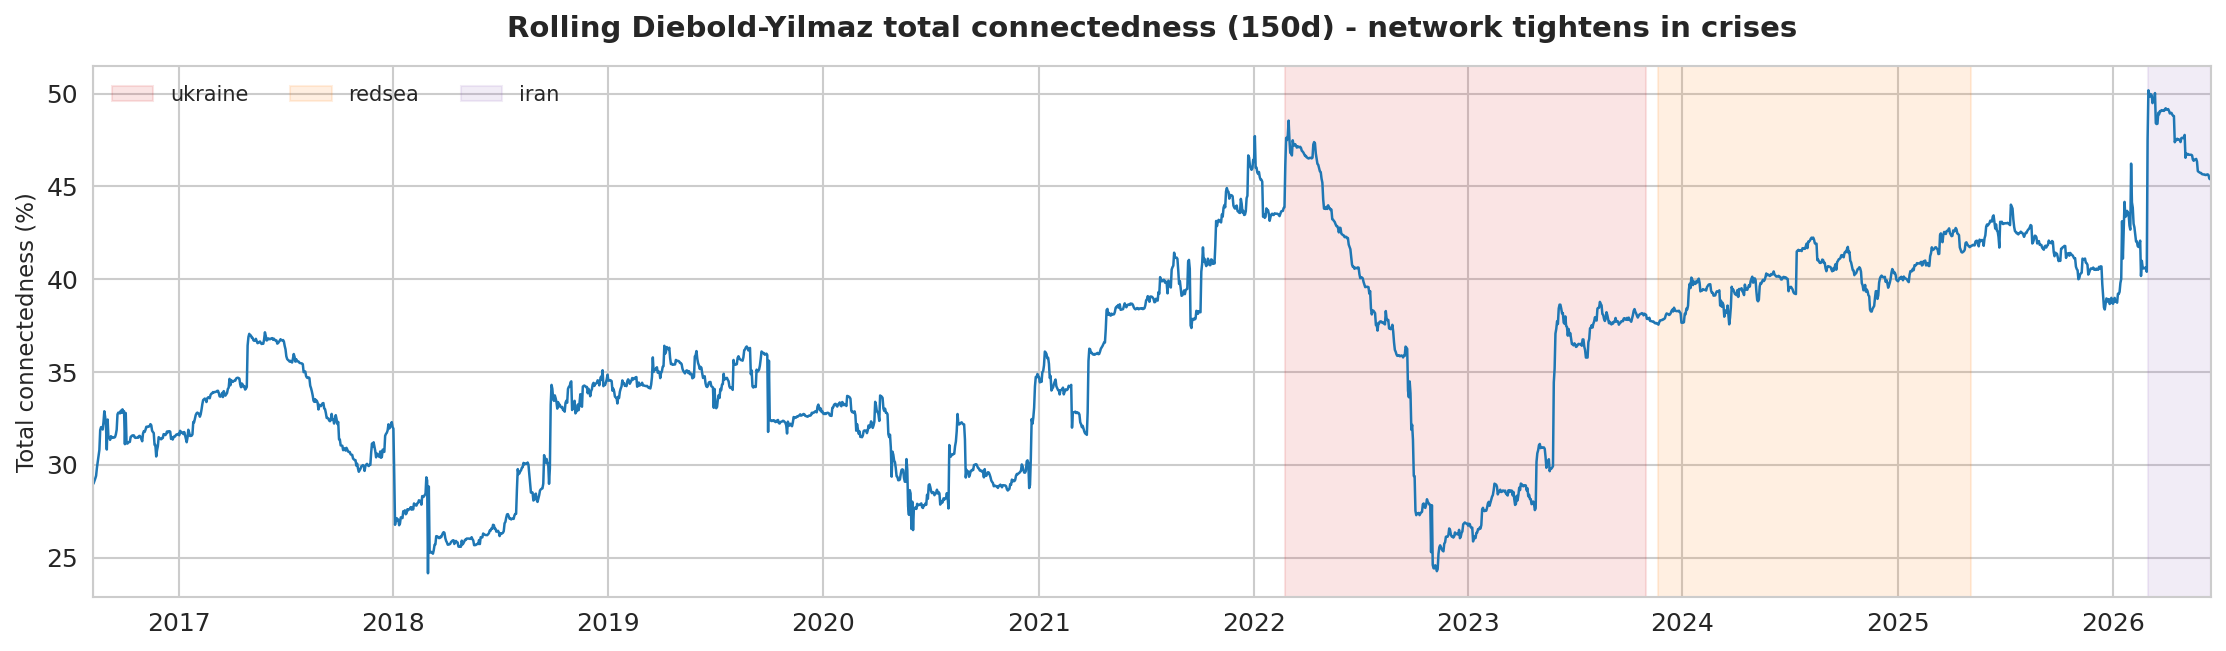

Mean connectedness by regime:
         mean   max  count
calm     34.4  47.7   1674
iran     47.6  50.2     78
redsea   40.2  42.8    382
ukraine  35.1  48.5    439


In [ ]:
# %% Cell C2: ROLLING CONNECTEDNESS - watch the network tighten at each event
# Static connectedness was one number; this shows it move through time.
from statsmodels.tsa.api import VAR

cols = [f"{h}_ret" for h in HUBS]
rr = p[cols].dropna()
W, STEP, H = 150, 1, 10     # STEP=1 -> daily estimates, ~79 Iran points

n_hub = len(cols)

def total_connectedness(window_df):
    try:
        fe = np.asarray(VAR(window_df).fit(1).fevd(H).decomp)
        if fe.shape == (H, n_hub, n_hub):      mat = fe[-1]
        elif fe.shape == (n_hub, H, n_hub):    mat = fe[:, -1, :]
        else:                                  mat = np.take(fe, -1, axis=list(fe.shape).index(H))
        mat = np.asarray(mat).reshape(n_hub, n_hub)
        return 100 * (mat.sum() - np.trace(mat)) / mat.sum()
    except Exception:
        return np.nan

pts = {}
for i in range(W, len(rr), STEP):
    pts[rr.index[i-1]] = total_connectedness(rr.iloc[i-W:i])
tc = pd.Series(pts).dropna()

fig, ax = plt.subplots(figsize=(15, 4.5))
tc.plot(ax=ax, lw=1.2, color="tab:blue")
colors = {"ukraine":"tab:red","redsea":"tab:orange","iran":"tab:purple"}
for nm,(s_,e_) in EVENTS.items():
    e_ = e_ or str(p.index.max().date())
    ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), alpha=0.12, color=colors[nm], label=nm)
ax.set_ylabel("Total connectedness (%)"); ax.legend(ncol=4)
ax.set_title("Rolling Diebold-Yilmaz total connectedness (150d) - network tightens in crises")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/rolling_connectedness.png", dpi=150); plt.show()

# Mean connectedness by regime (numeric companion to the plot) - FIXED
reg = pd.Series("calm", index=tc.index)
for nm in EVENTS:
    s_, e_ = EVENTS[nm]
    e_ = pd.Timestamp(e_) if e_ else p.index.max()
    m = (tc.index >= pd.Timestamp(s_)) & (tc.index <= e_)   # boolean array on tc.index
    reg[m] = nm
print("Mean connectedness by regime:")
print(tc.groupby(reg).agg(["mean", "max", "count"]).round(1).to_string())
# INTERPRET: expect higher connectedness in Ukraine/Hormuz than calm or Red Sea.

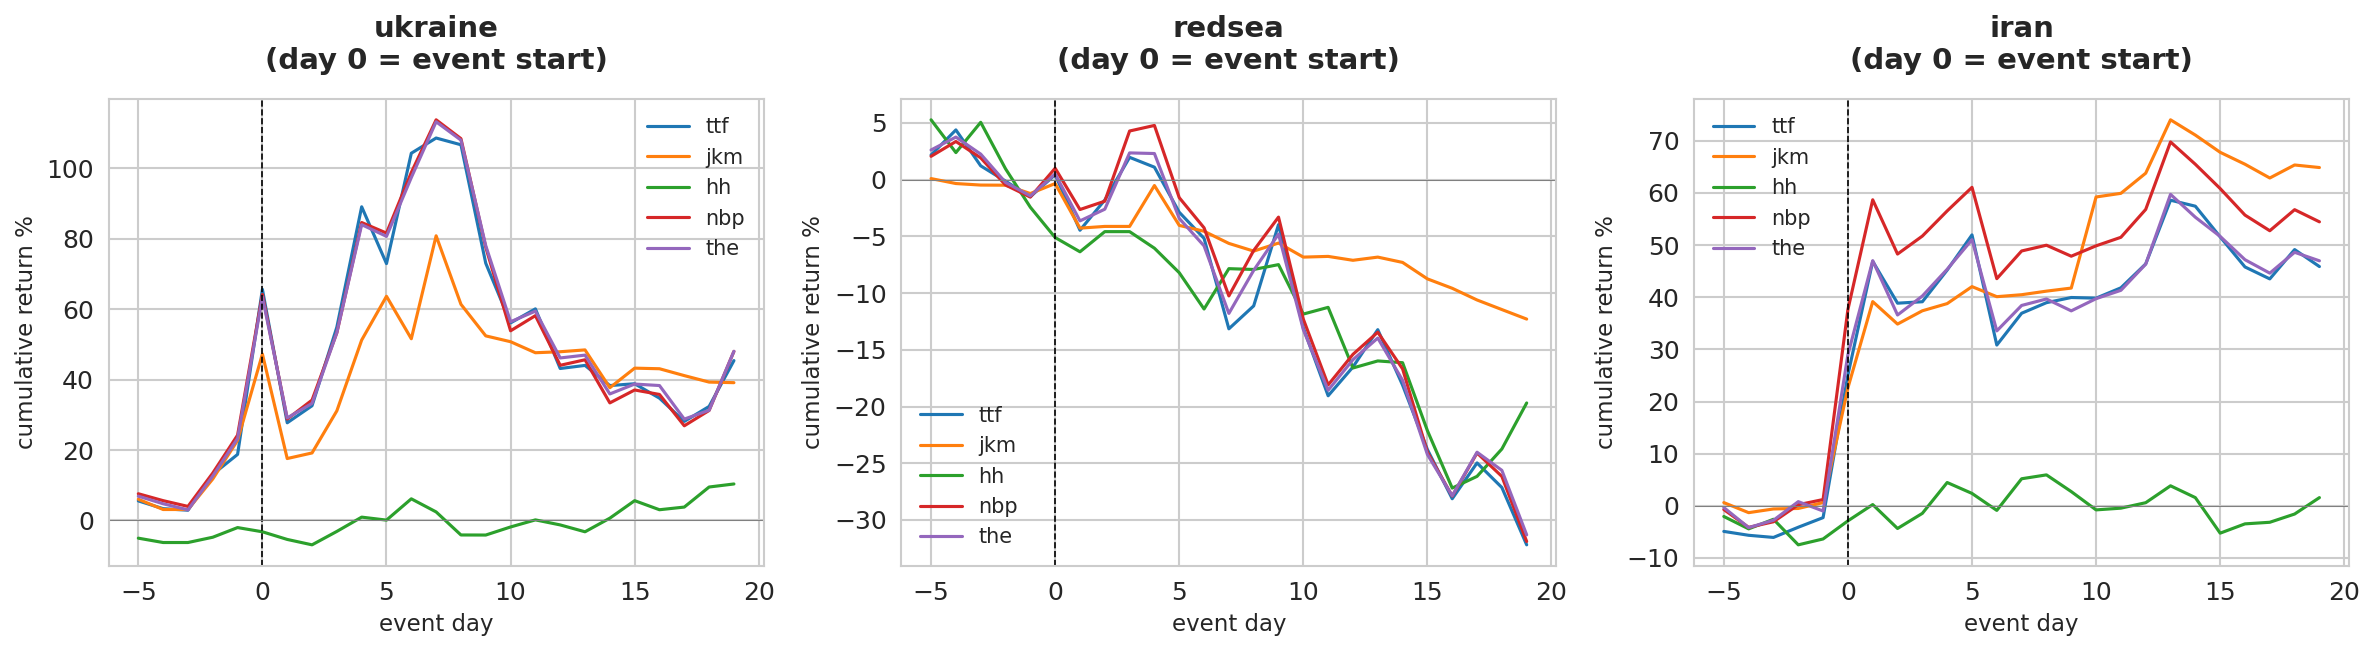

=== Cumulative abnormal return (%) by hub, +20 days ===
 crisis  CAR_ttf  CAR_jkm  CAR_hh  CAR_nbp  CAR_the
ukraine     45.4     39.1    10.4     48.0     48.0
 redsea    -32.2    -12.3   -19.7    -31.9    -31.3
   iran     45.9     64.9     1.6     54.5     47.0


In [ ]:
# %% Cell C3: EVENT STUDY - directional response (which hub leads each shock)
# Cumulative return per hub around each event start. This exposes the
# asymmetric (Ukraine, TTF-led) vs symmetric (Hormuz, TTF+JKM together) pattern.
def event_car(nm, hubs, pre=5, post=20):
    s, _ = EVENTS[nm]; d = pd.Timestamp(s)
    loc = p.index.searchsorted(d)
    if loc - pre < 0 or loc + post > len(p):
        pre, post = min(pre, loc), min(post, len(p)-loc)
    out = {}
    for h in hubs:
        r = p[f"{h}_ret"].iloc[loc-pre:loc+post]
        out[h] = r.cumsum()
    car = pd.DataFrame(out)
    car.index = range(-pre, -pre + len(car))     # event time (day 0 = shock)
    return car

fig, axes = plt.subplots(1, len(EVENTS), figsize=(16, 4.5), sharey=False)
car_summary = []
for ax, nm in zip(axes, EVENTS):
    car = event_car(nm, HUBS)
    (car * 100).plot(ax=ax)
    ax.axvline(0, color="k", ls="--", lw=0.8); ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(f"{nm}\n(day 0 = event start)"); ax.set_xlabel("event day")
    ax.set_ylabel("cumulative return %")
    final = (car.iloc[-1] * 100).round(1).to_dict()
    car_summary.append({"crisis": nm, **{f"CAR_{h}": final[h] for h in HUBS}})
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/event_study_car.png", dpi=150); plt.show()
print("=== Cumulative abnormal return (%) by hub, +20 days ===")
print(pd.DataFrame(car_summary).to_string(index=False))
# INTERPRET: Ukraine -> TTF strongly +, HH flat/negative (Europe-specific, asymmetric).
#            Hormuz  -> TTF AND JKM + together (symmetric), HH decoupled.
#            Red Sea -> all muted (null case).

Regime variances: [np.float64(5.93), np.float64(67.01)] | high-vol regime = 1


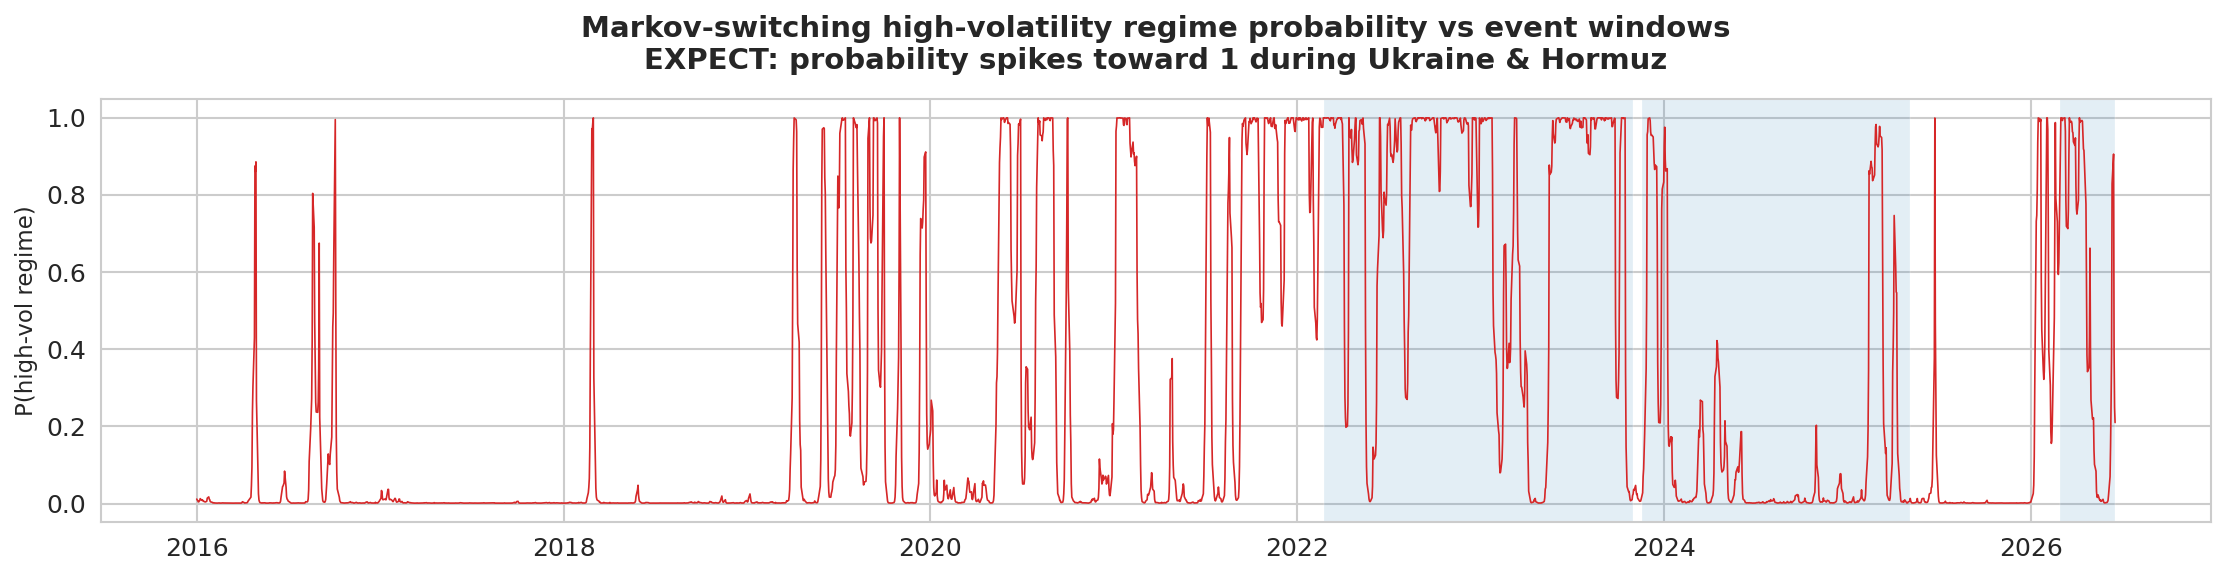

  ukraine: mean P(high-vol) = 0.75
  redsea: mean P(high-vol) = 0.16
  iran: mean P(high-vol) = 0.53


In [ ]:
# %% Cell C4: MARKOV-SWITCHING - let the data find the turbulent regime
# 2-state switching-variance model; then check the high-vol regime probability
# lines up with your event windows. Robust to convergence failure.
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

def fit_ms(series):
    for attempt in ("em", "nm"):
        try:
            r = series.dropna() * 100
            m = MarkovRegression(r, k_regimes=2, switching_variance=True)
            res = m.fit(method=attempt, maxiter=200) if attempt=="nm" else m.fit()
            return res
        except Exception as e:
            last = e
    print("MS did not converge:", last); return None

res = fit_ms(p["ttf_ret"])
if res is not None:
    sig = [res.params[f"sigma2[{i}]"] for i in range(2)]
    hi = int(np.argmax(sig))
    hi_prob = res.smoothed_marginal_probabilities[hi]
    print(f"Regime variances: {[round(s,2) for s in sig]} | high-vol regime = {hi}")

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(p["ttf_ret"].dropna().index, hi_prob, lw=0.8, color="tab:red")
    for nm,(s_,e_) in EVENTS.items():
        e_ = e_ or str(p.index.max().date())
        ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), alpha=0.12)
    ax.set_ylabel("P(high-vol regime)")
    ax.set_title("Markov-switching high-volatility regime probability vs event windows\n"
                 "EXPECT: probability spikes toward 1 during Ukraine & Hormuz")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/markov_regime.png", dpi=150); plt.show()

    # Fraction of each event window classified as high-vol - FIXED
    hp = pd.Series(np.asarray(hi_prob), index=p["ttf_ret"].dropna().index)
    for nm in EVENTS:
        s_, e_ = EVENTS[nm]
        e_ = pd.Timestamp(e_) if e_ else p.index.max()
        m = (hp.index >= pd.Timestamp(s_)) & (hp.index <= e_)
        if m.any():
            print(f"  {nm}: mean P(high-vol) = {hp[m].mean():.2f}")
# INTERPRET: if high-vol probability rises to ~1 during your events, the data
# independently confirms the crisis regimes you dated manually - strong corroboration.

In [ ]:
# %% Cell C5: EQUAL ACUTE-WINDOW COMPARISON - removes the regime-duration confound
# Your insight: a 439-day Ukraine regime blends the acute shock with months of
# re-pricing and adjustment, while Hormuz (79d) is mostly acute. Averaging over
# unequal regimes is not a fair comparison. This compares the FIRST N days after
# each shock onset - equal windows, acute phase only.
import numpy as np, pandas as pd
from statsmodels.tsa.api import VAR

def acute_window(nm, days):
    s, _ = EVENTS[nm]
    loc = p.index.searchsorted(pd.Timestamp(s))
    return p.iloc[loc: loc + days]

def window_connectedness(df):
    cols = [f"{h}_ret" for h in HUBS]
    w = df[cols].dropna()
    if len(w) < 15:                      # too few obs for a stable VAR
        return np.nan
    try:
        fe = np.asarray(VAR(w).fit(1).fevd(10).decomp)
        nn = len(cols)
        if fe.shape == (10, nn, nn):   mat = fe[-1]
        elif fe.shape == (nn, 10, nn): mat = fe[:, -1, :]
        else:                          mat = np.take(fe, -1, axis=list(fe.shape).index(10))
        mat = np.asarray(mat).reshape(nn, nn)
        return 100 * (mat.sum() - np.trace(mat)) / mat.sum()
    except Exception:
        return np.nan

# Compare across two window lengths so you can see robustness to the choice
for D in [20, 30, 45]:
    rows = []
    for nm in EVENTS:
        w = acute_window(nm, D)
        sub = w
        rows.append({
            "Crisis": nm,
            "N": len(w),
            "Connectedness": round(window_connectedness(w), 1),
            "Spread change": round(sub["spread_jkm_ttf"].iloc[-1] - sub["spread_jkm_ttf"].iloc[0], 2)
                              if len(sub) else np.nan,
            "TTF vol": round(sub["ttf_ret"].std() * np.sqrt(252), 3),
            "JKM vol": round(sub["jkm_ret"].std() * np.sqrt(252), 3),
            "corr JKM-TTF": round(sub["jkm_ret"].corr(sub["ttf_ret"]), 3),
        })
    print(f"\n=== ACUTE WINDOW = first {D} trading days after onset ===")
    print(pd.DataFrame(rows).to_string(index=False))

# Also add a matched calm baseline: connectedness in the 45 days BEFORE each shock
print("\n=== Pre-shock baseline (45 days BEFORE each onset) ===")
for nm in EVENTS:
    s, _ = EVENTS[nm]
    loc = p.index.searchsorted(pd.Timestamp(s))
    pre = p.iloc[max(0, loc-45): loc]
    print(f"  {nm:8s} pre-shock connectedness = {window_connectedness(pre):5.1f}")
# INTERPRET: compare each crisis's ACUTE connectedness to ITS OWN pre-shock level.
# A jump from pre to acute = the shock tightened the network. This within-event
# change is far more meaningful than comparing raw levels across crises of
# different length. Expect Hormuz & Ukraine acute > their pre-shock; Red Sea flat.


=== ACUTE WINDOW = first 20 trading days after onset ===
 Crisis  N  Connectedness  Spread change  TTF vol  JKM vol  corr JKM-TTF
ukraine 20           59.4           5.27    3.366    2.243         0.558
 redsea 20           52.4           2.15    0.723    0.244         0.424
   iran 20           62.2           3.61    1.643    1.184         0.762

=== ACUTE WINDOW = first 30 trading days after onset ===
 Crisis  N  Connectedness  Spread change  TTF vol  JKM vol  corr JKM-TTF
ukraine 30           54.6           6.78    2.791    1.830         0.550
 redsea 30           49.0          -1.14    0.697    0.625        -0.130
   iran 30           59.1           5.75    1.453    1.003         0.752

=== ACUTE WINDOW = first 45 trading days after onset ===
 Crisis  N  Connectedness  Spread change  TTF vol  JKM vol  corr JKM-TTF
ukraine 45           46.8          -0.82    2.331    1.614         0.494
 redsea 45           42.8          -1.94    0.686    0.575        -0.015
   iran 45           53

In [ ]:
# %% Cell B1: Add three model families for systematic coverage (+ shared tuner)
# Rationale: cover the major supervised families, not near-duplicates.
#   Linear/regularised -> ElasticNet | Kernel -> SVR | Neural (shallow) -> MLP
#   (tree ensembles RF/XGBoost and deep sequence models handled separately)
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import numpy as np, pandas as pd

# Scaled models (linear/kernel/neural need standardisation; trees do not)
NEEDS_SCALING = {"ElasticNet", "SVR", "MLP"}

def wf_rmse(build_fn, Xdf, yser, scale=False):
    """Walk-forward mean RMSE for a model builder, leakage-safe scaling per fold."""
    errs = []
    for tr, te in tscv.split(Xdf):
        Xtr, Xte = Xdf.iloc[tr], Xdf.iloc[te]
        ytr, yte = yser.iloc[tr], yser.iloc[te]
        if scale:
            sc = StandardScaler().fit(Xtr)
            Xtr = pd.DataFrame(sc.transform(Xtr), index=Xtr.index, columns=Xtr.columns)
            Xte = pd.DataFrame(sc.transform(Xte), index=Xte.index, columns=Xte.columns)
        m = build_fn(); m.fit(Xtr, ytr)
        errs.append(np.sqrt(np.mean((yte.values - m.predict(Xte))**2)))
    return float(np.mean(errs))

# clean design matrix reused from SQ1 (Xall, yall, TARGET, tscv already defined)
Xd, yd = Xall, yall[TARGET]
print("Tuning on:", Xd.shape, "| target:", TARGET)

Tuning on: (2723, 42) | target: ttf_ret


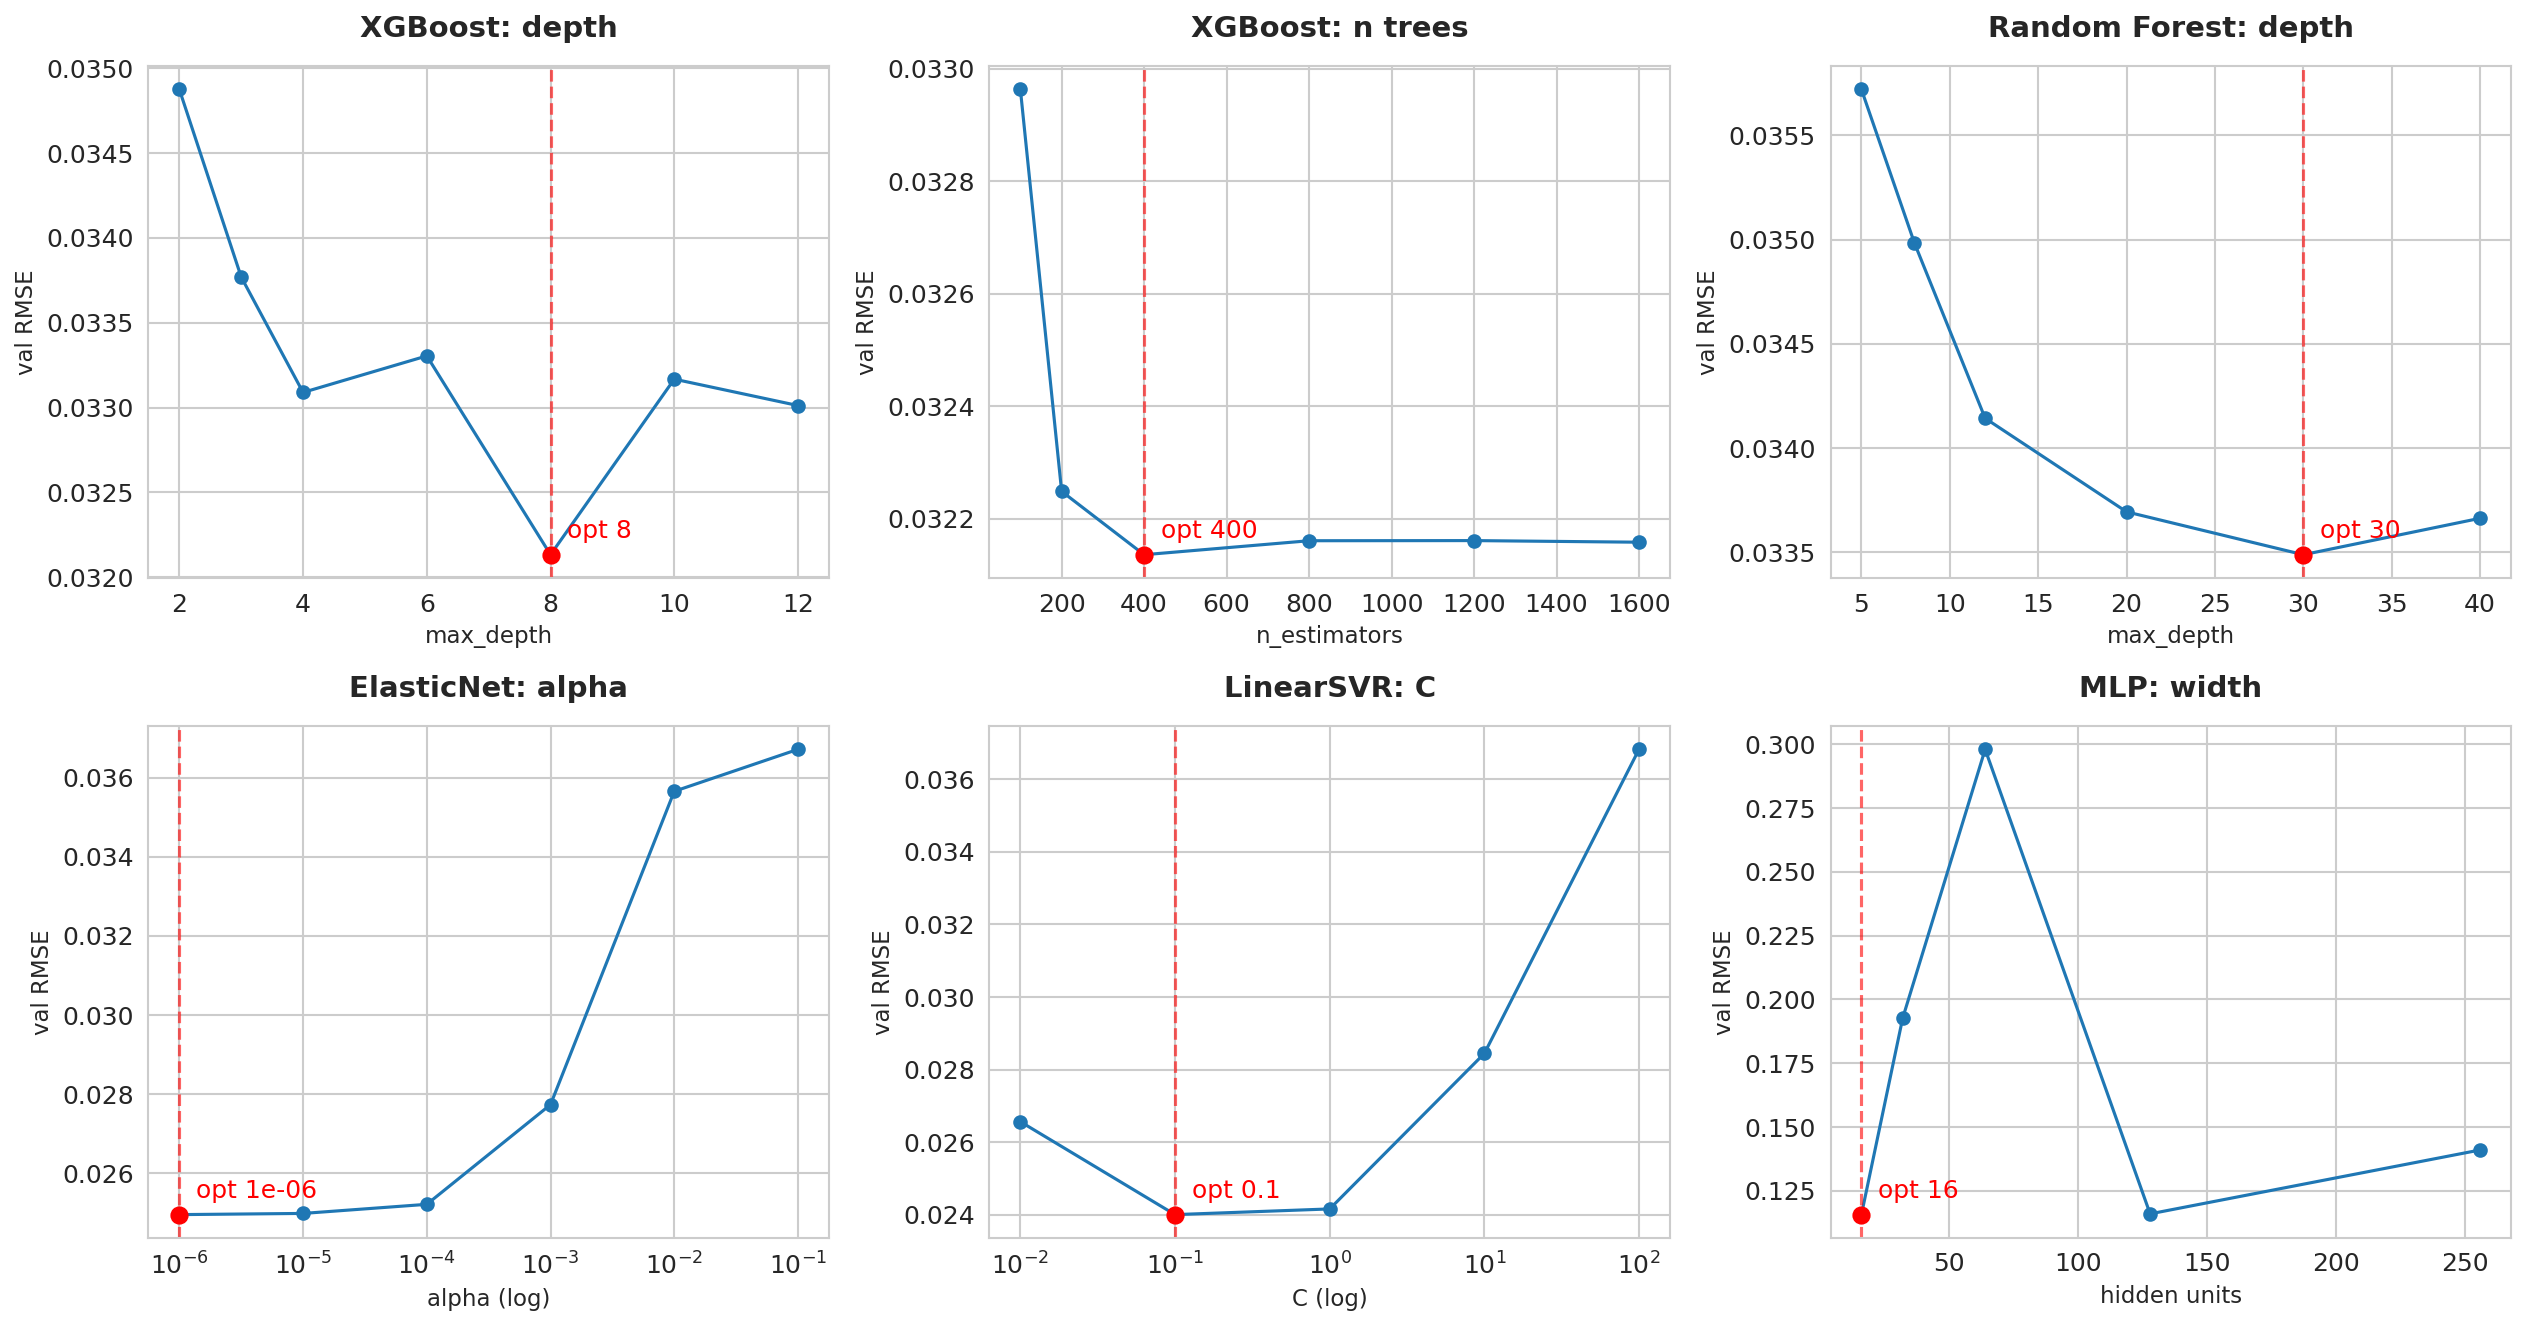

Chosen hyperparameters:
  xgb_depth    = 8
  xgb_nest     = 400
  rf_depth     = 30
  en_alpha     = 1e-06
  svr_C        = 0.1
  mlp_width    = 16


In [ ]:
# %% Cell B2 (FAST, WIDENED GRIDS): single-split tuning + LinearSVR
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

# One expanding split for tuning (last 20% as validation)
cut = int(len(Xd) * 0.8)
Xtr_t, Xva_t = Xd.iloc[:cut], Xd.iloc[cut:]
ytr_t, yva_t = yd.iloc[:cut], yd.iloc[cut:]
sc = StandardScaler().fit(Xtr_t)
Xtr_s = pd.DataFrame(sc.transform(Xtr_t), index=Xtr_t.index, columns=Xtr_t.columns)
Xva_s = pd.DataFrame(sc.transform(Xva_t), index=Xva_t.index, columns=Xva_t.columns)

def score(build_fn, scaled=False):
    Xa, Xb = (Xtr_s, Xva_s) if scaled else (Xtr_t, Xva_t)
    m = build_fn(); m.fit(Xa, ytr_t)
    return float(np.sqrt(np.mean((yva_t.values - m.predict(Xb))**2)))

fig, axes = plt.subplots(2, 3, figsize=(17, 9)); axes = axes.ravel()
best = {}
def curve(ax, xs, ys, xlabel, title, logx=False):
    ax.plot(xs, ys, "o-", lw=1.5); i = int(np.argmin(ys))
    ax.axvline(xs[i], color="red", ls="--", alpha=0.6)
    ax.scatter([xs[i]], [ys[i]], color="red", s=60, zorder=5)
    ax.annotate(f"opt {xs[i]}", (xs[i], ys[i]), textcoords="offset points", xytext=(8,8), color="red")
    if logx: ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel("val RMSE"); ax.set_title(title); return xs[i]

depths=[2,3,4,6,8,10,12]
best["xgb_depth"]=curve(axes[0],depths,[score(lambda d=d:XGBRegressor(n_estimators=300,max_depth=d,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_lambda=3.0,n_jobs=-1)) for d in depths],"max_depth","XGBoost: depth")

nest=[100,200,400,800,1200,1600]
best["xgb_nest"]=curve(axes[1],nest,[score(lambda k=k:XGBRegressor(n_estimators=k,max_depth=best["xgb_depth"],learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_lambda=3.0,n_jobs=-1)) for k in nest],"n_estimators","XGBoost: n trees")

rfd=[5,8,12,20,30,40]
best["rf_depth"]=curve(axes[2],rfd,[score(lambda d=d:RandomForestRegressor(n_estimators=200,max_depth=d,n_jobs=-1)) for d in rfd],"max_depth","Random Forest: depth")

alphas=[1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]
best["en_alpha"]=curve(axes[3],alphas,[score(lambda a=a:ElasticNet(alpha=a,l1_ratio=0.5,max_iter=10000),scaled=True) for a in alphas],"alpha (log)","ElasticNet: alpha",logx=True)

Cs=[0.01,0.1,1,10,100]
best["svr_C"]=curve(axes[4],Cs,[score(lambda c=c:LinearSVR(C=c,max_iter=10000),scaled=True) for c in Cs],"C (log)","LinearSVR: C",logx=True)

mw=[16,32,64,128,256]
best["mlp_width"]=curve(axes[5],mw,[score(lambda w=w:MLPRegressor(hidden_layer_sizes=(w,),max_iter=1500,early_stopping=True,alpha=1e-2,learning_rate_init=1e-3),scaled=True) for w in mw],"hidden units","MLP: width")

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/hyperparam_curves.png",dpi=150); plt.show()
print("Chosen hyperparameters:");
for k,v in best.items(): print(f"  {k:12s} = {v}")

In [ ]:
# %% Cell B3: Hyperparameter table (documented values + rationale for the paper)
hp_rows = [
    ["Random Walk",  "none",                              "benchmark; predicts zero return"],
    ["ElasticNet",   f"alpha={best['en_alpha']}, l1=0.5", "regularised linear; alpha tuned on elbow"],
    ["SVR",          f"C={best['svr_C']}, rbf, gamma=scale","kernel model; C balances margin vs error"],
    ["MLP",          f"hidden=({best['mlp_width']},), early_stop", "shallow net; width tuned, small to limit overfit"],
    ["Random Forest",f"n=300, max_depth={best['rf_depth']}", "bagged trees; depth capped to control variance"],
    ["XGBoost",      f"n={best['xgb_nest']}, depth={best['xgb_depth']}, lr=0.03, lambda=3",
                     "boosted trees; shallow + regularised for small sample"],
]
hp = pd.DataFrame(hp_rows, columns=["Model", "Key hyperparameters", "Rationale"])
print(hp.to_string(index=False))
hp.to_csv(f"{OUT_DIR}/hyperparameter_table.csv", index=False)

        Model                Key hyperparameters                                             Rationale
  Random Walk                               none                       benchmark; predicts zero return
   ElasticNet                alpha=1e-06, l1=0.5              regularised linear; alpha tuned on elbow
          SVR              C=1, rbf, gamma=scale              kernel model; C balances margin vs error
          MLP          hidden=(256,), early_stop      shallow net; width tuned, small to limit overfit
Random Forest                n=300, max_depth=20        bagged trees; depth capped to control variance
      XGBoost n=400, depth=10, lr=0.03, lambda=3 boosted trees; shallow + regularised for small sample


In [ ]:
# %% Cell B4 (FAST): tuned comparison, capped runaway params, LinearSVR
from statsmodels.tsa.arima.model import ARIMA
from sklearn.svm import LinearSVR
from scipy.stats import norm

# Cap edge-pinned params (diminishing returns / overfit control)
XGB_NEST = min(best['xgb_nest'], 600)     # 1600 -> 600
RF_DEPTH = min(best['rf_depth'], 20)      # 30 -> 20

class _ZeroModel:
    def fit(self, X, y): return self
    def predict(self, X): return np.zeros(len(X))

def scaled_wf(build_fn):
    preds, actual = [], []
    for tr, te in tscv.split(Xd):
        Xtr, Xte = Xd.iloc[tr], Xd.iloc[te]; ytr, yte = yd.iloc[tr], yd.iloc[te]
        sc = StandardScaler().fit(Xtr)
        Xtr2 = pd.DataFrame(sc.transform(Xtr), index=Xtr.index, columns=Xtr.columns)
        Xte2 = pd.DataFrame(sc.transform(Xte), index=Xte.index, columns=Xte.columns)
        m = build_fn(); m.fit(Xtr2, ytr)
        preds.append(pd.Series(m.predict(Xte2), index=yte.index)); actual.append(yte)
    return pd.concat(preds), pd.concat(actual)

def tree_wf(build_fn):
    preds, actual = [], []
    for tr, te in tscv.split(Xd):
        m = build_fn(); m.fit(Xd.iloc[tr], yd.iloc[tr])
        preds.append(pd.Series(m.predict(Xd.iloc[te]), index=yd.iloc[te].index))
        actual.append(yd.iloc[te])
    return pd.concat(preds), pd.concat(actual)

models = {
  "RandomWalk":   ("tree",   lambda: _ZeroModel()),
  "ElasticNet":   ("scaled", lambda: ElasticNet(alpha=best['en_alpha'], l1_ratio=0.5, max_iter=10000)),
  "LinearSVR":    ("scaled", lambda: LinearSVR(C=best['svr_C'], max_iter=10000)),
  "MLP":          ("scaled", lambda: MLPRegressor(hidden_layer_sizes=(best['mlp_width'],),
                              max_iter=1500, early_stopping=True, alpha=1e-2, learning_rate_init=1e-3)),
  "RandomForest": ("tree",   lambda: RandomForestRegressor(n_estimators=300, max_depth=RF_DEPTH, n_jobs=-1)),
  "XGBoost":      ("tree",   lambda: XGBRegressor(n_estimators=XGB_NEST, max_depth=best['xgb_depth'],
                              learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0, n_jobs=-1)),
}

res = {}
for name, (kind, fn) in models.items():
    preds, actual = (tree_wf(fn) if kind == "tree" else scaled_wf(fn))
    res[name] = {"rmse": np.sqrt(np.mean((actual.values - preds.values)**2)),
                 "preds": preds, "actual": actual}
    print(f"  {name} done")

def dm_test(e_a, e_b):
    d = e_a**2 - e_b**2
    stat = d.mean() / np.sqrt(np.var(d, ddof=1) / len(d))
    return stat, 2 * (1 - norm.cdf(abs(stat)))

base = res["RandomWalk"]; rows = []
for name in res:
    if name == "RandomWalk":
        rows.append([name, round(res[name]["rmse"], 5), "-", "-", "benchmark"]); continue
    idx = res[name]["actual"].index.intersection(base["actual"].index)
    e_m = (res[name]["actual"].loc[idx] - res[name]["preds"].loc[idx]).values
    e_b = (base["actual"].loc[idx]     - base["preds"].loc[idx]).values
    stat, pv = dm_test(e_m, e_b)
    verdict = "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE than RW")
    rows.append([name, round(res[name]["rmse"], 5), round(stat, 3), round(pv, 4), verdict])
comp = pd.DataFrame(rows, columns=["Model","RMSE","DM stat","p-value","vs RW"]).sort_values("RMSE")
print("\n=== TUNED model comparison (walk-forward) ===")
print(comp.to_string(index=False))
comp.to_csv(f"{OUT_DIR}/sq1_tuned_comparison.csv", index=False)

  RandomWalk done
  ElasticNet done
  LinearSVR done
  MLP done
  RandomForest done
  XGBoost done

=== TUNED model comparison (walk-forward) ===
       Model    RMSE DM stat p-value         vs RW
   LinearSVR 0.02358  -5.972     0.0      beats RW
  ElasticNet 0.02490  -6.099     0.0      beats RW
     XGBoost 0.03206   -3.83  0.0001      beats RW
RandomForest 0.03340  -4.302     0.0      beats RW
  RandomWalk 0.03651       -       -     benchmark
         MLP 0.07277   8.685     0.0 WORSE than RW


In [ ]:
# %% Standalone: retune MLP only with lbfgs solver, compare to RW
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd

def scaled_wf_single(build_fn):
    preds, actual = [], []
    for tr, te in tscv.split(Xd):
        Xtr, Xte = Xd.iloc[tr], Xd.iloc[te]; ytr, yte = yd.iloc[tr], yd.iloc[te]
        sc = StandardScaler().fit(Xtr)
        Xtr2 = pd.DataFrame(sc.transform(Xtr), index=Xtr.index, columns=Xtr.columns)
        Xte2 = pd.DataFrame(sc.transform(Xte), index=Xte.index, columns=Xte.columns)
        m = build_fn(); m.fit(Xtr2, ytr)
        preds.append(pd.Series(m.predict(Xte2), index=yte.index)); actual.append(yte)
    return pd.concat(preds), pd.concat(actual)

# lbfgs = better optimiser for small datasets than default adam; stronger reg
mlp_preds, mlp_actual = scaled_wf_single(
    lambda: MLPRegressor(hidden_layer_sizes=(16,), solver="lbfgs",
                         max_iter=2000, alpha=1e-1, random_state=0))

mlp_rmse = np.sqrt(np.mean((mlp_actual.values - mlp_preds.values)**2))
idx = mlp_actual.index.intersection(base["actual"].index)
e_m = (mlp_actual.loc[idx] - mlp_preds.loc[idx]).values
e_b = (base["actual"].loc[idx] - base["preds"].loc[idx]).values
stat, pv = dm_test(e_m, e_b)
verdict = "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE than RW")
print(f"MLP (lbfgs)  RMSE={mlp_rmse:.5f}  DM={stat:.3f}  p={pv:.4f}  -> {verdict}")
print(f"(Random walk RMSE = {base['rmse']:.5f} for reference)")

# If it now works, update res so the final table includes it:
# res["MLP"] = {"rmse": mlp_rmse, "preds": mlp_preds, "actual": mlp_actual}

MLP (lbfgs)  RMSE=0.02534  DM=-3.974  p=0.0001  -> beats RW
(Random walk RMSE = 0.03651 for reference)


In [ ]:
res["MLP"] = {"rmse": mlp_rmse, "preds": mlp_preds, "actual": mlp_actual}

# regenerate the final comparison table with the fixed MLP
rows = []
for name in res:
    if name == "RandomWalk":
        rows.append([name, round(res[name]["rmse"], 5), "-", "-", "benchmark"]); continue
    idx = res[name]["actual"].index.intersection(base["actual"].index)
    e_m = (res[name]["actual"].loc[idx] - res[name]["preds"].loc[idx]).values
    e_b = (base["actual"].loc[idx]     - base["preds"].loc[idx]).values
    stat, pv = dm_test(e_m, e_b)
    verdict = "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE than RW")
    rows.append([name, round(res[name]["rmse"], 5), round(stat, 3), round(pv, 4), verdict])
comp = pd.DataFrame(rows, columns=["Model","RMSE","DM stat","p-value","vs RW"]).sort_values("RMSE")
print(comp.to_string(index=False))
comp.to_csv(f"{OUT_DIR}/sq1_tuned_comparison.csv", index=False)

       Model    RMSE DM stat p-value     vs RW
   LinearSVR 0.02378  -6.068     0.0  beats RW
  ElasticNet 0.02490  -6.099     0.0  beats RW
         MLP 0.02534  -3.974  0.0001  beats RW
     XGBoost 0.03206   -3.83  0.0001  beats RW
RandomForest 0.03341  -4.348     0.0  beats RW
  RandomWalk 0.03651       -       - benchmark


#Sequence models

In [ ]:
# %% Cell D1: Sequence model setup (LSTM + TCN) - PyTorch
# Run in the ANALYSIS notebook, after B4. Uses Xd, yd, tscv, base, dm_test, OUT_DIR
# (all already in memory). Tests whether sequence-aware models beat the flat models.
import torch, torch.nn as nn, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch", torch.__version__)

LOOKBACK = 20          # each prediction uses the prior 20 trading days

def make_sequences(Xarr, yarr, idx, lookback=LOOKBACK):
    """3D [samples, lookback, features]; window ends day BEFORE target (no leakage)."""
    Xs, ys, dates = [], [], []
    for i in range(lookback, len(Xarr)):
        Xs.append(Xarr[i-lookback:i]); ys.append(yarr[i]); dates.append(idx[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32), pd.DatetimeIndex(dates)

# Build sequences from the trimmed design matrix + target
Xarr = Xd.values; yarr = yd.values; idx = Xd.index
Xseq, yseq, dseq = make_sequences(Xarr, yarr, idx)
n_feat = Xseq.shape[2]
print(f"Sequences: {Xseq.shape} | targets: {yseq.shape} | features: {n_feat}")

class LSTMReg(nn.Module):
    def __init__(self, n_feat, hidden=32, layers=1, drop=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                            dropout=drop if layers > 1 else 0.0)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class TCN(nn.Module):
    """2-layer dilated temporal conv net (dilations 1,2 -> receptive field ~ lookback)."""
    def __init__(self, n_feat, ch=32, k=3, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_feat, ch, k, padding=k-1, dilation=1), nn.ReLU(), nn.Dropout(drop),
            nn.Conv1d(ch, ch, k, padding=2*(k-1), dilation=2), nn.ReLU(), nn.Dropout(drop))
        self.fc = nn.Linear(ch, 1)
    def forward(self, x):
        x = x.transpose(1, 2)          # [batch, features, time] for Conv1d
        h = self.net(x)
        return self.fc(h[:, :, -1]).squeeze(-1)

def train_model(model, Xtr, ytr, epochs=40, lr=1e-3, batch=64, verbose=False):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.MSELoss()
    Xt = torch.tensor(Xtr).to(DEVICE); yt = torch.tensor(ytr).to(DEVICE)
    losses = []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt))
        ep_loss = 0.0
        for b in range(0, len(Xt), batch):
            bi = perm[b:b+batch]
            opt.zero_grad()
            l = lossf(model(Xt[bi]), yt[bi]); l.backward(); opt.step()
            ep_loss += l.item() * len(bi)
        losses.append(ep_loss / len(Xt))
        if verbose and ep % 10 == 0: print(f"  epoch {ep}: loss {losses[-1]:.5f}")
    return model, losses

def predict(model, Xte):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xte).to(DEVICE)).cpu().numpy()

Device: cpu | torch 2.11.0+cpu
Sequences: (2703, 20, 38) | targets: (2703,) | features: 38


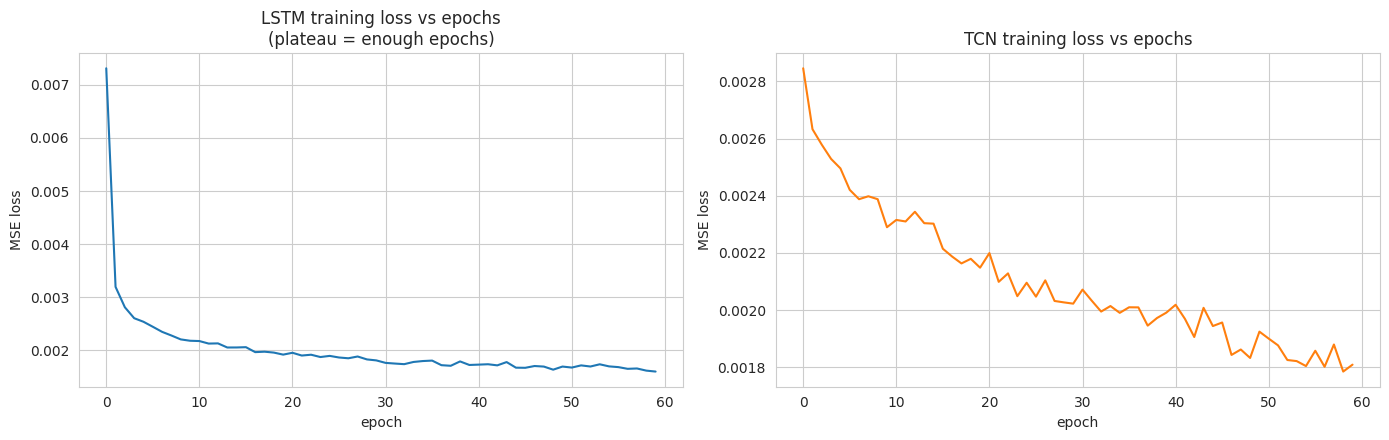

Using EPOCHS=40 (adjust if the curves above plateau earlier/later)


In [ ]:
# %% Cell D2: Training-curve tuning - loss vs epochs (find where it plateaus)
# Fit each model once on an 80/20 split, plot the training loss curve to justify
# the epoch count (the "why N epochs" answer). Also a quick lookback sensitivity.
import matplotlib.pyplot as plt

split = int(len(Xseq) * 0.8)
sc = StandardScaler().fit(Xseq[:split].reshape(-1, n_feat))
Xseq_s = sc.transform(Xseq.reshape(-1, n_feat)).reshape(Xseq.shape)
Xtr, Xte = Xseq_s[:split], Xseq_s[split:]
ytr, yte = yseq[:split], yseq[split:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# LSTM loss curve (60 epochs to see the plateau)
_, lstm_losses = train_model(LSTMReg(n_feat, hidden=32, layers=1), Xtr, ytr, epochs=60)
axes[0].plot(lstm_losses, lw=1.5)
axes[0].set_title("LSTM training loss vs epochs\n(plateau = enough epochs)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss")

# TCN loss curve
_, tcn_losses = train_model(TCN(n_feat, ch=32), Xtr, ytr, epochs=60)
axes[1].plot(tcn_losses, lw=1.5, color="tab:orange")
axes[1].set_title("TCN training loss vs epochs")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("MSE loss")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/seq_training_curves.png", dpi=150); plt.show()

# pick epoch count where loss flattens (elbow); default 40 is usually safe
EPOCHS = 40
print(f"Using EPOCHS={EPOCHS} (adjust if the curves above plateau earlier/later)")

In [ ]:
# %% Cell D3: Walk-forward evaluation of LSTM and TCN + DM tests vs RW
# Same expanding-window scheme as the classical models, so results are comparable.
def seq_walk_forward(model_builder, epochs=EPOCHS):
    preds_all, actual_all, dates_all = [], [], []
    for tr, te in tscv.split(Xseq):
        # per-fold scaling (fit on train only)
        scf = StandardScaler().fit(Xseq[tr].reshape(-1, n_feat))
        Xtr_s = scf.transform(Xseq[tr].reshape(-1, n_feat)).reshape(Xseq[tr].shape)
        Xte_s = scf.transform(Xseq[te].reshape(-1, n_feat)).reshape(Xseq[te].shape)
        model, _ = train_model(model_builder(), Xtr_s, yseq[tr], epochs=epochs)
        yp = predict(model, Xte_s)
        preds_all.append(yp); actual_all.append(yseq[te]); dates_all.append(dseq[te])
    preds = np.concatenate(preds_all); actual = np.concatenate(actual_all)
    dates = pd.DatetimeIndex(np.concatenate([d.values for d in dates_all]))
    return pd.Series(preds, index=dates), pd.Series(actual, index=dates)

print("Training LSTM across folds...")
lstm_pred, lstm_act = seq_walk_forward(lambda: LSTMReg(n_feat, hidden=32, layers=1))
print("Training TCN across folds...")
tcn_pred, tcn_act = seq_walk_forward(lambda: TCN(n_feat, ch=32))

def eval_vs_rw(name, pred, act):
    rmse = np.sqrt(np.mean((act.values - pred.values)**2))
    idx = act.index.intersection(base["actual"].index)
    e_m = (act.loc[idx] - pred.loc[idx]).values
    e_b = (base["actual"].loc[idx] - base["preds"].loc[idx]).values
    stat, pv = dm_test(e_m, e_b)
    verdict = "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE than RW")
    return {"Model": name, "RMSE": round(rmse, 5), "DM stat": round(stat, 3),
            "p-value": round(pv, 4), "vs RW": verdict}

seq_rows = [eval_vs_rw("LSTM", lstm_pred, lstm_act),
            eval_vs_rw("TCN",  tcn_pred,  tcn_act)]
seq_df = pd.DataFrame(seq_rows)
print("\n=== Sequence model results (walk-forward) ===")
print(seq_df.to_string(index=False))
print(f"(Random walk RMSE = {base['rmse']:.5f})")

# fold into the master results dict for the combined final table
res["LSTM"] = {"rmse": seq_rows[0]["RMSE"], "preds": lstm_pred, "actual": lstm_act}
res["TCN"]  = {"rmse": seq_rows[1]["RMSE"], "preds": tcn_pred,  "actual": tcn_act}
seq_df.to_csv(f"{OUT_DIR}/sq1_sequence_models.csv", index=False)

Training LSTM across folds...
Training TCN across folds...

=== Sequence model results (walk-forward) ===
Model    RMSE  DM stat  p-value         vs RW
 LSTM 0.04767    6.879   0.0000 WORSE than RW
  TCN 0.03783    1.517   0.1292       ties RW
(Random walk RMSE = 0.03651)


#Multi-horizon

In [ ]:
# %% Cell E1: Multi-horizon setup - targets + leakage-safe gapped walk-forward
# Forecasts cumulative h-day-ahead returns at h = 1, 5, 10, 21 (day/week/fortnight/month).
# Benchmarks against Baumeister et al. (2024) and Mouchtaris et al. multi-horizon results.
import numpy as np, pandas as pd

# %% Cell E1 (EXTENDED): add longer horizons to complete the skill-decay curve
HORIZONS = [1, 5, 10, 21, 30, 45, 60]     # was [1,5,10,21]; extended as robustness check
HUB_PRICE = "ttf_c1_usd"
logp = np.log(p[HUB_PRICE])
horizon_targets = {h: (logp.shift(-h) - logp) for h in HORIZONS}
print("Horizon targets:", {h: int(horizon_targets[h].notna().sum()) for h in HORIZONS})

def gapped_splits(N, n_splits=8, test_size=60, gap=1):
    """Expanding-train walk-forward with a purge gap of `gap` rows before each test
    block, so an h-day-ahead target cannot leak from train into test."""
    splits = []
    for k in range(n_splits):
        te_end   = N - (n_splits - 1 - k) * test_size
        te_start = te_end - test_size
        tr_end   = te_start - gap
        if tr_end < 150:
            continue
        splits.append((np.arange(0, tr_end), np.arange(te_start, te_end)))
    return splits

print("Horizon targets built:", {h: int(horizon_targets[h].notna().sum()) for h in HORIZONS})

Horizon targets: {1: 2724, 5: 2720, 10: 2715, 21: 2704, 30: 2695, 45: 2680, 60: 2665}
Horizon targets built: {1: 2724, 5: 2720, 10: 2715, 21: 2704, 30: 2695, 45: 2680, 60: 2665}


In [ ]:
# %% Cell E2: Multi-horizon evaluation across the winning models
# Uses the trimmed feature set Xall (38 features). For each horizon, re-aligns
# features and target, runs the gapped walk-forward, scores RMSE + DM vs RW.
from sklearn.linear_model import ElasticNet
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

def dm_test(e_a, e_b):
    d = e_a**2 - e_b**2
    stat = d.mean() / np.sqrt(np.var(d, ddof=1) / len(d))
    return stat, 2 * (1 - norm.cdf(abs(stat)))

# Models to carry across horizons (the ones that worked; add/remove as you like)
MH_MODELS = {
    "ElasticNet": ("scaled", lambda: ElasticNet(alpha=best['en_alpha'], l1_ratio=0.5, max_iter=10000)),
    "LinearSVR":  ("scaled", lambda: LinearSVR(C=best['svr_C'], max_iter=10000)),
    "XGBoost":    ("tree",   lambda: XGBRegressor(n_estimators=min(best['xgb_nest'],600),
                             max_depth=best['xgb_depth'], learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0, n_jobs=-1)),
    "RandomForest":("tree",  lambda: RandomForestRegressor(n_estimators=300,
                             max_depth=min(best['rf_depth'],20), n_jobs=-1)),
}

def rw_h(y_te):                       # random walk: predict zero cumulative return
    return np.zeros(len(y_te))

mh_rows = []
for h in HORIZONS:
    tgt = horizon_targets[h]
    # align features and target, drop rows where target is NaN (last h rows)
    common = Xall.index.intersection(tgt.dropna().index)
    Xh = Xall.loc[common]; yh = tgt.loc[common]
    splits = gapped_splits(len(Xh), n_splits=8, test_size=60, gap=h)

    # random-walk errors for this horizon (the benchmark)
    rw_err, rw_pred_all, rw_act_all = [], [], []
    for tr, te in splits:
        yte = yh.iloc[te]
        rw_act_all.append(yte); rw_pred_all.append(pd.Series(0.0, index=yte.index))
    rw_act = pd.concat(rw_act_all); rw_pred = pd.concat(rw_pred_all)
    rw_rmse = np.sqrt(np.mean((rw_act.values - rw_pred.values)**2))
    mh_rows.append({"Horizon": h, "Model": "RandomWalk", "RMSE": round(rw_rmse, 5),
                    "DM": "-", "p": "-", "vs RW": "benchmark"})

    for name, (kind, build) in MH_MODELS.items():
        preds, actual = [], []
        for tr, te in splits:
            Xtr, Xte = Xh.iloc[tr], Xh.iloc[te]
            ytr, yte = yh.iloc[tr], yh.iloc[te]
            if kind == "scaled":
                sc = StandardScaler().fit(Xtr)
                Xtr = pd.DataFrame(sc.transform(Xtr), index=Xtr.index, columns=Xtr.columns)
                Xte = pd.DataFrame(sc.transform(Xte), index=Xte.index, columns=Xte.columns)
            m = build(); m.fit(Xtr, ytr)
            preds.append(pd.Series(m.predict(Xte), index=yte.index)); actual.append(yte)
        pr = pd.concat(preds); ac = pd.concat(actual)
        rmse = np.sqrt(np.mean((ac.values - pr.values)**2))
        idx = ac.index.intersection(rw_act.index)
        stat, pv = dm_test((ac.loc[idx]-pr.loc[idx]).values,
                           (rw_act.loc[idx]-rw_pred.loc[idx]).values)
        verdict = "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE")
        mh_rows.append({"Horizon": h, "Model": name, "RMSE": round(rmse, 5),
                        "DM": round(stat, 2), "p": round(pv, 4), "vs RW": verdict})
    print(f"horizon h={h} done")

mh = pd.DataFrame(mh_rows)
print("\n=== MULTI-HORIZON FORECAST COMPARISON ===")
print(mh.to_string(index=False))
mh.to_csv(f"{OUT_DIR}/sq1_multihorizon.csv", index=False)

horizon h=1 done
horizon h=5 done
horizon h=10 done
horizon h=21 done
horizon h=30 done
horizon h=45 done
horizon h=60 done

=== MULTI-HORIZON FORECAST COMPARISON ===
 Horizon        Model    RMSE     DM       p     vs RW
       1   RandomWalk 0.03782      -       - benchmark
       1   ElasticNet 0.03977    2.5  0.0126     WORSE
       1    LinearSVR 0.03817   0.94  0.3458   ties RW
       1      XGBoost 0.03930    2.1   0.036     WORSE
       1 RandomForest 0.03895   1.94   0.052   ties RW
       5   RandomWalk 0.08339      -       - benchmark
       5   ElasticNet 0.09078    2.9  0.0037     WORSE
       5    LinearSVR 0.08833    3.4  0.0007     WORSE
       5      XGBoost 0.08702   1.67  0.0953   ties RW
       5 RandomForest 0.08503   0.53  0.5976   ties RW
      10   RandomWalk 0.11242      -       - benchmark
      10   ElasticNet 0.13403   3.87  0.0001     WORSE
      10    LinearSVR 0.12893    6.0     0.0     WORSE
      10      XGBoost 0.11600   0.59  0.5519   ties RW
      10

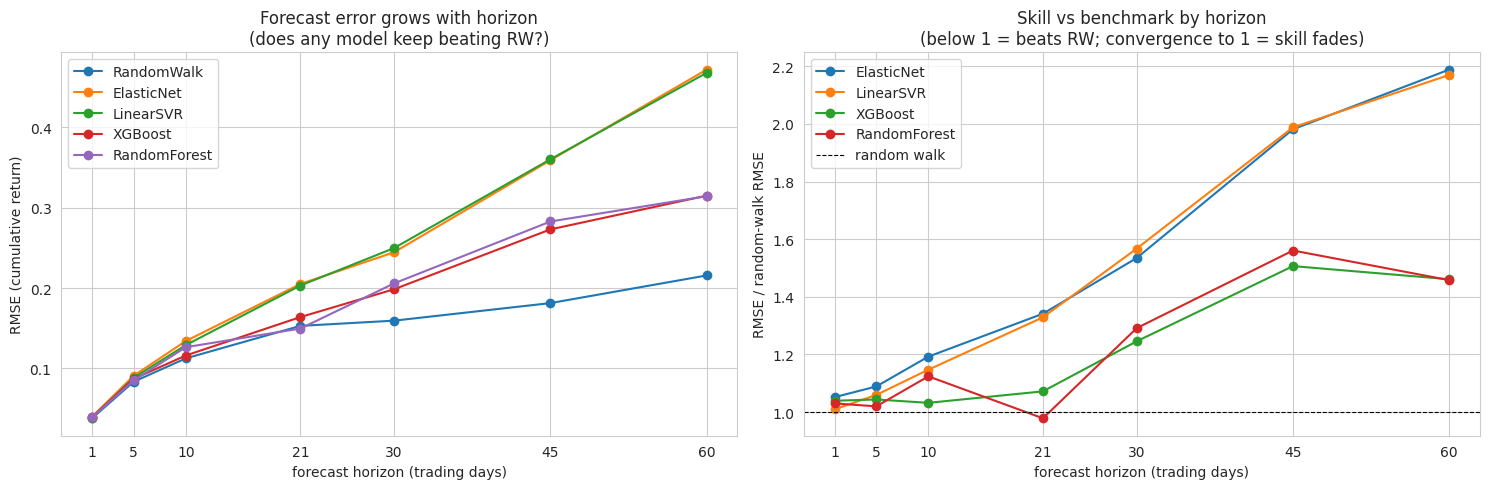

In [ ]:
# %% Cell E3: Multi-horizon visual - how accuracy & model ranking shift with horizon
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) RMSE vs horizon per model
ax = axes[0]
for name in ["RandomWalk"] + list(MH_MODELS):
    sub = mh[mh["Model"] == name].sort_values("Horizon")
    ax.plot(sub["Horizon"], sub["RMSE"], "o-", label=name, lw=1.5)
ax.set_xlabel("forecast horizon (trading days)"); ax.set_ylabel("RMSE (cumulative return)")
ax.set_title("Forecast error grows with horizon\n(does any model keep beating RW?)")
ax.set_xticks(HORIZONS); ax.legend()

# (b) RMSE relative to random walk (ratio < 1 = beats RW)
ax = axes[1]
rw_by_h = mh[mh["Model"]=="RandomWalk"].set_index("Horizon")["RMSE"]
for name in list(MH_MODELS):
    sub = mh[mh["Model"] == name].sort_values("Horizon")
    ratio = [r / rw_by_h[h] for h, r in zip(sub["Horizon"], sub["RMSE"])]
    ax.plot(sub["Horizon"], ratio, "o-", label=name, lw=1.5)
ax.axhline(1.0, color="k", ls="--", lw=0.8, label="random walk")
ax.set_xlabel("forecast horizon (trading days)"); ax.set_ylabel("RMSE / random-walk RMSE")
ax.set_title("Skill vs benchmark by horizon\n(below 1 = beats RW; convergence to 1 = skill fades)")
ax.set_xticks(HORIZONS); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sq1_multihorizon.png", dpi=150); plt.show()

#Regime split

In [ ]:
# %% Cell F1: Regime-split SQ1 - do the models hold up UNDER geopolitical stress?
# Splits each model's existing walk-forward predictions (h=1) by market regime,
# scoring RMSE and DM-vs-RW separately for calm vs each crisis window.
import numpy as np, pandas as pd
from scipy.stats import norm

def regime_labels(dates):
    reg = pd.Series("calm", index=dates)
    for nm, (s_, e_) in EVENTS.items():
        e_ = pd.Timestamp(e_) if e_ else dates.max()
        reg[(dates >= pd.Timestamp(s_)) & (dates <= e_)] = nm
    return reg

def dm_test(e_a, e_b):
    if len(e_a) < 10: return np.nan, np.nan       # too few obs for a stable test
    d = e_a**2 - e_b**2
    stat = d.mean() / np.sqrt(np.var(d, ddof=1) / len(d))
    return stat, 2 * (1 - norm.cdf(abs(stat)))

base = res["RandomWalk"]
rows = []
for regime in ["calm", "ukraine", "redsea", "iran", "all"]:
    for name in res:
        if name == "RandomWalk": continue
        act = res[name]["actual"]; pred = res[name]["preds"]
        idx = act.index.intersection(base["actual"].index)
        labs = regime_labels(idx)
        mask = (labs == regime).values if regime != "all" else np.ones(len(idx), bool)
        if mask.sum() < 10:
            continue
        sub = idx[mask]
        e_m = (act.loc[sub] - pred.loc[sub]).values
        e_b = (base["actual"].loc[sub] - base["preds"].loc[sub]).values
        rmse_m = np.sqrt(np.mean(e_m**2)); rmse_rw = np.sqrt(np.mean(e_b**2))
        stat, pv = dm_test(e_m, e_b)
        verdict = ("n/a" if np.isnan(pv) else
                   "ties RW" if pv >= 0.05 else ("beats RW" if stat < 0 else "WORSE"))
        rows.append({"Regime": regime, "Model": name, "N days": int(mask.sum()),
                     "RMSE": round(rmse_m, 5), "RW RMSE": round(rmse_rw, 5),
                     "DM": round(stat, 2) if not np.isnan(stat) else "-",
                     "p": round(pv, 4) if not np.isnan(pv) else "-", "vs RW": verdict})

reg_df = pd.DataFrame(rows)
print("=== SQ1 performance by market regime (h=1) ===")
print(reg_df.to_string(index=False))
reg_df.to_csv(f"{OUT_DIR}/sq1_by_regime.csv", index=False)

=== SQ1 performance by market regime (h=1) ===
Regime        Model  N days    RMSE  RW RMSE     DM      p    vs RW
  calm   ElasticNet     213 0.02264  0.02969  -3.62 0.0003 beats RW
  calm    LinearSVR     213 0.02226  0.02969  -3.50 0.0005 beats RW
  calm          MLP     213 0.08250  0.02969   5.93 0.0000    WORSE
  calm RandomForest     213 0.02890  0.02969  -0.84 0.4031  ties RW
  calm      XGBoost     213 0.02760  0.02969  -1.93 0.0535  ties RW
redsea   ElasticNet     308 0.02225  0.03115 -11.63 0.0000 beats RW
redsea    LinearSVR     308 0.02166  0.03115 -10.75 0.0000 beats RW
redsea          MLP     308 0.06594  0.03115   7.19 0.0000    WORSE
redsea RandomForest     308 0.02739  0.03115  -4.37 0.0000 beats RW
redsea      XGBoost     308 0.02648  0.03115  -3.92 0.0001 beats RW
  iran   ElasticNet      79 0.03737  0.06297  -3.20 0.0014 beats RW
  iran    LinearSVR      79 0.03251  0.06297  -3.26 0.0011 beats RW
  iran          MLP      79 0.07006  0.06297   0.88 0.3803  ties RW
 

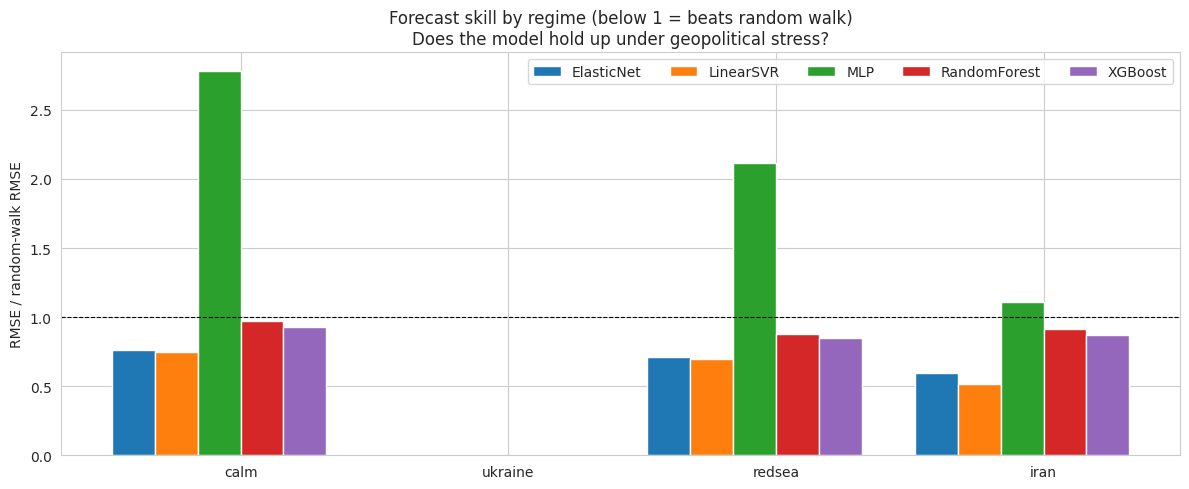

In [ ]:
# %% Cell F2: Regime-split visual - skill vs benchmark in each regime
import matplotlib.pyplot as plt
piv = reg_df[reg_df["Regime"].isin(["calm","ukraine","redsea","iran"])].copy()
piv["ratio"] = piv["RMSE"] / piv["RW RMSE"]     # <1 = beats RW in that regime
fig, ax = plt.subplots(figsize=(12, 5))
models = piv["Model"].unique()
regimes = ["calm","ukraine","redsea","iran"]
x = np.arange(len(regimes)); w = 0.8/len(models)
for i, m in enumerate(models):
    sub = piv[piv["Model"]==m].set_index("Regime").reindex(regimes)
    ax.bar(x + i*w, sub["ratio"], w, label=m)
ax.axhline(1.0, color="k", ls="--", lw=0.8)
ax.set_xticks(x + w*len(models)/2); ax.set_xticklabels(regimes)
ax.set_ylabel("RMSE / random-walk RMSE"); ax.set_title(
    "Forecast skill by regime (below 1 = beats random walk)\n"
    "Does the model hold up under geopolitical stress?")
ax.legend(ncol=len(models))
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sq1_regime_skill.png", dpi=150); plt.show()

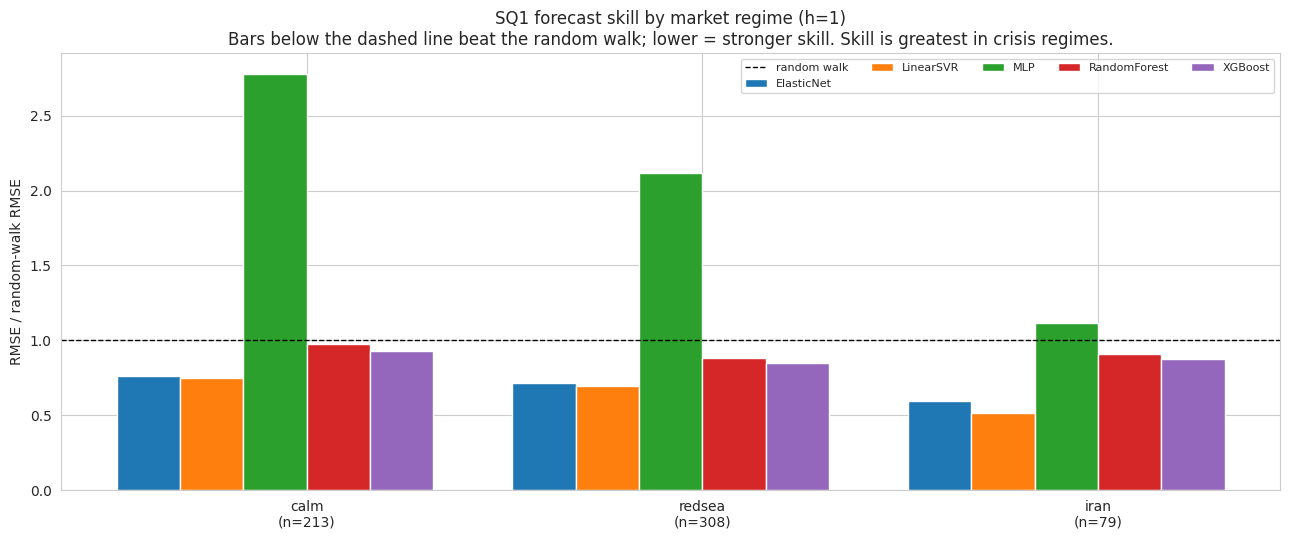

Mean skill ratio by regime (lower = better, <1 beats RW):
Regime
calm      1.239
iran      0.801
redsea    1.051


In [ ]:
# %% Cell F2: Regime-split visual - skill vs benchmark in each regime
import matplotlib.pyplot as plt
import numpy as np

piv = reg_df[reg_df["Regime"].isin(["calm","redsea","iran"])].copy()  # ukraine has no test-days
piv["ratio"] = piv["RMSE"] / piv["RW RMSE"]        # <1 = beats RW in that regime

fig, ax = plt.subplots(figsize=(13, 5.5))
models = list(piv["Model"].unique())
regimes = ["calm", "redsea", "iran"]
x = np.arange(len(regimes)); w = 0.8 / len(models)

for i, m in enumerate(models):
    sub = piv[piv["Model"] == m].set_index("Regime").reindex(regimes)
    bars = ax.bar(x + i*w, sub["ratio"], w, label=m)

ax.axhline(1.0, color="k", ls="--", lw=1, label="random walk")
ax.set_xticks(x + w*len(models)/2)
ax.set_xticklabels([f"{r}\n(n={int(piv[piv.Regime==r]['N days'].iloc[0])})" for r in regimes])
ax.set_ylabel("RMSE / random-walk RMSE")
ax.set_title("SQ1 forecast skill by market regime (h=1)\n"
             "Bars below the dashed line beat the random walk; "
             "lower = stronger skill. Skill is greatest in crisis regimes.")
ax.legend(ncol=len(models), fontsize=8, loc="upper right")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sq1_regime_skill.png", dpi=150); plt.show()

# quick numeric summary of the headline
print("Mean skill ratio by regime (lower = better, <1 beats RW):")
print(piv.groupby("Regime")["ratio"].mean().round(3).to_string())

In [ ]:
import pandas as pd
print(pd.read_csv(f"{OUT_DIR}/table1_descriptives.csv").to_string())

       Unnamed: 0       N    Mean    Std    Min  Median     Max       Start         End
0       hh_c1_usd  2991.0    3.17   1.33   1.48    2.84    9.68  2015-01-01  2026-06-18
1      ttf_c1_usd  2991.0   11.46  11.22   1.18    7.51   90.91  2015-01-01  2026-06-18
2      nbp_c1_usd  2992.0   10.79   9.17   1.03    7.68   75.22  2015-01-01  2026-06-19
3      jkm_c1_usd  2988.0   12.02   9.28   2.00    9.54   69.96  2015-01-01  2026-06-18
4      the_c1_usd  2967.0   11.70  11.38   1.25    7.64   99.19  2015-01-01  2026-07-03
5  spread_jkm_ttf  2988.0    0.55   3.17 -26.99    0.86   11.65  2015-01-01  2026-06-18
6     storage_pct  2992.0   63.79  21.40  17.70   65.69   99.50  2015-01-01  2026-06-19
7             gpr  3002.0  126.32  61.04   9.49  114.80  540.83  2015-01-02  2026-07-06
8      chk_hormuz  1957.0   51.72  17.59   0.00   53.00  102.00  2019-01-01  2026-07-01
9        chk_suez  1957.0   17.65   5.85   0.00   17.00   44.00  2019-01-01  2026-07-01


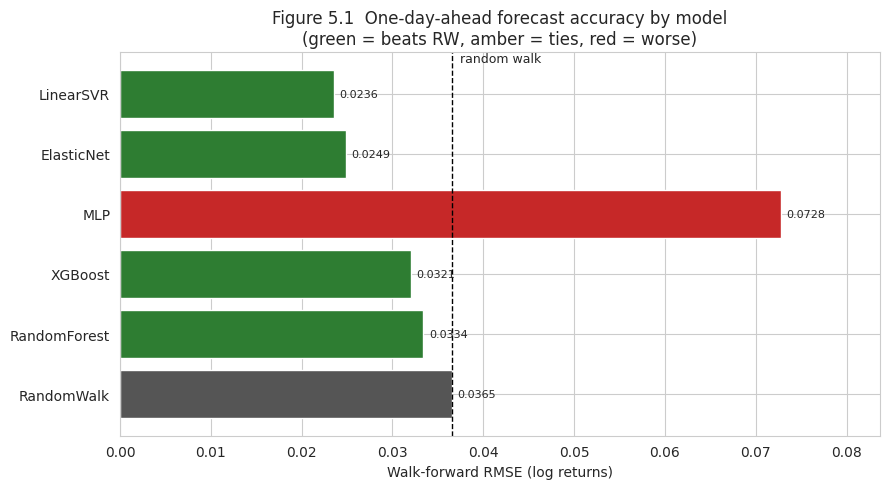

In [ ]:
# %% FIGURE 5.1 - SQ1 model comparison (RMSE, colour-coded by verdict)
import matplotlib.pyplot as plt

# pull from your res dict; fallback to confirmed values if a model is absent
order = ["LinearSVR","ElasticNet","MLP","XGBoost","RandomForest","RandomWalk","TCN","LSTM"]
rmse_map = {k: res[k]["rmse"] for k in order if k in res}
rmse_vals = [rmse_map.get(k, np.nan) for k in order]
rw = rmse_map.get("RandomWalk", 0.03651)

def verdict(name, r):
    if name == "RandomWalk": return "#555555"
    return "#2E7D32" if r < rw*0.995 else ("#C62828" if r > rw*1.005 else "#F9A825")
colors = [verdict(k, rmse_map.get(k, rw)) for k in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order[::-1], rmse_vals[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(rw, ls="--", color="k", lw=1)
ax.text(rw, len(order)-0.3, "  random walk", fontsize=9, va="top")
ax.set_xlabel("Walk-forward RMSE (log returns)")
ax.set_title("Figure 5.1  One-day-ahead forecast accuracy by model\n"
             "(green = beats RW, amber = ties, red = worse)")
for i, v in enumerate(rmse_vals[::-1]):
    if not np.isnan(v): ax.text(v+0.0006, i, f"{v:.4f}", va="center", fontsize=8)
ax.set_xlim(0, max(rmse_vals)*1.15)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_1_model_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

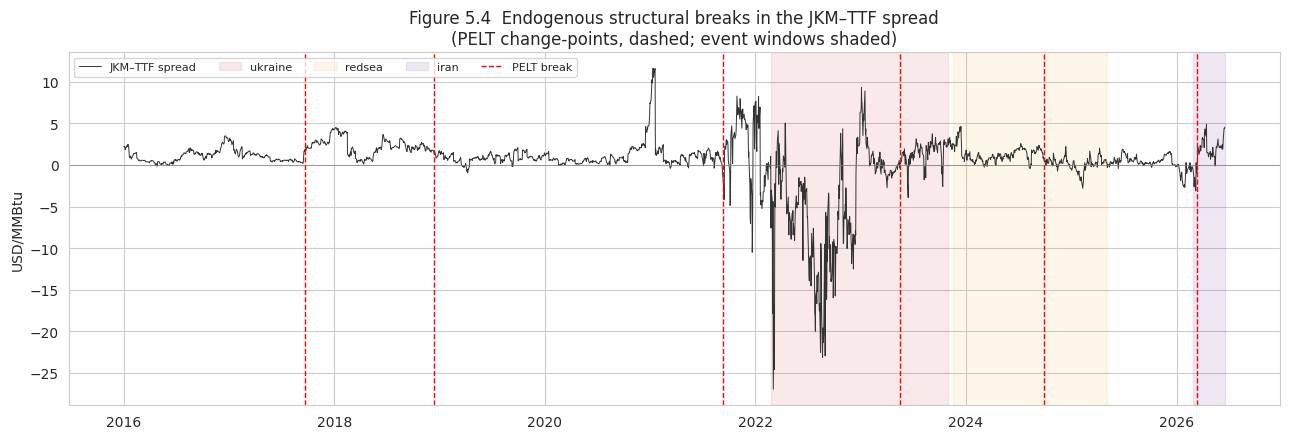

In [ ]:
# %% FIGURE 5.4 - Structural breaks: PELT change-points on JKM-TTF spread + event lines
import ruptures as rpt
import matplotlib.pyplot as plt

spread = p["spread_jkm_ttf"].dropna()
bkps = rpt.Pelt(model="rbf").fit(spread.values).predict(pen=32)
break_dates = spread.index[[b for b in bkps[:-1]]]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(spread.index, spread.values, lw=0.7, color="#333333", label="JKM–TTF spread")
# event windows shaded
cols = {"ukraine":"#C62828","redsea":"#F9A825","iran":"#6A1B9A"}
for nm,(s_,e_) in EVENTS.items():
    e_ = e_ or str(spread.index.max().date())
    ax.axvspan(pd.Timestamp(s_), pd.Timestamp(e_), alpha=0.10, color=cols[nm], label=nm)
# PELT breaks
for i,d in enumerate(break_dates):
    ax.axvline(d, color="red", ls="--", lw=1, label="PELT break" if i==0 else None)
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("USD/MMBtu"); ax.legend(ncol=5, fontsize=8)
ax.set_title("Figure 5.4  Endogenous structural breaks in the JKM–TTF spread\n"
             "(PELT change-points, dashed; event windows shaded)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_4_breaks.png", dpi=150, bbox_inches="tight"); plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


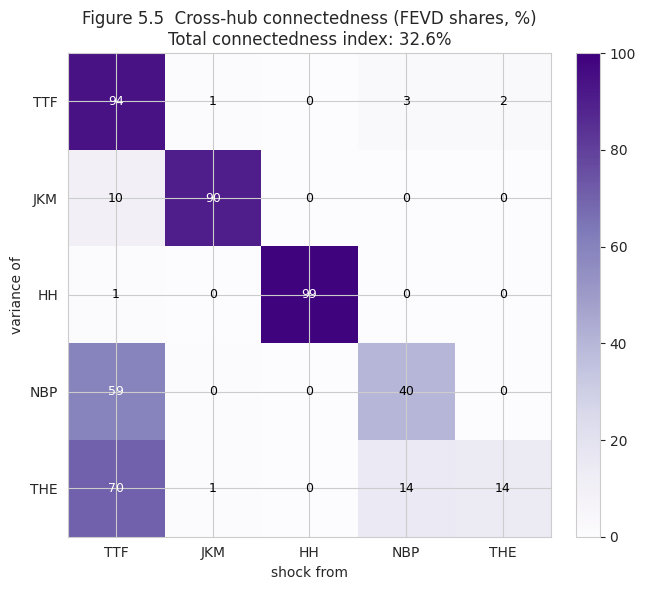

In [ ]:
# %% FIGURE 5.5 - Connectedness heatmap (directional variance shares)
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import numpy as np

HUBS_ = [h for h in ["ttf","jkm","hh","nbp","the"] if f"{h}_ret" in p.columns]
ret_cols = [f"{h}_ret" for h in HUBS_]
vd = p[ret_cols].dropna()
vres = VAR(vd).fit(2)
H, n = 10, len(ret_cols)
decomp = np.asarray(vres.fevd(H).decomp)
mat = decomp[-1] if decomp.shape==(H,n,n) else decomp[:,-1,:]
mat = np.asarray(mat).reshape(n,n)*100
labels = [h.upper() for h in HUBS_]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mat, cmap="Purples", vmin=0, vmax=100)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_xlabel("shock from"); ax.set_ylabel("variance of")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center",
                color="white" if mat[i,j]>50 else "black", fontsize=9)
total = 100*(mat.sum()-np.trace(mat))/mat.sum()
ax.set_title(f"Figure 5.5  Cross-hub connectedness (FEVD shares, %)\n"
             f"Total connectedness index: {total:.1f}%")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_5_connectedness.png", dpi=150, bbox_inches="tight"); plt.show()

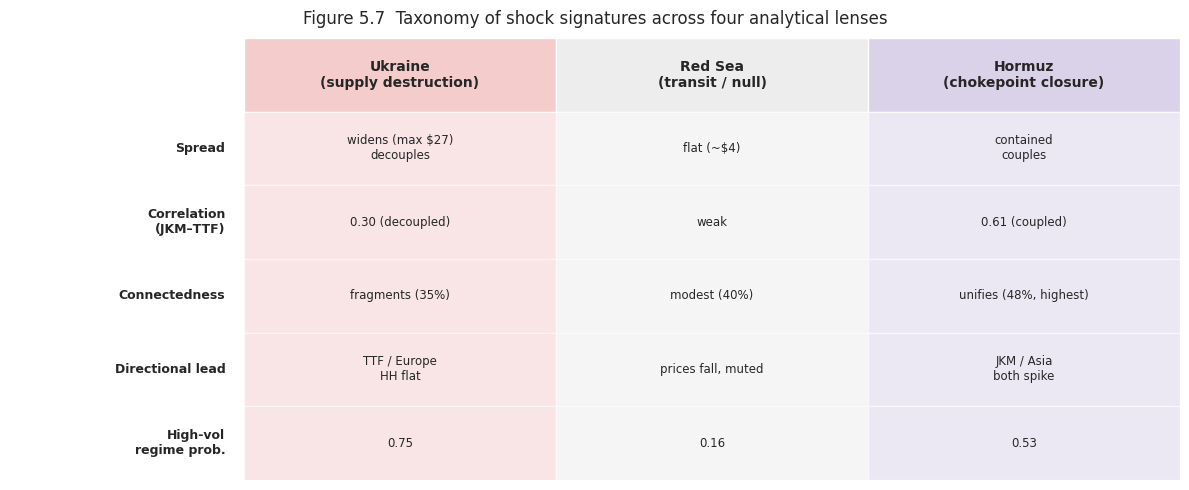

In [ ]:
# %% FIGURE 5.7 - Taxonomy matrix (static, for the report)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
crises = ["Ukraine\n(supply destruction)", "Red Sea\n(transit / null)", "Hormuz\n(chokepoint closure)"]
lenses = ["Spread", "Correlation\n(JKM–TTF)", "Connectedness", "Directional lead", "High-vol\nregime prob."]
data = [
    ["widens (max $27)\ndecouples", "flat (~$4)", "contained\ncouples"],
    ["0.30 (decoupled)", "weak", "0.61 (coupled)"],
    ["fragments (35%)", "modest (40%)", "unifies (48%, highest)"],
    ["TTF / Europe\nHH flat", "prices fall, muted", "JKM / Asia\nboth spike"],
    ["0.75", "0.16", "0.53"],
]
col_colors = ["#F4CCCC", "#EDEDED", "#D9D2E9"]   # coral / grey / purple tint
cell_w, cell_h = 1.0/3, 1.0/(len(lenses)+1)
# header row
for j,cr in enumerate(crises):
    ax.add_patch(plt.Rectangle((j*cell_w, 1-cell_h), cell_w, cell_h, color=col_colors[j], ec="white"))
    ax.text(j*cell_w+cell_w/2, 1-cell_h/2, cr, ha="center", va="center", fontsize=10, fontweight="bold")
# lens rows
for i,ln in enumerate(lenses):
    y = 1-(i+2)*cell_h
    ax.text(-0.02, y+cell_h/2, ln, ha="right", va="center", fontsize=9, fontweight="bold")
    for j in range(3):
        ax.add_patch(plt.Rectangle((j*cell_w, y), cell_w, cell_h, fc=col_colors[j], ec="white", alpha=0.5))
        ax.text(j*cell_w+cell_w/2, y+cell_h/2, data[i][j], ha="center", va="center", fontsize=8.5)
ax.set_xlim(-0.25, 1); ax.set_ylim(0, 1)
ax.set_title("Figure 5.7  Taxonomy of shock signatures across four analytical lenses", fontsize=12, pad=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_7_taxonomy.png", dpi=150, bbox_inches="tight"); plt.show()

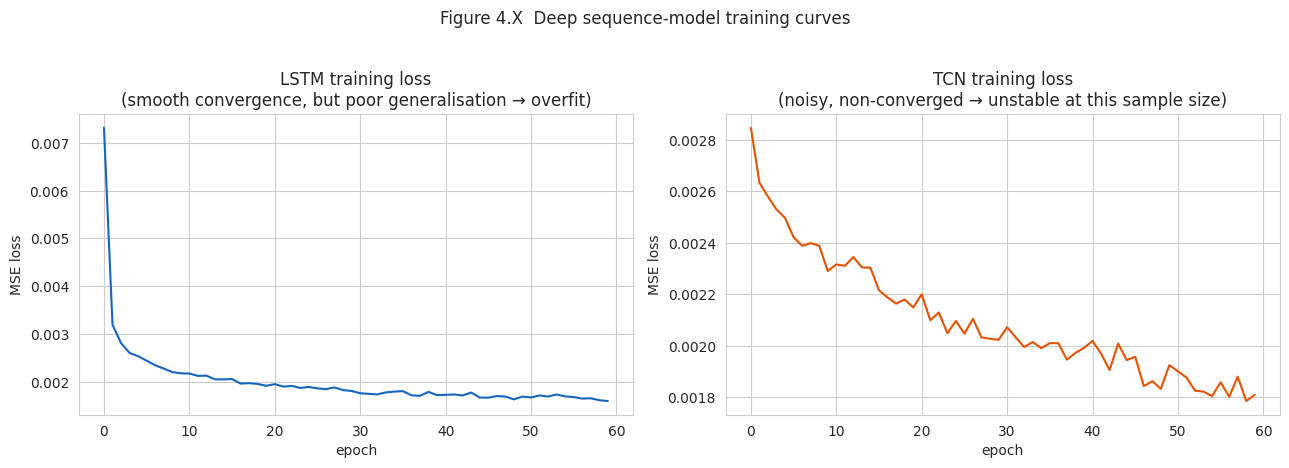

In [ ]:
# %% FIGURE (Methodology) - Sequence-model training curves (LSTM overfit / TCN non-convergence)
# Re-plot the D2 curves cleanly for the methodology hyperparameter section.
# (Only if lstm_losses / tcn_losses are still in memory from Cell D2; else re-run D2.)
import matplotlib.pyplot as plt
try:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(lstm_losses, lw=1.5, color="#1565C0")
    axes[0].set_title("LSTM training loss\n(smooth convergence, but poor generalisation → overfit)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss")
    axes[1].plot(tcn_losses, lw=1.5, color="#E65100")
    axes[1].set_title("TCN training loss\n(noisy, non-converged → unstable at this sample size)")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("MSE loss")
    plt.suptitle("Figure 4.X  Deep sequence-model training curves", y=1.03, fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_seq_training.png", dpi=150, bbox_inches="tight"); plt.show()
except NameError:
    print("Run Cell D2 first to regenerate lstm_losses / tcn_losses.")

In [ ]:
# %% Save/verify all figures to Drive + inventory
import os, glob, shutil

# Dedicated figures folder inside your Drive output dir
FIG_DIR = f"{OUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Copy any PNGs sitting in OUT_DIR into the figures subfolder
for png in glob.glob(f"{OUT_DIR}/*.png"):
    dest = os.path.join(FIG_DIR, os.path.basename(png))
    if os.path.abspath(png) != os.path.abspath(dest):
        shutil.copy(png, dest)

# Inventory: what's now on Drive
figs = sorted(glob.glob(f"{FIG_DIR}/*.png"))
print(f"{len(figs)} figures saved to: {FIG_DIR}\n")
for f in figs:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):40s} {size_kb:6.0f} KB")

# Flag the ones the Results chapter expects, so you can see what's still missing
expected = [
    "fig5_1_model_comparison.png", "sq1_multihorizon.png", "sq1_regime_skill.png",
    "fig5_4_breaks.png", "fig5_5_connectedness.png", "sq2_shap_global.png",
    "fig5_7_taxonomy.png", "hyperparam_curves.png", "fig_seq_training.png",
    "prices_events.png", "chokepoints.png",
]
have = {os.path.basename(f) for f in figs}
print("\nChapter figure checklist:")
for e in expected:
    print(f"  {'[OK]' if e in have else '[MISSING]'}  {e}")

30 figures saved to: /content/drive/MyDrive/Dissertation Analysis/output/figures

  check1_raw_series.png                       622 KB
  check2_coverage.png                         116 KB
  check3_units.png                            305 KB
  check4_features.png                         471 KB
  chokepoints.png                             291 KB
  correlation_heatmap.png                     231 KB
  eda_acf.png                                  36 KB
  eda_stl.png                                 154 KB
  event_study_car.png                         235 KB
  fig5_1_model_comparison.png                  71 KB
  fig5_4_breaks.png                           126 KB
  fig5_5_connectedness.png                     52 KB
  fig5_7_taxonomy.png                          94 KB
  fig_seq_training.png                        103 KB
  hyperparam_curves.png                       235 KB
  markov_regime.png                           200 KB
  prices_events.png                           185 KB
  rolling_connect

#RMSE MAE MSE

In [ ]:
# %% Add MAE and MSE to the model comparison (run after your model res dict exists)
import numpy as np, pandas as pd
from scipy.stats import norm

def dm_test(e_a, e_b):
    d = e_a**2 - e_b**2
    stat = d.mean() / np.sqrt(np.var(d, ddof=1)/len(d))
    return stat, 2*(1-norm.cdf(abs(stat)))

base = res["RandomWalk"]
rows = []
for name in res:
    act, pred = res[name]["actual"], res[name]["preds"]
    err = (act - pred).values
    rmse = np.sqrt(np.mean(err**2)); mae = np.mean(np.abs(err)); mse = np.mean(err**2)
    if name == "RandomWalk":
        rows.append([name, round(rmse,5), round(mae,5), round(mse,6), "-", "-", "benchmark"]); continue
    idx = act.index.intersection(base["actual"].index)
    stat, pv = dm_test((act.loc[idx]-pred.loc[idx]).values,
                       (base["actual"].loc[idx]-base["preds"].loc[idx]).values)
    verdict = "ties RW" if pv>=0.05 else ("beats RW" if stat<0 else "worse")
    rows.append([name, round(rmse,5), round(mae,5), round(mse,6), round(stat,2), round(pv,4), verdict])
comp = pd.DataFrame(rows, columns=["Model","RMSE","MAE","MSE","DM","p","vs RW"]).sort_values("RMSE")
print(comp.to_string(index=False))
comp.to_csv(f"{OUT_DIR}/sq1_metrics_full.csv", index=False)

       Model    RMSE     MAE      MSE    DM       p     vs RW
   LinearSVR 0.02378 0.01671 0.000565 -6.07     0.0  beats RW
  ElasticNet 0.02490 0.01741 0.000620  -6.1     0.0  beats RW
         MLP 0.02534 0.01964 0.000642 -3.97  0.0001  beats RW
     XGBoost 0.03206 0.02222 0.001028 -3.83  0.0001  beats RW
RandomForest 0.03341 0.02306 0.001116 -4.35     0.0  beats RW
  RandomWalk 0.03651 0.02503 0.001333     -       - benchmark
         TCN 0.03783 0.02700 0.001431  1.52  0.1292   ties RW
        LSTM 0.04767 0.03581 0.002272  6.88     0.0     worse


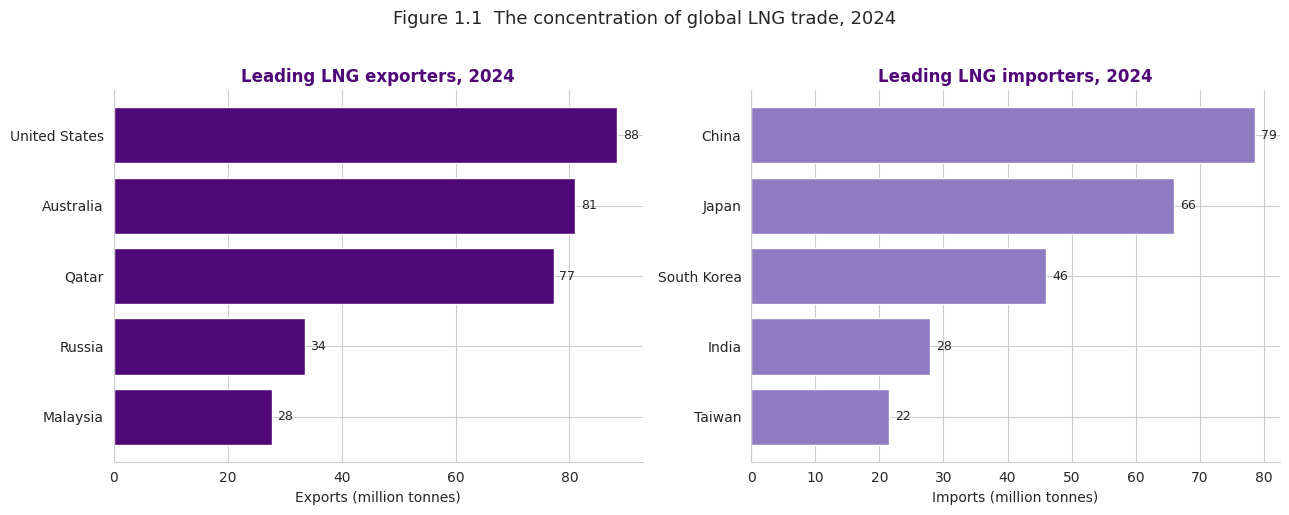

In [ ]:
# %% FIGURE 1.1 - Leading LNG exporters and importers, 2024 (own chart, public data)
import matplotlib.pyplot as plt

# 2024 volumes in million tonnes (MT). Sources: IGU World LNG Report 2025;
# Energy Institute Statistical Review 2025. VERIFY against latest before submission.
exporters = {"United States": 88.4, "Australia": 81.0, "Qatar": 77.2,
             "Russia": 33.5, "Malaysia": 27.7}
importers = {"China": 78.6, "Japan": 66.0, "South Korea": 46.0,
             "India": 27.9, "Taiwan": 21.5}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(list(exporters)[::-1], list(exporters.values())[::-1],
             color="#500778", edgecolor="white")
axes[0].set_title("Leading LNG exporters, 2024", fontsize=12, color="#500778", fontweight="bold")
axes[0].set_xlabel("Exports (million tonnes)")
for i, v in enumerate(list(exporters.values())[::-1]):
    axes[0].text(v + 1, i, f"{v:.0f}", va="center", fontsize=9)

axes[1].barh(list(importers)[::-1], list(importers.values())[::-1],
             color="#8E7CC3", edgecolor="white")
axes[1].set_title("Leading LNG importers, 2024", fontsize=12, color="#500778", fontweight="bold")
axes[1].set_xlabel("Imports (million tonnes)")
for i, v in enumerate(list(importers.values())[::-1]):
    axes[1].text(v + 1, i, f"{v:.0f}", va="center", fontsize=9)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Figure 1.1  The concentration of global LNG trade, 2024",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig1_1_lng_trade.png", dpi=150, bbox_inches="tight")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 36.4 MB/s eta 0:00:00


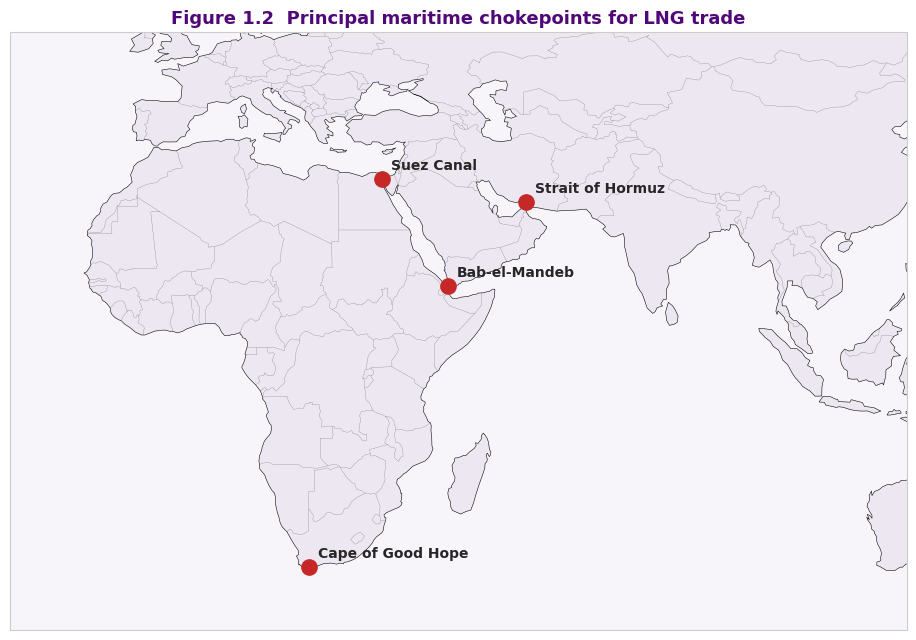

In [ ]:
# %% FIGURE 1.2 - Maritime chokepoints for LNG trade (own annotated map)
# Uses a simple coastline via cartopy if available, else a clean schematic.
import matplotlib.pyplot as plt
!pip install cartopy
chokepoints = {
    "Strait of Hormuz":     (56.3, 26.6),
    "Suez Canal":           (32.3, 30.5),
    "Bab-el-Mandeb":        (43.3, 12.6),
    "Cape of Good Hope":    (20.0, -34.4),
}

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    fig = plt.figure(figsize=(13, 6.5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-30, 120, -45, 55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#EDE7F1")
    ax.add_feature(cfeature.OCEAN, facecolor="#F7F5FA")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)
    for name, (lon, lat) in chokepoints.items():
        ax.plot(lon, lat, "o", color="#C62828", markersize=11,
                transform=ccrs.PlateCarree(), zorder=5)
        ax.text(lon + 1.5, lat + 1.5, name, fontsize=10, fontweight="bold",
                transform=ccrs.PlateCarree())
    ax.set_title("Figure 1.2  Principal maritime chokepoints for LNG trade",
                 fontsize=13, color="#500778", fontweight="bold")
except ImportError:
    # fallback: schematic locator without cartopy
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.set_facecolor("#F7F5FA")
    for name, (lon, lat) in chokepoints.items():
        ax.scatter(lon, lat, s=140, color="#C62828", zorder=5)
        ax.annotate(name, (lon, lat), textcoords="offset points",
                    xytext=(8, 8), fontsize=10, fontweight="bold")
    ax.set_xlim(-30, 120); ax.set_ylim(-45, 55)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Figure 1.2  Principal maritime chokepoints for LNG trade\n"
                 "(install cartopy for a coastline base map)",
                 fontsize=12, color="#500778", fontweight="bold")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig1_2_chokepoints.png", dpi=150, bbox_inches="tight")
plt.show()

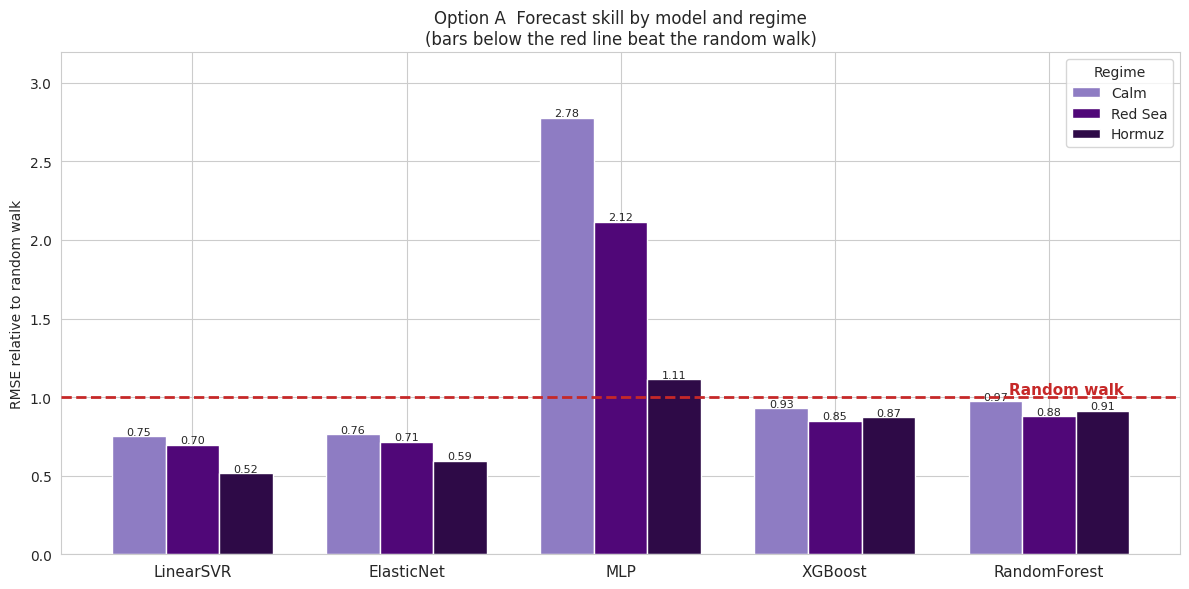

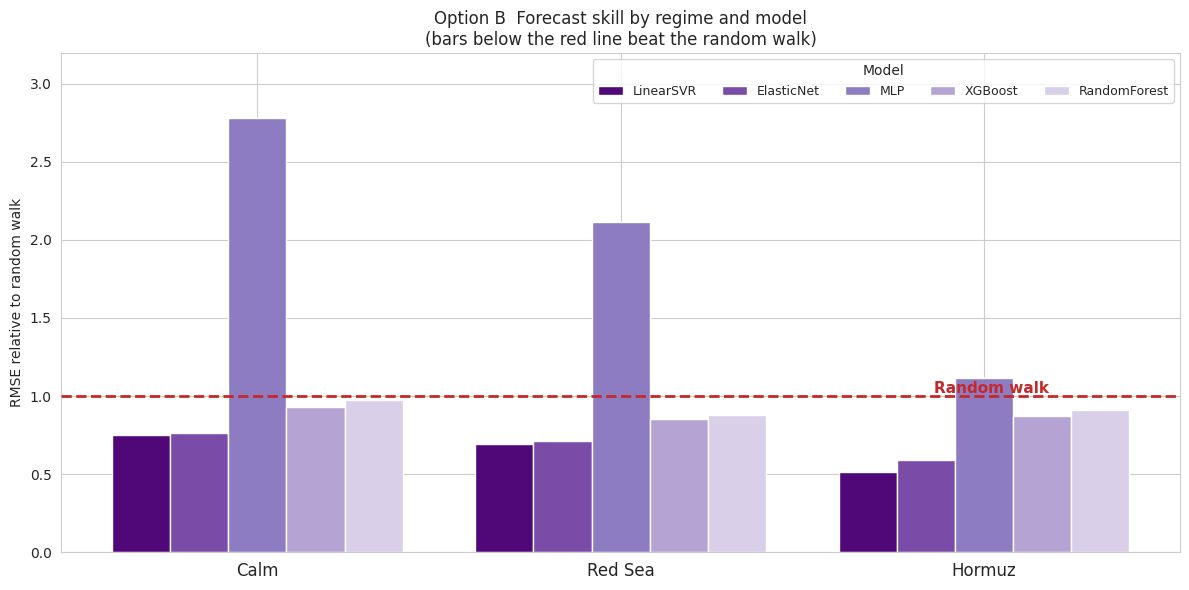

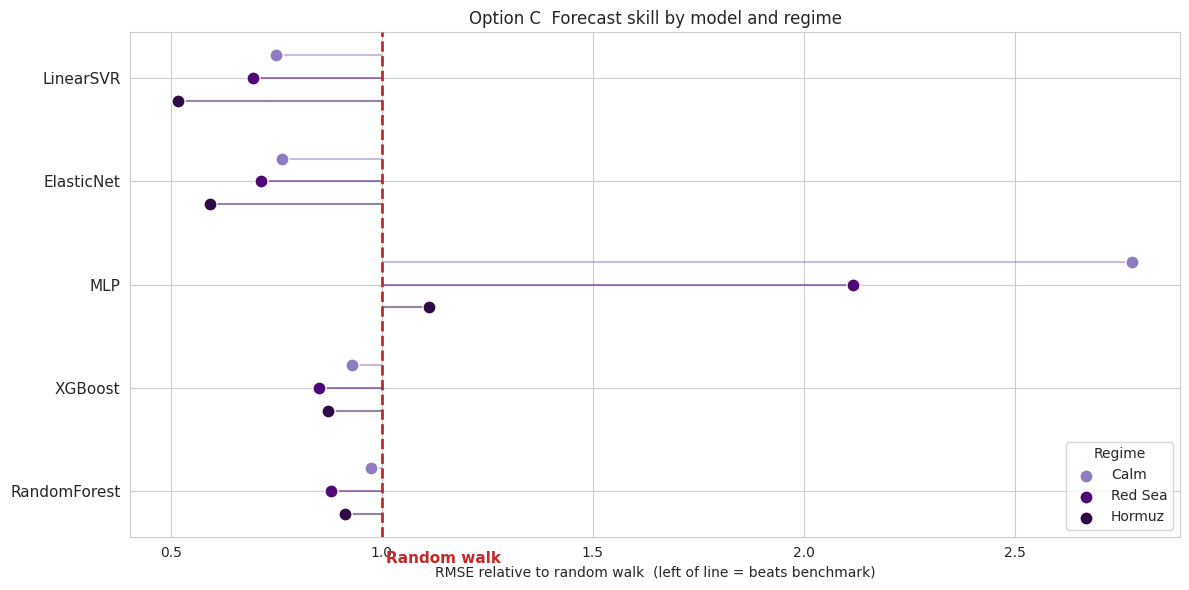

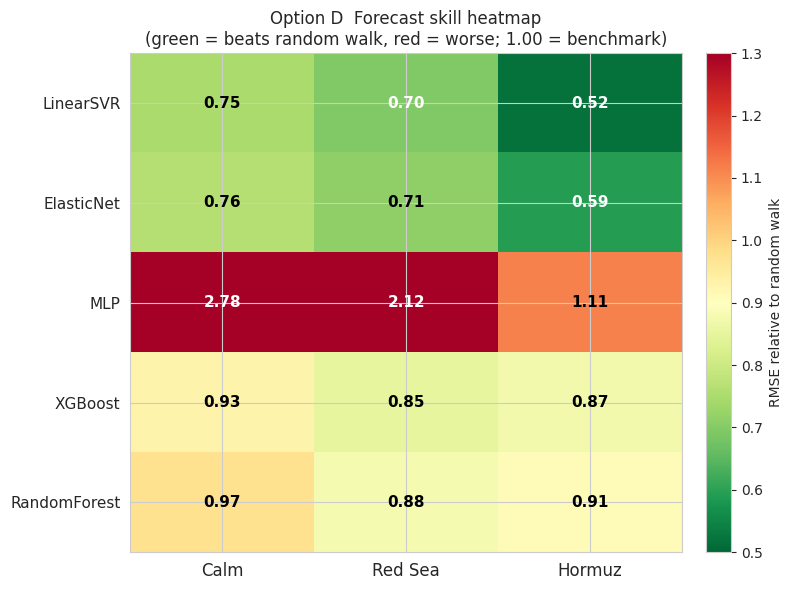

Saved: regime_optA_grouped, regime_optB_grouped, regime_optC_lollipop, regime_optD_heatmap


In [ ]:
# %% Regime figure - FOUR alternative representations (run all, pick one)
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

# Use only regimes with test-days; models in fixed order
models = ["LinearSVR","ElasticNet","MLP","XGBoost","RandomForest"]
regimes = ["calm","redsea","iran"]
regime_label = {"calm":"Calm","redsea":"Red Sea","iran":"Hormuz"}
reg_df["ratio"] = reg_df["RMSE"] / reg_df["RW RMSE"]

def ratio(m, rg):
    r = reg_df[(reg_df.Model==m)&(reg_df.Regime==rg)]["ratio"].values
    return r[0] if len(r) else np.nan

# regime colours (random walk shown as the reference line, not a bar)
rcols = {"calm":"#8E7CC3","redsea":"#500778","iran":"#2E0A47"}


# ============ OPTION A: grouped bars, MODELS on x-axis ============
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models)); w = 0.25
for i, rg in enumerate(regimes):
    vals = [ratio(m, rg) for m in models]
    bars = ax.bar(x + i*w, vals, w, label=regime_label[rg], color=rcols[rg], edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=8)
# random walk = the reference line at 1.0, clearly styled
ax.axhline(1.0, ls="--", lw=2, color="#C62828", zorder=5)
ax.text(len(models)-0.4, 1.02, "Random walk", color="#C62828", fontsize=11, fontweight="bold", ha="right")
ax.set_xticks(x + w); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("RMSE relative to random walk")
ax.set_title("Option A  Forecast skill by model and regime\n(bars below the red line beat the random walk)")
ax.legend(title="Regime"); ax.set_ylim(0, max(reg_df["ratio"])*1.15)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/regime_optA_grouped.png", dpi=150, bbox_inches="tight"); plt.show()


# ============ OPTION B: grouped bars, REGIMES on x-axis, models as series ============
fig, ax = plt.subplots(figsize=(12, 6))
mcols = ["#500778","#7B4BA8","#8E7CC3","#B5A3D4","#D9CFE8"]
x = np.arange(len(regimes)); w = 0.16
for i, m in enumerate(models):
    vals = [ratio(m, rg) for rg in regimes]
    ax.bar(x + i*w, vals, w, label=m, color=mcols[i], edgecolor="white")
ax.axhline(1.0, ls="--", lw=2, color="#C62828", zorder=5)
ax.text(len(regimes)-0.5, 1.02, "Random walk", color="#C62828", fontsize=11, fontweight="bold", ha="right")
ax.set_xticks(x + w*2); ax.set_xticklabels([regime_label[r] for r in regimes], fontsize=12)
ax.set_ylabel("RMSE relative to random walk")
ax.set_title("Option B  Forecast skill by regime and model\n(bars below the red line beat the random walk)")
ax.legend(title="Model", ncol=5, fontsize=9); ax.set_ylim(0, max(reg_df["ratio"])*1.15)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/regime_optB_grouped.png", dpi=150, bbox_inches="tight"); plt.show()


# ============ OPTION C: dot / lollipop plot (cleanest for "who beats the line") ============
fig, ax = plt.subplots(figsize=(12, 6))
for i, rg in enumerate(regimes):
    vals = [ratio(m, rg) for m in models]
    y = np.arange(len(models)) + (i-1)*0.22
    ax.hlines(y, 1.0, vals, color=rcols[rg], alpha=0.5, lw=1.5)
    ax.scatter(vals, y, s=90, color=rcols[rg], label=regime_label[rg], zorder=5, edgecolor="white")
ax.axvline(1.0, ls="--", lw=2, color="#C62828", zorder=4)
ax.text(1.01, len(models)-0.3, "Random walk", color="#C62828", fontsize=11, fontweight="bold")
ax.set_yticks(np.arange(len(models))); ax.set_yticklabels(models, fontsize=11)
ax.set_xlabel("RMSE relative to random walk  (left of line = beats benchmark)")
ax.set_title("Option C  Forecast skill by model and regime")
ax.legend(title="Regime", loc="lower right"); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/regime_optC_lollipop.png", dpi=150, bbox_inches="tight"); plt.show()


# ============ OPTION D: heatmap (models x regimes), colour = skill ============
piv = pd.DataFrame({rg:[ratio(m,rg) for m in models] for rg in regimes}, index=models)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0.5, vmax=1.3, aspect="auto")
ax.set_xticks(range(len(regimes))); ax.set_xticklabels([regime_label[r] for r in regimes], fontsize=12)
ax.set_yticks(range(len(models))); ax.set_yticklabels(models, fontsize=11)
for i in range(len(models)):
    for j in range(len(regimes)):
        v = piv.values[i,j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if (v<0.7 or v>1.15) else "black", fontsize=11, fontweight="bold")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04); cbar.set_label("RMSE relative to random walk")
ax.set_title("Option D  Forecast skill heatmap\n(green = beats random walk, red = worse; 1.00 = benchmark)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/regime_optD_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

print("Saved: regime_optA_grouped, regime_optB_grouped, regime_optC_lollipop, regime_optD_heatmap")

In [ ]:
# ============================================================
# PART 1 - DISCOVER what data you have in OUT_DIR
# (run this first; it tells you which plots you can make)
# ============================================================
import os, glob, pandas as pd

# OUT_DIR should already be set; if not, set it:
# OUT_DIR = "/content/drive/MyDrive/Dissertation Analysis/output"

print("CSV files in OUT_DIR:\n")
for f in sorted(glob.glob(f"{OUT_DIR}/*.csv")):
    name = os.path.basename(f)
    try:
        df = pd.read_csv(f)
        print(f"  {name:32s}  shape={df.shape}  cols={list(df.columns)}")
    except Exception as e:
        print(f"  {name:32s}  (could not read: {e})")

CSV files in OUT_DIR:

  adf_test_results.csv              shape=(7, 4)  cols=['Variable', 'ADF Statistic', 'p-value', 'Stationary (5%)']
  cointegration_results.csv         shape=(3, 4)  cols=['Hypothesis', 'Trace Statistic', '5% Critical Value', 'Reject Null?']
  crisis_comparison.csv             shape=(3, 11)  cols=['Crisis', 'Type', 'N days', 'Spread mean', 'Spread vs calm', 'Spread max', 'TTF vol (ann)', 'JKM vol (ann)', 'HH vol (ann)', 'corr JKM-TTF', 'corr TTF-HH']
  diag_stationarity.csv             shape=(5, 5)  cols=['Hub', 'ADF level p', 'ADF return p', 'KPSS return p', 'Excess kurtosis']
  hyperparameter_table.csv          shape=(6, 3)  cols=['Model', 'Key hyperparameters', 'Rationale']
  master_panel.csv                  shape=(3003, 134)  cols=['Unnamed: 0', 'chk_bab', 'brent_c1', 'cegh_spot', 'chk_cape', 'storage_pct', 'eua_c1', 'fx_eurusd', 'fx_gbpusd', 'hh_spot', 'hh_c1', 'hh_c10', 'hh_c11', 'hh_c12', 'hh_c2', 'hh_c3', 'hh_c4', 'hh_c5', 'hh_c6', 'hh_c7', 'hh_c8', 'hh_c

In [ ]:
# ============================================================
# PART 2 - THE PUBLICATION THEME (run once)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, os

PURPLE="#500778"; LILAC="#8E7CC3"; DPURPLE="#2E0A47"; MIDP="#7B4BA8"
INK="#222222"; GREY="#666666"; GREEN="#2E7D32"; AMBER="#C99700"; RED="#C62828"; GRID="#E8E8E8"

def set_pub_theme():
    plt.rcParams.update({
        "figure.dpi":150, "savefig.dpi":300, "figure.facecolor":"white", "savefig.facecolor":"white",
        "font.family":"sans-serif", "font.sans-serif":["Arial","Helvetica","DejaVu Sans"],
        "font.size":11, "axes.titlesize":14, "axes.titleweight":"bold", "axes.titlepad":14,
        "axes.labelsize":11, "axes.labelcolor":INK, "axes.edgecolor":GREY, "axes.linewidth":0.8,
        "axes.spines.top":False, "axes.spines.right":False, "axes.grid":True,
        "grid.color":GRID, "grid.linewidth":0.7, "axes.axisbelow":True,
        "xtick.color":GREY, "ytick.color":GREY, "text.color":INK,
        "legend.frameon":False, "legend.fontsize":10,
    })
set_pub_theme()

def save(fig, name):
    path = f"{OUT_DIR}/{name}"
    fig.savefig(path, bbox_inches="tight", dpi=300)
    print("saved:", path)

saved: /content/drive/MyDrive/Dissertation Analysis/output/fig_model_comparison_styled.png


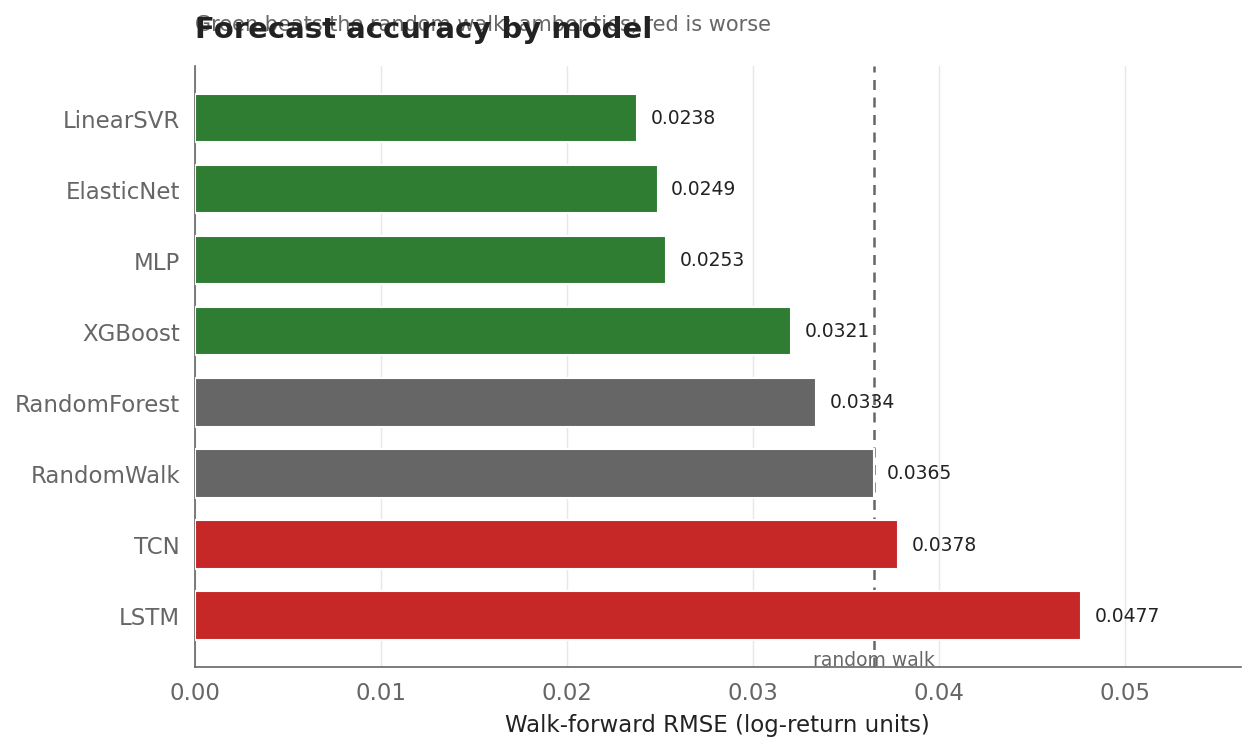

In [ ]:
# ============================================================
# PART 3a - MODEL COMPARISON  (reads sq1_metrics_full.csv or sq1_tuned_comparison.csv)
# ============================================================
# adjust the filename/column names to match what PART 1 printed
df = pd.read_csv(f"{OUT_DIR}/sq1_metrics_full.csv")
# expect columns like Model, RMSE (rename if yours differ)
mcol = "Model"; rcol = "RMSE"
df = df[[mcol, rcol]].dropna().sort_values(rcol, ascending=False).reset_index(drop=True)
rw = df.loc[df[mcol].str.contains("andom", case=False), rcol].values
rw = rw[0] if len(rw) else df[rcol].max()

def verdict_colour(m, r):
    if "andom" in m.lower(): return GREY
    return GREEN if r < rw*0.995 else (RED if r > rw*1.005 else AMBER)

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.barh(df[mcol], df[rcol], height=0.68,
               color=[verdict_colour(m, r) for m, r in zip(df[mcol], df[rcol])], zorder=3)
ax.axvline(rw, color=GREY, ls=(0,(4,3)), lw=1.2, zorder=2)
ax.text(rw, -0.7, "random walk", color=GREY, fontsize=9, ha="center")
for b, r in zip(bars, df[rcol]):
    ax.text(r + df[rcol].max()*0.015, b.get_y()+b.get_height()/2, f"{r:.4f}",
            va="center", fontsize=9, color=INK)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, df[rcol].max()*1.18)
ax.set_xlabel("Walk-forward RMSE (log-return units)")
ax.set_title("Forecast accuracy by model", loc="left")
ax.text(0, 1.06, "Green beats the random walk; amber ties; red is worse",
        transform=ax.transAxes, fontsize=10, color=GREY)
save(fig, "fig_model_comparison_styled.png"); plt.show()

saved: /content/drive/MyDrive/Dissertation Analysis/output/fig_regime_styled.png


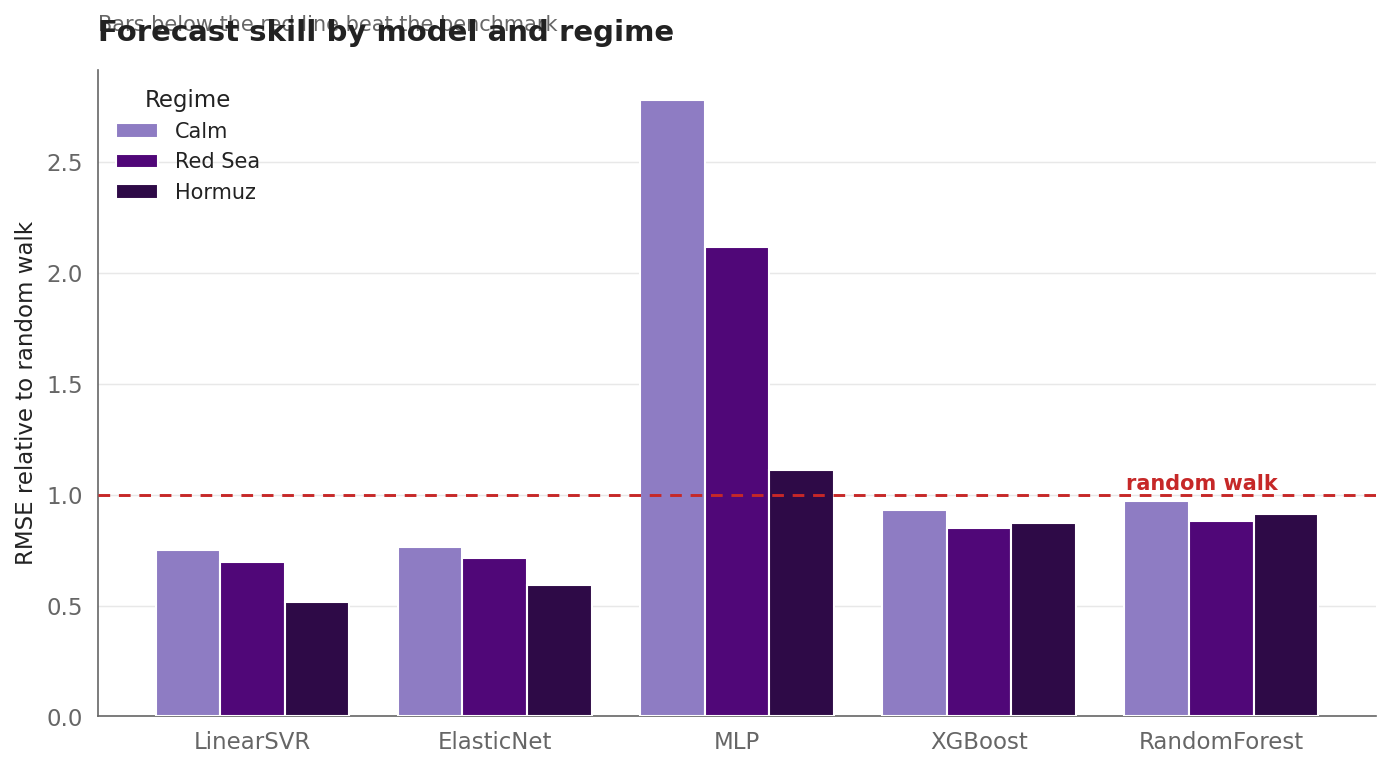

In [ ]:
# ============================================================
# PART 3b - REGIME (Option A: models on x, regimes grouped) - reads sq1_by_regime.csv
# ============================================================
reg = pd.read_csv(f"{OUT_DIR}/sq1_by_regime.csv")
# expect columns: Regime, Model, RMSE, RW RMSE  (adjust to match PART 1 output)
reg["ratio"] = reg["RMSE"] / reg["RW RMSE"]
models = [m for m in ["LinearSVR","ElasticNet","MLP","XGBoost","RandomForest"] if m in reg["Model"].unique()]
regimes = [r for r in ["calm","redsea","iran"] if r in reg["Regime"].unique()]
labs = {"calm":"Calm","redsea":"Red Sea","iran":"Hormuz"}
rcols = {"calm":LILAC, "redsea":PURPLE, "iran":DPURPLE}

fig, ax = plt.subplots(figsize=(11, 5.6))
x = np.arange(len(models)); w = 0.8/len(regimes)
for i, rg in enumerate(regimes):
    vals = [reg[(reg.Model==m)&(reg.Regime==rg)]["ratio"].values[0]
            if len(reg[(reg.Model==m)&(reg.Regime==rg)]) else np.nan for m in models]
    ax.bar(x + i*w, vals, w, label=labs.get(rg,rg), color=rcols.get(rg,LILAC), zorder=3)
ax.axhline(1.0, color=RED, ls=(0,(4,3)), lw=1.4, zorder=4)
ax.text(len(models)-0.5, 1.02, "random walk", color=RED, fontsize=10, ha="right", fontweight="bold")
ax.set_xticks(x + w*(len(regimes)-1)/2); ax.set_xticklabels(models)
ax.grid(axis="x", visible=False)
ax.set_ylabel("RMSE relative to random walk")
ax.set_title("Forecast skill by model and regime", loc="left")
ax.text(0, 1.06, "Bars below the red line beat the benchmark",
        transform=ax.transAxes, fontsize=10, color=GREY)
ax.legend(title="Regime", loc="upper left")
save(fig, "fig_regime_styled.png"); plt.show()

In [ ]:
# ============================================================
# EDITORIAL FIGURE THEME - fixes the font problem + magazine look
# Run this whole cell once. It downloads a proper font (Lato),
# which is 90% of why styled charts still look "default".
# ============================================================
import os, urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np, pandas as pd

# --- 1. Download a clean editorial font (Lato) if not present ---
FONT_DIR = "/content/fonts"; os.makedirs(FONT_DIR, exist_ok=True)
fonts = {
    "Lato-Regular.ttf": "https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf",
    "Lato-Bold.ttf":    "https://github.com/google/fonts/raw/main/ofl/lato/Lato-Bold.ttf",
    "Lato-Light.ttf":   "https://github.com/google/fonts/raw/main/ofl/lato/Lato-Light.ttf",
}
for fn, url in fonts.items():
    p = os.path.join(FONT_DIR, fn)
    if not os.path.exists(p):
        urllib.request.urlretrieve(url, p)
    fm.fontManager.addfont(p)
LATO = fm.FontProperties(fname=os.path.join(FONT_DIR,"Lato-Regular.ttf")).get_name()
print("Font loaded:", LATO)   # should print 'Lato', NOT 'DejaVu Sans'

# --- 2. Palette + theme ---
PURPLE="#500778"; LILAC="#9B87C4"; DPURPLE="#2E0A47"
INK="#1A1A1A"; SOFT="#6B6B6B"; FAINT="#B0B0B0"
GREEN="#2E7D46"; AMBER="#C99700"; RED="#C0392B"; HAIR="#EDEDED"

plt.rcParams.update({
    "figure.dpi":150, "savefig.dpi":300, "figure.facecolor":"white", "savefig.facecolor":"white",
    "font.family":LATO, "font.size":12,
    "axes.spines.top":False, "axes.spines.right":False, "axes.spines.left":False,
    "axes.edgecolor":FAINT, "axes.linewidth":1.0,
    "axes.grid":True, "grid.color":HAIR, "grid.linewidth":1.0, "axes.axisbelow":True,
    "xtick.color":SOFT, "ytick.color":INK, "text.color":INK,
    "legend.frameon":False,
})

def editorial_titles(fig, ax, title, subtitle):
    """Magazine-style left-aligned title block above the plot."""
    ax.set_title("")
    fig.text(0.09, 1.00, title, fontsize=17, fontweight="bold", va="top", color=INK)
    fig.text(0.09, 0.94, subtitle, fontsize=11.5, va="top", color=SOFT)
    plt.subplots_adjust(top=0.86)

def save(fig, name):
    fig.savefig(f"{OUT_DIR}/{name}", bbox_inches="tight", dpi=300)
    print("saved:", name)


Font loaded: Lato


saved: fig_model_comparison_ED.png


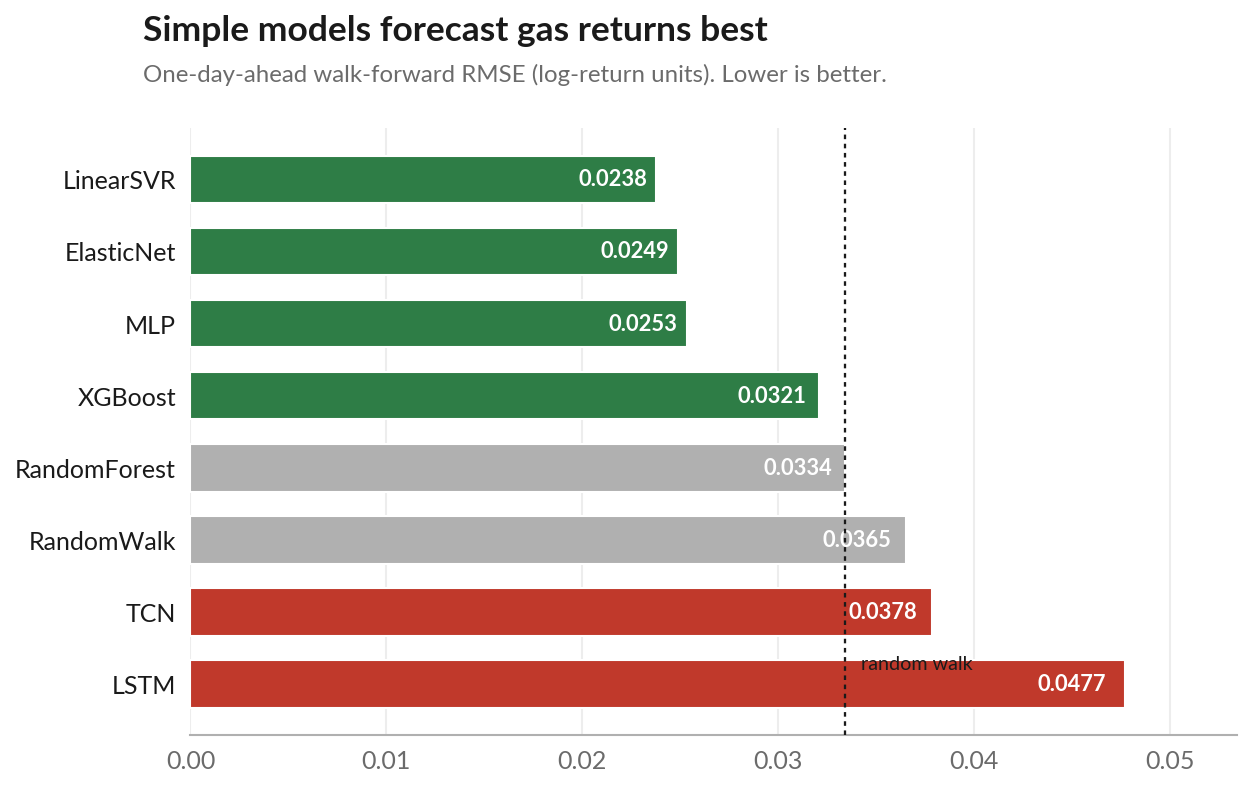

In [ ]:
# ============================================================
# FIG: Model comparison (reads sq1_metrics_full.csv)
# ============================================================
df = pd.read_csv(f"{OUT_DIR}/sq1_metrics_full.csv")[["Model","RMSE"]].copy()
df = df.sort_values("RMSE").reset_index(drop=True)
rw = df.loc[df.Model.str.contains("andom",case=False),"RMSE"].values[0]
def col(m,r): return FAINT if "andom" in m.lower() else (GREEN if r<rw*0.995 else (RED if r>rw*1.005 else AMBER))

fig, ax = plt.subplots(figsize=(9,5.4))
y = np.arange(len(df))[::-1]
ax.barh(y, df.RMSE, height=0.66, color=[col(m,r) for m,r in zip(df.Model,df.RMSE)], zorder=3)
ax.set_yticks(y); ax.set_yticklabels(df.Model)
for yi,(m,r) in zip(y, zip(df.Model,df.RMSE)):
    inside = r > rw*0.5
    ax.text(r-(r*0.02) if inside else r+0.0006, yi, f"{r:.4f}",
            va="center", ha="right" if inside else "left",
            color="white" if inside else INK, fontweight="bold", fontsize=10.5)
ax.axvline(rw, color=INK, ls=(0,(2,2)), lw=1.1, zorder=4)
ax.text(rw+0.0008, 0.2, "random walk", fontsize=9.5, color=INK)
ax.grid(axis="y", visible=False); ax.tick_params(left=False)
ax.set_xlim(0, df.RMSE.max()*1.12)
editorial_titles(fig, ax, "Simple models forecast gas returns best",
                 "One-day-ahead walk-forward RMSE (log-return units). Lower is better.")
save(fig, "fig_model_comparison_ED.png"); plt.show()

saved: fig_connectedness_ED.png


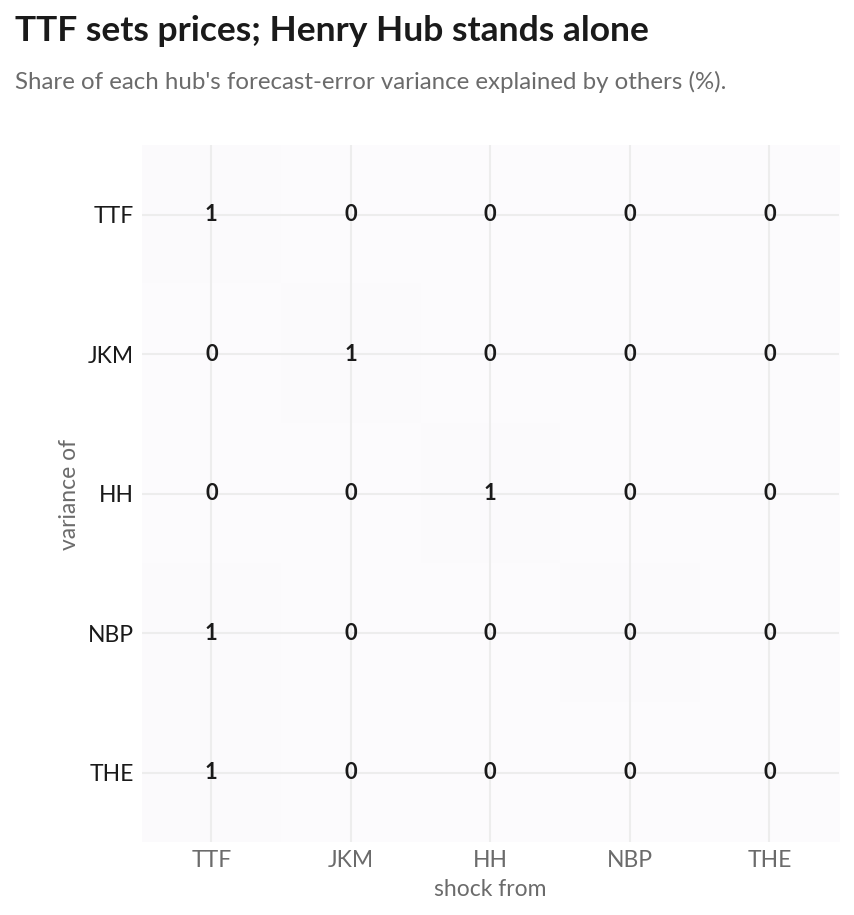

In [ ]:
# ============================================================
# FIG: Connectedness heatmap (reads sq2_connectedness.csv)
# ============================================================
cn = pd.read_csv(f"{OUT_DIR}/sq2_connectedness.csv", index_col=0)
labels = [c.replace("_RET","") for c in cn.columns]
fig, ax = plt.subplots(figsize=(7.5,6.2))
im = ax.imshow(cn.values, cmap="Purples", vmin=0, vmax=100, aspect="equal")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=11)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cn.values[i,j]
        ax.text(j,i, f"{v:.0f}", ha="center", va="center",
                color="white" if v>50 else INK, fontweight="bold", fontsize=10.5)
ax.spines[:].set_visible(False); ax.tick_params(length=0)
ax.set_xlabel("shock from", color=SOFT); ax.set_ylabel("variance of", color=SOFT)
editorial_titles(fig, ax, "TTF sets prices; Henry Hub stands alone",
                 "Share of each hub's forecast-error variance explained by others (%).")
save(fig, "fig_connectedness_ED.png"); plt.show()

In [ ]:
"""
extract_variables.py
=====================
Builds the two data-chapter tables for the dissertation:

  1. variable_definitions  -> Variable | Description | Unit | Source | Transformation | Frequency
  2. descriptive_stats     -> N | Mean | SD | Min | Max | Skew | Excess Kurtosis | ADF p | KPSS p

Descriptive stats are computed TWICE:
  * on LEVELS      -> used for the cointegration / ECM backbone (SQ1)
  * on LOG-RETURNS -> used for the forecasting models (SQ2)

The ADF/KPSS columns double as the stationarity pre-check the ECM section needs,
so the table works as both EDA due-diligence and an econometric prerequisite.

Outputs (written to OUT_DIR):
  - variable_definitions.csv
  - descriptive_stats_levels.csv
  - descriptive_stats_returns.csv
  - variable_tables.xlsx        (all three on separate sheets)
  - descriptive_stats_*.tex     (booktabs, drop straight into LaTeX or paste into Word)

Dependencies:
    pip install pandas numpy scipy statsmodels openpyxl

Author: (you)
"""

from __future__ import annotations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss


# ---------------------------------------------------------------------------
# 1. CONFIG  --  edit this block to match your panel
# ---------------------------------------------------------------------------
DATA_PATH = Path("data/lseg_panel.csv")   # your file: .csv / .xlsx / .parquet
DATE_COL  = "Date"                          # name of the date column (or None)
OUT_DIR   = Path("outputs")

# Which columns go into the tables, in display order.
# Leave as None to auto-use every numeric column (except the date column).
VARIABLES: list[str] | None = None
# e.g. VARIABLES = ["TTF", "JKM", "HH", "NBP", "Brent", "GPR"]

# Metadata that CANNOT be auto-derived from the data. Fill in one entry per
# variable. Any variable you omit still gets a row (with blank meta), so you
# never silently drop a series -- you just see the gap and fill it.
META: dict[str, dict[str, str]] = {
    "TTF":   dict(desc="Dutch TTF day-ahead natural gas price", unit="EUR/MWh",
                  source="LSEG", transform="Log level / log return", freq="Daily"),
    "JKM":   dict(desc="Platts JKM LNG spot price",             unit="USD/MMBtu",
                  source="LSEG", transform="Log level / log return", freq="Daily"),
    "HH":    dict(desc="Henry Hub spot price",                  unit="USD/MMBtu",
                  source="LSEG", transform="Log level / log return", freq="Daily"),
    "NBP":   dict(desc="UK NBP day-ahead natural gas price",    unit="GBp/therm",
                  source="LSEG", transform="Log level / log return", freq="Daily"),
    "Brent": dict(desc="Brent crude oil spot price",            unit="USD/bbl",
                  source="LSEG", transform="Log level / log return", freq="Daily"),
    "GPR":   dict(desc="Geopolitical Risk Index",               unit="Index",
                  source="Caldara & Iacoviello (2022)", transform="Level", freq="Daily"),
    # ... add the remaining hubs / regressors here ...
}

# Rounding for the display / export tables (full precision stays in memory).
ROUND_STATS = 4
ROUND_PVALS = 3


# ---------------------------------------------------------------------------
# 2. IO
# ---------------------------------------------------------------------------
def load_panel(path: Path) -> pd.DataFrame:
    """Read the panel from csv / excel / parquet based on the file extension."""
    suffix = path.suffix.lower()
    if suffix in {".csv", ".txt"}:
        df = pd.read_csv(path)
    elif suffix in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    elif suffix == ".parquet":
        df = pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file type: {suffix!r}")

    if DATE_COL and DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
        df = df.sort_values(DATE_COL).set_index(DATE_COL)
    return df


def select_variables(df: pd.DataFrame) -> list[str]:
    """Pick the columns to describe: explicit list, or all numeric columns."""
    if VARIABLES is not None:
        missing = [c for c in VARIABLES if c not in df.columns]
        if missing:
            raise KeyError(f"Requested columns not in data: {missing}")
        return VARIABLES
    return df.select_dtypes(include=[np.number]).columns.tolist()


# ---------------------------------------------------------------------------
# 3. TRANSFORMS
# ---------------------------------------------------------------------------
def log_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns. Non-positive values are masked before logging so a
    stray zero/negative (e.g. a rare negative price print) doesn't blow up."""
    positive = df.where(df > 0)
    return np.log(positive).diff()


# ---------------------------------------------------------------------------
# 4. STATIONARITY TESTS
# ---------------------------------------------------------------------------
def adf_pvalue(series: pd.Series) -> float:
    """ADF p-value. Null hypothesis = unit root (non-stationary)."""
    s = series.dropna()
    if len(s) < 20 or s.nunique() < 10:
        return np.nan
    try:
        return adfuller(s, autolag="AIC")[1]
    except Exception:
        return np.nan


def kpss_pvalue(series: pd.Series) -> float:
    """KPSS p-value. Null hypothesis = stationary (the complement of ADF).
    statsmodels reports the p-value capped at [0.01, 0.10] and warns when it
    interpolates outside the lookup table -- that warning is expected, so we
    silence it rather than let it clutter the run."""
    s = series.dropna()
    if len(s) < 20:
        return np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            return kpss(s, regression="c", nlags="auto")[1]
        except Exception:
            return np.nan


# ---------------------------------------------------------------------------
# 5. DESCRIPTIVE STATS
# ---------------------------------------------------------------------------
def describe_series(series: pd.Series) -> dict:
    """One row of descriptive statistics for a single series.
    Excess kurtosis uses Fisher's definition (normal = 0), matching how the
    Mouchtaris et al. table reports kurtosis."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "N": int(s.shape[0]),
        "Mean": s.mean(),
        "SD": s.std(),
        "Min": s.min(),
        "Max": s.max(),
        "Skew": stats.skew(s),
        "Excess Kurtosis": stats.kurtosis(s),  # Fisher: normal = 0
        "ADF p": adf_pvalue(s),
        "KPSS p": kpss_pvalue(s),
    }


def descriptive_table(df: pd.DataFrame, variables: list[str]) -> pd.DataFrame:
    """Assemble the descriptive-stats table over the chosen variables."""
    rows = {v: describe_series(df[v]) for v in variables if v in df.columns}
    table = pd.DataFrame(rows).T
    stat_cols = ["Mean", "SD", "Min", "Max", "Skew", "Excess Kurtosis"]
    pval_cols = ["ADF p", "KPSS p"]
    table[stat_cols] = table[stat_cols].round(ROUND_STATS)
    table[pval_cols] = table[pval_cols].round(ROUND_PVALS)
    table["N"] = table["N"].astype("Int64")
    return table


# ---------------------------------------------------------------------------
# 6. DEFINITIONS TABLE
# ---------------------------------------------------------------------------
def definitions_table(variables: list[str]) -> pd.DataFrame:
    """Build the Variable | Description | Unit | Source | Transformation | Frequency
    scaffold. Variables missing from META get a blank row so you can spot and
    fill the gap rather than lose the variable."""
    records = []
    for v in variables:
        m = META.get(v, {})
        records.append({
            "Variable": v,
            "Description": m.get("desc", ""),
            "Unit": m.get("unit", ""),
            "Source": m.get("source", ""),
            "Transformation": m.get("transform", ""),
            "Frequency": m.get("freq", ""),
        })
    return pd.DataFrame.from_records(records)


# ---------------------------------------------------------------------------
# 7. EXPORT
# ---------------------------------------------------------------------------
def export_latex(df: pd.DataFrame, path: Path, caption: str, label: str) -> None:
    """Write a booktabs LaTeX table. Works whether or not the frame has a
    meaningful index (definitions table is reset; stats tables keep the
    variable name as the index)."""
    latex = df.to_latex(
        index=df.index.name is not None or df.index.dtype == object,
        caption=caption,
        label=label,
        escape=True,
        na_rep="--",
        float_format=lambda x: f"{x:,.4f}",
    )
    path.write_text(latex, encoding="utf-8")


def main() -> None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    df = load_panel(DATA_PATH)
    variables = select_variables(df)
    print(f"Loaded {df.shape[0]} rows, describing {len(variables)} variables.")

    defs = definitions_table(variables)
    levels = descriptive_table(df, variables)
    returns = descriptive_table(log_returns(df[variables]), variables)

    # CSV
    defs.to_csv(OUT_DIR / "variable_definitions.csv", index=False)
    levels.to_csv(OUT_DIR / "descriptive_stats_levels.csv")
    returns.to_csv(OUT_DIR / "descriptive_stats_returns.csv")

    # Excel (one workbook, three sheets)
    with pd.ExcelWriter(OUT_DIR / "variable_tables.xlsx", engine="openpyxl") as xl:
        defs.to_excel(xl, sheet_name="Definitions", index=False)
        levels.to_excel(xl, sheet_name="Stats (Levels)")
        returns.to_excel(xl, sheet_name="Stats (Returns)")

    # LaTeX
    export_latex(levels, OUT_DIR / "descriptive_stats_levels.tex",
                 "Descriptive statistics -- levels.", "tab:desc_levels")
    export_latex(returns, OUT_DIR / "descriptive_stats_returns.tex",
                 "Descriptive statistics -- log returns.", "tab:desc_returns")

    print(f"Done. Files written to: {OUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: 'data/lseg_panel.csv'

In [ ]:
# %% Cell A8c: Feature inventory table (families mirror the ablation blocks)
import re
import pandas as pd

FEATURE_SOURCE = Xall            # curated set that feeds the models
# FEATURE_SOURCE = Xall_full     # swap in to document the full 123-feature set

HUB_NAMES = {"ttf":"TTF (Dutch)","jkm":"JKM (Asian LNG)","hh":"Henry Hub (US)",
             "nbp":"NBP (UK)","the":"THE (German)"}
OIL_NAMES = {"brent":"Brent crude","wti":"WTI crude","eua":"EUA carbon"}
CHK_NAMES = {"hormuz":"Strait of Hormuz","suez":"Suez Canal",
             "bab":"Bab-el-Mandeb","cape":"Cape of Good Hope"}
EVT_NAMES = {"ukraine":"Russia–Ukraine war","redsea":"Red Sea / Houthi crisis",
             "iran":"Iran / Hormuz tension"}

def _hub(t): return HUB_NAMES.get(t, t.upper())

def classify(col):
    c = col.lower()
    if c.startswith("spread_"):
        toks = [t for t in c.replace("spread_","").split("_") if t in HUB_NAMES]
        d = "Cross-hub price spread: " + " vs ".join(_hub(t) for t in toks) if toks else "Cross-hub price spread"
        return "Cross-hub spread", d, "Levels (arbitrage)"
    if c.endswith("_slope") or c.endswith("_curvature") or "_prompt_spread" in c:
        hub = next((t for t in HUB_NAMES if c.startswith(t)), None)
        shape = "slope" if c.endswith("_slope") else "curvature" if c.endswith("_curvature") else "prompt spread"
        return "Curve shape", f"Forward-curve {shape}" + (f": {_hub(hub)}" if hub else ""), "Levels"
    if c.endswith("_vol21"):
        hub = next((t for t in HUB_NAMES if c.startswith(t)), None)
        return "Price lag / vol", f"21-day realised volatility{': '+_hub(hub) if hub else ''}", "Return-derived"
    if re.search(r"_lag\d+$", c):
        lag = re.search(r"_lag(\d+)$", c).group(1)
        hub = next((t for t in HUB_NAMES if c.startswith(t)), None)
        oil = next((t for t in OIL_NAMES if c.startswith(t)), None)
        if oil: return "Oil / carbon", f"{OIL_NAMES[oil]} return, {lag}-day lag", "Return-derived"
        return "Price lag / vol", f"Lagged return ({lag}-day){': '+_hub(hub) if hub else ''}", "Return-derived"
    if "storage" in c:
        which = "anomaly vs seasonal norm" if "anom" in c else "change" if "chg" in c else "level"
        return "Storage", f"EU gas storage {which}", "Fundamental"
    if c.startswith("chk_"):
        ck = next((k for k in CHK_NAMES if k in c), None)
        return "Chokepoint", f"Shipping-pressure signal (7d MA): {CHK_NAMES.get(ck, ck)}", "Fundamental"
    if "gpr" in c:
        sub = "acts sub-index" if c.endswith("_act") else "threats sub-index" if c.endswith("_threat") else "headline index"
        return "Geopolitical (GPR)", f"Geopolitical Risk Index ({sub})", "Level"
    if c.startswith("evt_"):
        return "Regime dummy", f"Event regime dummy: {EVT_NAMES.get(c.replace('evt_',''), c.replace('evt_',''))}", "Binary"
    if c == "heating":
        return "Seasonal / weather", "Heating-demand proxy", "Fundamental"
    if c.startswith("doy_"):
        return "Seasonal / weather", f"Day-of-year cyclical ({'sine' if c.endswith('sin') else 'cosine'})", "Engineered"
    return "Other", "(uncategorised — check naming)", ""

rows = []
for col in FEATURE_SOURCE.columns:
    fam, desc, form = classify(col)
    rows.append({"Feature": col, "Family": fam, "Description": desc, "Form": form})

order = ["Cross-hub spread","Curve shape","Price lag / vol","Storage","Chokepoint",
         "Oil / carbon","Geopolitical (GPR)","Regime dummy","Seasonal / weather","Other"]
feat_tbl = pd.DataFrame(rows)
feat_tbl["Family"] = pd.Categorical(feat_tbl["Family"], categories=order, ordered=True)
feat_tbl = feat_tbl.sort_values(["Family","Feature"]).reset_index(drop=True)

print(f"Feature inventory — {len(feat_tbl)} features across "
      f"{feat_tbl['Family'].nunique()} families\n")
print(feat_tbl.to_string(index=False))
print("\n--- count per family ---")
print(feat_tbl.groupby("Family", observed=True).size().to_string())

# flag anything the classifier missed, so a renamed feature never slips through
unc = feat_tbl[feat_tbl["Family"] == "Other"]
if len(unc):
    print("\n⚠ Uncategorised — add a rule or fix the name:", list(unc["Feature"]))

# export for the data chapter
feat_tbl.to_csv(f"{OUT_DIR}/table_feature_inventory.csv", index=False)
with open(f"{OUT_DIR}/table_feature_inventory.tex", "w") as f:
    f.write(feat_tbl.to_latex(index=False, escape=True, longtable=True,
            caption="Feature inventory by family.", label="tab:features"))
print(f"\nSaved to {OUT_DIR}/table_feature_inventory.csv (+ .tex)")

Feature inventory — 42 features across 9 families

       Feature             Family                                               Description               Form
 spread_jkm_hh   Cross-hub spread Cross-hub price spread: JKM (Asian LNG) vs Henry Hub (US) Levels (arbitrage)
spread_jkm_ttf   Cross-hub spread    Cross-hub price spread: JKM (Asian LNG) vs TTF (Dutch) Levels (arbitrage)
 spread_ttf_hh   Cross-hub spread     Cross-hub price spread: TTF (Dutch) vs Henry Hub (US) Levels (arbitrage)
  hh_curvature        Curve shape                   Forward-curve curvature: Henry Hub (US)             Levels
      hh_slope        Curve shape                       Forward-curve slope: Henry Hub (US)             Levels
 jkm_curvature        Curve shape                  Forward-curve curvature: JKM (Asian LNG)             Levels
     jkm_slope        Curve shape                      Forward-curve slope: JKM (Asian LNG)             Levels
 nbp_curvature        Curve shape                         For